# Patent Metrics — Validation & Visualization

Loads every patent output (`patent/output/*.parquet`) plus the metadata, merges on `patent_id`, and
renders **face-validity** checks inline: coverage, metric distributions, temporal trends by grant year,
WIPO-sector breakdowns, windowed-consistency checks (C3≤C5≤C10≤C_all, CD across windows), and
cross-metric correlations. There is no external gold standard for patents, so these plots are sanity
checks that the metrics behave as expected (citation truncation for recent years, F/E/G summing to 1,
examiner/applicant split, etc.).

## Inputs
```
/project/jevans/Dawoon/Science of Science/PatentView/output/patent_metadata.parquet        # patent_id, grant_year, filing_year, ref_count, cpc_code
/project/jevans/Dawoon/Science of Science/PatentView/output/patent_citation.parquet        # C_{3,5,10,all} + examiner/applicant/other per window
/project/jevans/Dawoon/Science of Science/PatentView/output/patent_disruption.parquet      # CD/F/E/G/ni/nj/nk per window
/project/jevans/Dawoon/Science of Science/PatentView/output/patent_z_score.parquet         # Z_median, Z_10pct, Z_min, n_pairs
/project/jevans/Dawoon/Science of Science/PatentView/output/patent_hit_probability.parquet # wipo_sector, grant_year, pctl_{c3,c5,c10,call}
```
All figures are shown inline.

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/validation')
import val_common as V
V.init('patent_validation')
POUT = V.PV_OUT                # notebook/patent/output -> Science of Science/PatentView/output
ROOT = V.BASE
V.preflight()
YR_LO, YR_HI = 1976, 2024      # sane grant-year range for trend plots

# CPC section display names. Defined here rather than in the section that first plotted
# them: section 14a now labels by section too, and it runs earlier.
CPC_NAMES = {'A': 'A: Human necessities', 'B': 'B: Operations / transport', 'C': 'C: Chemistry / metallurgy',
             'D': 'D: Textiles / paper', 'E': 'E: Fixed constructions', 'F': 'F: Mechanical engineering',
             'G': 'G: Physics', 'H': 'H: Electricity', 'Y': 'Y: Emerging / cross-sectional'}


[val] patent_validation  ->  /project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_<section>.{jpg,pdf}  @ 600 dpi
  patent_validation   OK


## 1. Load all patent outputs and merge on `patent_id`

In [2]:
%%time
meta = pd.read_parquet(os.path.join(POUT, 'patent_metadata.parquet'),
                       columns=['patent_id', 'grant_year', 'filing_year', 'ref_count', 'cpc_code'])
cit  = pd.read_parquet(os.path.join(POUT, 'patent_citation.parquet'))
disr = pd.read_parquet(os.path.join(POUT, 'patent_disruption.parquet'))
zsc  = pd.read_parquet(os.path.join(POUT, 'patent_z_score.parquet'))
hit  = pd.read_parquet(os.path.join(POUT, 'patent_hit_probability.parquet'),
                       columns=['patent_id', 'wipo_sector',
                                # the uniqueC family is the default; the four windows are
                                # listed explicitly so a duplicate name cannot creep in --
                                # pyarrow returns a repeated column twice and pandas then
                                # makes df['x'] a DataFrame, which fails a long way from here
                                'pctl_uniqueC_3', 'pctl_uniqueC_5',
                                'pctl_uniqueC_10', 'pctl_uniqueC_all'])
sb   = pd.read_parquet(os.path.join(POUT, 'patent_sb.parquet'), columns=['patent_id', 'SB_B', 'SB_T', 'n_cite'])
print('rows:', {'meta': len(meta), 'cit': len(cit), 'disr': len(disr), 'z': len(zsc), 'hit': len(hit), 'sb': len(sb)})

df = meta.merge(cit, on='patent_id', how='left') \
         .merge(disr, on='patent_id', how='left') \
         .merge(zsc, on='patent_id', how='left') \
         .merge(hit, on='patent_id', how='left') \
         .merge(sb, on='patent_id', how='left')
# fill citation windows with 0 where the citation file had no row (no forward citations)
for c in [x for x in df.columns if x.startswith(('C_', 'appC', 'uniqueC'))]:
    df[c] = df[c].fillna(0)
df['cpc_section'] = df['cpc_code'].astype(str).str[0]   # CPC section = first CPC letter (A-H, Y)
print('merged:', df.shape)
df.head(3)

rows: {'meta': 8531961, 'cit': 7160531, 'disr': 8062166, 'z': 4160856, 'hit': 8512715, 'sb': 6803034}
merged: (8531961, 90)
CPU times: user 51.1 s, sys: 12.8 s, total: 1min 3s
Wall time: 1min 1s


,patent_id,grant_year,filing_year,ref_count,cpc_code,C_3,C_5,C_10,C_all,C_examiner_3,...,n_pairs,wipo_sector,pctl_uniqueC_3,pctl_uniqueC_5,pctl_uniqueC_10,pctl_uniqueC_all,SB_B,SB_T,n_cite,cpc_section
0,10000000,2018,2015.0,2,G01S7/4863,4.0,10.0,19.0,19.0,2.0,...,NaN,Instruments,0.876676,0.895864,0.918463,0.918463,3.714286,5.0,19.0,G
1,10000001,2018,2015.0,6,B29C45/64,0.0,0.0,0.0,0.0,0.0,...,1.0,Mechanical engineering,0.528235,0.521078,0.431212,0.431212,NaN,NaN,NaN,B
2,10000002,2018,2014.0,3,B29C48/21,0.0,0.0,0.0,0.0,0.0,...,6.0,Chemistry,0.000024,0.916883,0.974160,0.974160,NaN,NaN,NaN,B


## 2. Coverage — how many patents have each metric defined

  [fig] patent_validation_2.jpg + .pdf  (600 dpi)


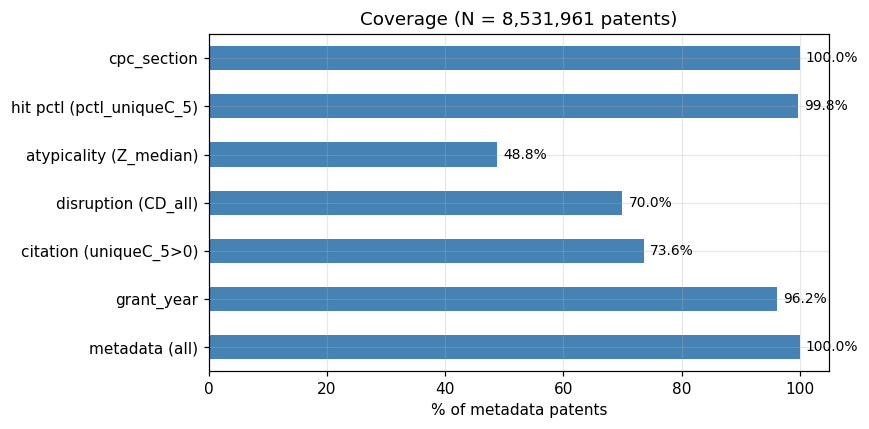

,coverage_%
metadata (all),100.0
grant_year,96.2
citation (uniqueC_5>0),73.6
disruption (CD_all),70.0
atypicality (Z_median),48.8
hit pctl (pctl_uniqueC_5),99.8
cpc_section,100.0


In [3]:
metrics_cov = {
    'metadata (all)': df['patent_id'].notna(),
    'grant_year':     df['grant_year'].between(YR_LO, YR_HI),
    'citation (uniqueC_5>0)': df['uniqueC_5'] > 0,
    'disruption (CD_all)': df['CD_all'].notna(),
    'atypicality (Z_median)': df['Z_median'].notna(),
    'hit pctl (pctl_uniqueC_5)': df['pctl_uniqueC_5'].notna(),
    'cpc_section': df['cpc_section'].notna(),
}
cov = pd.Series({k: v.mean() * 100 for k, v in metrics_cov.items()})
fig, ax = plt.subplots(figsize=(8, 4))
cov.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('% of metadata patents'); ax.set_title(f'Coverage (N = {len(df):,} patents)')
for i, v in enumerate(cov.values): ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, 105); plt.tight_layout(); V.save('2')
display(cov.round(1).to_frame('coverage_%'))

## 3. Grant-year & filing→grant lag

  [fig] patent_validation_3.jpg + .pdf  (600 dpi)


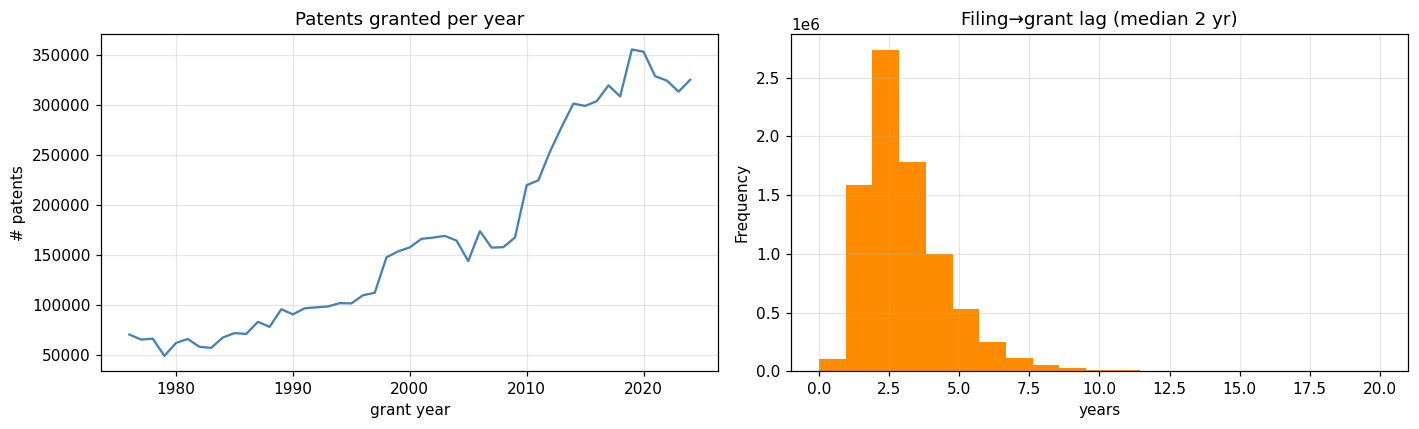

['/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_3.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_3.pdf']

In [4]:
d = df[df['grant_year'].between(YR_LO, YR_HI)]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
d['grant_year'].value_counts().sort_index().plot(ax=ax[0], color='steelblue')
ax[0].set_title('Patents granted per year'); ax[0].set_xlabel('grant year'); ax[0].set_ylabel('# patents')
lag = (d['grant_year'] - d['filing_year'])
lag = lag[(lag >= 0) & (lag <= 20)]
lag.plot.hist(bins=21, ax=ax[1], color='darkorange')
ax[1].set_title(f'Filing→grant lag (median {lag.median():.0f} yr)'); ax[1].set_xlabel('years')
plt.tight_layout(); V.save('3')

## 4. Forward-citation (UNIQUE / de-duplicated) distributions + windowed monotonicity

  [fig] patent_validation_4.jpg + .pdf  (600 dpi)


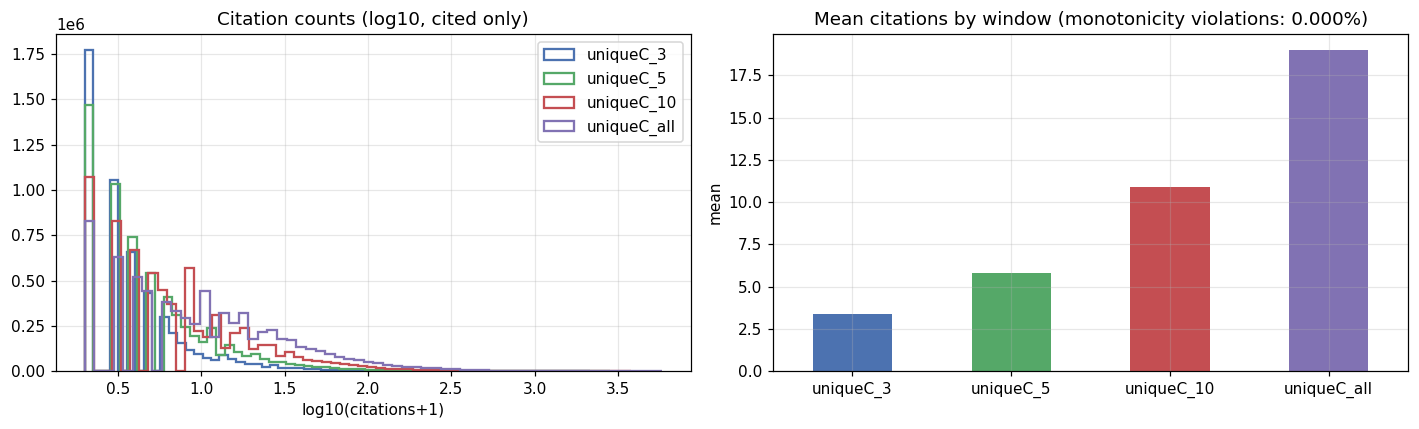

uniqueC_3<=uniqueC_5<=uniqueC_10<=uniqueC_all violations: 0.0000%  (should be 0)


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c, col in zip(['uniqueC_3', 'uniqueC_5', 'uniqueC_10', 'uniqueC_all'], ['#4c72b0', '#55a868', '#c44e52', '#8172b3']):
    v = df[c][df[c] > 0]
    ax[0].hist(np.log10(v + 1), bins=60, histtype='step', label=c, color=col, linewidth=1.5)
ax[0].set_title('Citation counts (log10, cited only)'); ax[0].set_xlabel('log10(citations+1)'); ax[0].legend()
# monotonicity: uniqueC_3<=uniqueC_5<=uniqueC_10<=uniqueC_all should always hold
viol = ((df['uniqueC_3'] > df['uniqueC_5']) | (df['uniqueC_5'] > df['uniqueC_10']) | (df['uniqueC_10'] > df['uniqueC_all'])).mean() * 100
means = df[['uniqueC_3', 'uniqueC_5', 'uniqueC_10', 'uniqueC_all']].mean()
means.plot.bar(ax=ax[1], color=['#4c72b0', '#55a868', '#c44e52', '#8172b3'])
ax[1].set_title(f'Mean citations by window (monotonicity violations: {viol:.3f}%)')
ax[1].set_ylabel('mean'); plt.setp(ax[1].get_xticklabels(), rotation=0)
plt.tight_layout(); V.save('4')
print(f'uniqueC_3<=uniqueC_5<=uniqueC_10<=uniqueC_all violations: {viol:.4f}%  (should be 0)')

## 5. Mean citations by grant year — UNIQUE (de-duplicated) main + examiner/non-examiner split

  [fig] patent_validation_5-1.jpg + .pdf  (600 dpi)


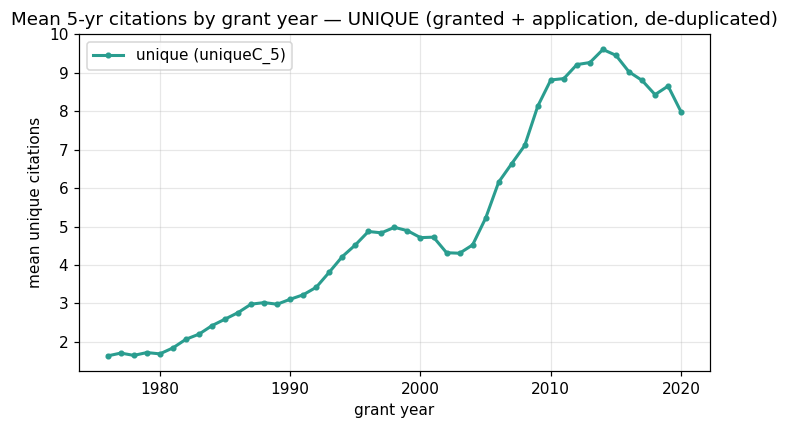

  [fig] patent_validation_5-2.jpg + .pdf  (600 dpi)


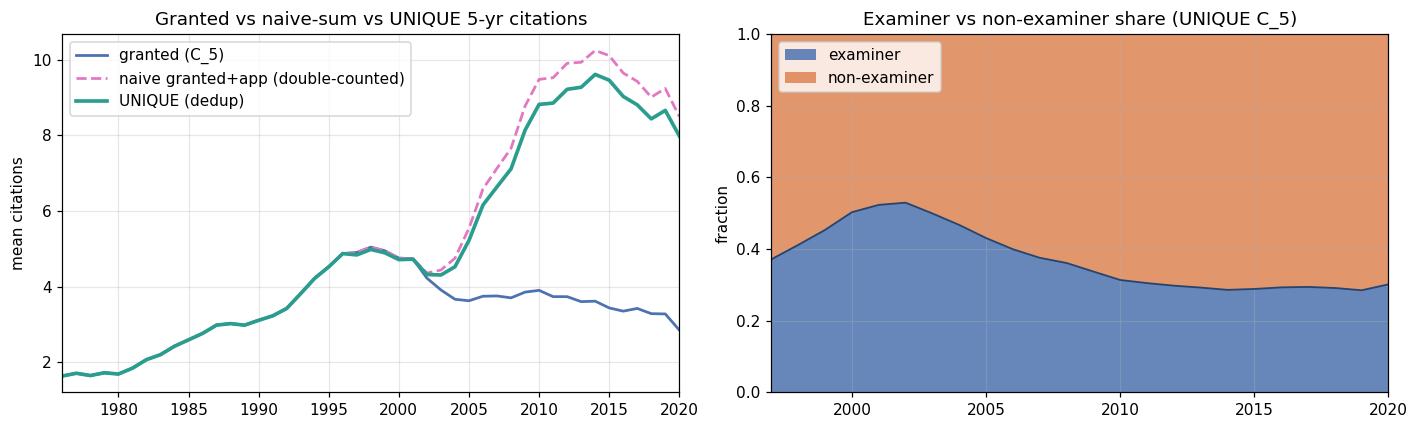

['/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_5-2.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_5-2.pdf']

In [6]:
YR5 = 2020                               # C_5 needs a full 5-yr window -> cap grant year at 2020
d = df[df['grant_year'].between(YR_LO, YR5)]
g = d.groupby('grant_year')
# MAIN: mean UNIQUE (granted + application, de-duplicated) 5-yr citations by grant year
uc5 = g['uniqueC_5'].mean()
figg, axg = plt.subplots(figsize=(6.5, 4))
axg.plot(uc5.index, uc5.values, color='#2a9d8f', lw=2, marker='o', ms=3, label='unique (uniqueC_5)')
axg.set_title('Mean 5-yr citations by grant year — UNIQUE (granted + application, de-duplicated)')
axg.set_xlabel('grant year'); axg.set_ylabel('mean unique citations'); axg.legend(loc='upper left')
plt.tight_layout(); V.save('5-1')
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# dedup effect: granted vs naive granted+application (double-counted) vs unique
gr = g['C_5'].mean(); apc = g['appC_5'].mean(); naive = gr + apc
ax[0].plot(gr.index, gr.values, color='#4c72b0', lw=1.8, label='granted (C_5)')
ax[0].plot(naive.index, naive.values, color='#e377c2', lw=1.8, ls='--', label='naive granted+app (double-counted)')
ax[0].plot(uc5.index, uc5.values, color='#2a9d8f', lw=2.4, label='UNIQUE (dedup)')
ax[0].set_title('Granted vs naive-sum vs UNIQUE 5-yr citations'); ax[0].set_ylabel('mean citations')
ax[0].legend(loc='upper left'); ax[0].set_xlim(YR_LO, YR5)
# examiner vs non-examiner share of UNIQUE citations; drop years with no data
exm = g['uniqueC_examiner_5'].sum(); nex = g['uniqueC_non_examiner_5'].sum()
tot = exm + nex; keep = tot > 0
fe = (exm[keep] / tot[keep]); fn = (nex[keep] / tot[keep])
ax[1].stackplot(fe.index, fe.values, fn.values, labels=['examiner', 'non-examiner'],
                colors=['#4c72b0', '#dd8452'], alpha=0.85)
ax[1].plot(fe.index, fe.values, color='#26456e', lw=1.2)
ax[1].set_title('Examiner vs non-examiner share (UNIQUE C_5)')
ax[1].set_ylabel('fraction'); ax[1].set_ylim(0, 1); ax[1].set_xlim(fe.index.min(), fe.index.max()); ax[1].legend(loc='upper left')
plt.tight_layout(); V.save('5-2')

## 5b. Application citations (pre-grant) by grant year + examiner/non-examiner + granted-vs-application

  [fig] patent_validation_5b.jpg + .pdf  (600 dpi)


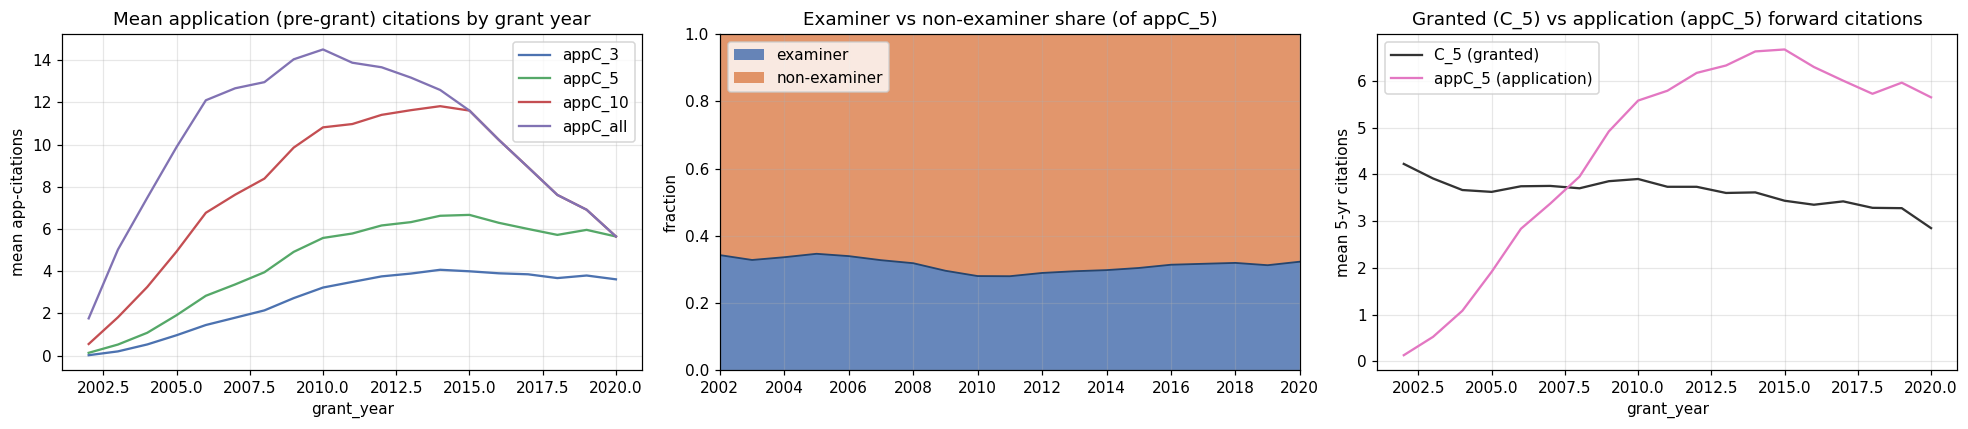

coverage: patents with appC_all>0 = 3828179 / 8531961 (44.9%)
Spearman C_5 vs appC_5 (grant 2002..YR_HI-5): 0.249
  appC_3: mean 2.012  exm/non-exm 0.660/1.352
  appC_5: mean 3.088  exm/non-exm 0.966/2.122
  appC_10: mean 4.868  exm/non-exm 1.389/3.480
  appC_all: mean 5.807  exm/non-exm 1.579/4.227


In [7]:
# Application (pre-grant) forward citations: appC_{3,5,10,all}, from g_us_application_citation
# mapped pgpub->patent via pg_granted_pgpubs_crosswalk. Pre-grant publications begin ~2001,
# so app-citations are ~0 before then; restrict the trend to grant years >= 2002.
d = df[df['grant_year'].between(2002, 2020)]      # pgpub era .. C_5 full-window cap
g = d.groupby('grant_year')
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for c, col in zip(['appC_3', 'appC_5', 'appC_10', 'appC_all'], ['#4c72b0', '#55a868', '#c44e52', '#8172b3']):
    g[c].mean().plot(ax=ax[0], label=c, color=col)
ax[0].set_title('Mean application (pre-grant) citations by grant year'); ax[0].set_ylabel('mean app-citations'); ax[0].legend()
exm = g['appC_examiner_5'].sum(); nex = g['appC_non_examiner_5'].sum()
tot = exm + nex; keep = tot > 0
fe = (exm[keep] / tot[keep]); fn = (nex[keep] / tot[keep])
ax[1].stackplot(fe.index, fe.values, fn.values, labels=['examiner', 'non-examiner'],
                colors=['#4c72b0', '#dd8452'], alpha=0.85)
ax[1].plot(fe.index, fe.values, color='#26456e', lw=1.2)
ax[1].set_title('Examiner vs non-examiner share (of appC_5)'); ax[1].set_ylabel('fraction')
ax[1].set_ylim(0, 1); ax[1].set_xlim(fe.index.min(), fe.index.max()); ax[1].legend(loc='upper left')
g[['C_5', 'appC_5']].mean().plot(ax=ax[2], color=['#333333', '#e377c2'])
ax[2].set_title('Granted (C_5) vs application (appC_5) forward citations'); ax[2].set_ylabel('mean 5-yr citations')
ax[2].legend(['C_5 (granted)', 'appC_5 (application)'])
plt.tight_layout(); V.save('5b')
sub = df[df['grant_year'].between(2002, YR_HI - 5)]
print('coverage: patents with appC_all>0 =', int((df['appC_all'] > 0).sum()), '/', len(df),
      f"({100*(df['appC_all']>0).mean():.1f}%)")
print('Spearman C_5 vs appC_5 (grant 2002..YR_HI-5):',
      round(sub[['C_5', 'appC_5']].corr(method='spearman').iloc[0, 1], 3))
for s in ['_3', '_5', '_10', '_all']:
    print(f'  appC{s}: mean {df[f"appC{s}"].mean():.3f}  '
          f'exm/non-exm {df[f"appC_examiner{s}"].mean():.3f}/{df[f"appC_non_examiner{s}"].mean():.3f}')

## 6. Disruption (CD) — distribution, trend, ni/nj/nk composition

  [fig] patent_validation_6.jpg + .pdf  (600 dpi)


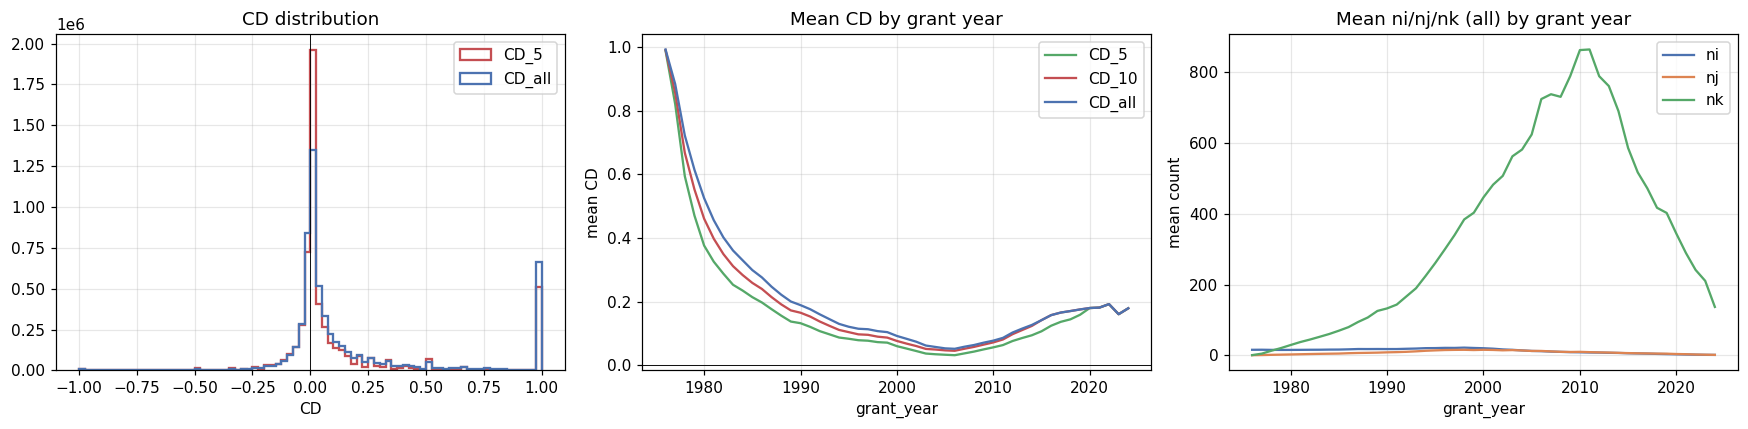

CD_all summary:
count    5.973424e+06
mean     1.690000e-01
std      3.344000e-01
min     -1.000000e+00
25%     -2.100000e-03
50%      2.500000e-02
75%      1.724000e-01
max      1.000000e+00


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c, col in zip(['CD_5', 'CD_all'], ['#c44e52', '#4c72b0']):
    ax[0].hist(df[c].dropna(), bins=80, histtype='step', label=c, color=col, linewidth=1.5)
ax[0].set_title('CD distribution'); ax[0].set_xlabel('CD'); ax[0].legend(); ax[0].axvline(0, color='k', lw=0.6)
d = df[df['grant_year'].between(YR_LO, YR_HI)]
g = d.groupby('grant_year')
for c, col in zip(['CD_5', 'CD_10', 'CD_all'], ['#55a868', '#c44e52', '#4c72b0']):
    g[c].mean().plot(ax=ax[1], label=c, color=col)
ax[1].set_title('Mean CD by grant year'); ax[1].set_ylabel('mean CD'); ax[1].axhline(0, color='k', lw=0.6); ax[1].legend()
comp = g[['ni_all', 'nj_all', 'nk_all']].mean()
comp.plot(ax=ax[2], color=['#4c72b0', '#dd8452', '#55a868'])
ax[2].set_title('Mean ni/nj/nk (all) by grant year'); ax[2].set_ylabel('mean count'); ax[2].legend(['ni', 'nj', 'nk'])
plt.tight_layout(); V.save('6')
print('CD_all summary:'); print(df['CD_all'].describe().round(4).to_string())

## 7. F/E/G (Foundation / Extension / Generalization) — 5-year window

  [fig] patent_validation_7.jpg + .pdf  (600 dpi)


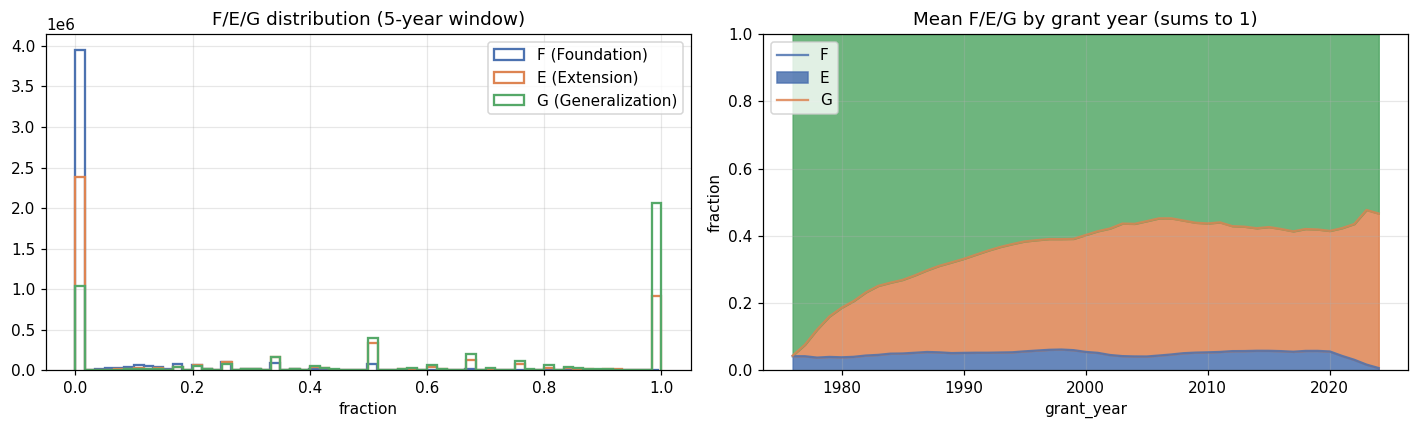

mean F/E/G (5y): {'F_5': 0.050999999046325684, 'E_5': 0.3409999907016754, 'G_5': 0.6069999933242798} | sum = 1.0


In [9]:
# F/E/G on the 5-YEAR window. An all-time window never closes -- it only gets shorter the
# nearer a document sits to the snapshot -- so it is the worst of the four for comparing
# across time, not the best. Five years closes, and by then most documents that will ever
# cite have done so. CD and ni/nj/nk are left on their own window on purpose: they are the
# disruption block, not the F/E/G block.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c, lab, col in [('F_5', 'F (Foundation)', '#4c72b0'), ('E_5', 'E (Extension)', '#dd8452'),
                    ('G_5', 'G (Generalization)', '#55a868')]:
    ax[0].hist(df[c].dropna(), bins=60, histtype='step', label=lab, color=col, linewidth=1.5)
ax[0].set_title('F/E/G distribution (5-year window)'); ax[0].set_xlabel('fraction'); ax[0].legend()
d = df[df['grant_year'].between(YR_LO, YR_HI)]
feg = d.groupby('grant_year')[['F_5', 'E_5', 'G_5']].mean()
feg.plot.area(ax=ax[1], color=['#4c72b0', '#dd8452', '#55a868'], alpha=0.85)
ax[1].set_title('Mean F/E/G by grant year (sums to 1)'); ax[1].set_ylabel('fraction'); ax[1].set_ylim(0, 1)
ax[1].legend(['F', 'E', 'G'], loc='upper left'); plt.tight_layout(); V.save('7')
print('mean F/E/G (5y):', df[['F_5', 'E_5', 'G_5']].mean().round(3).to_dict(),
      '| sum =', round(df[['F_5', 'E_5', 'G_5']].mean().sum(), 3))

## 8. Atypicality (z-scores)

  [fig] patent_validation_8.jpg + .pdf  (600 dpi)


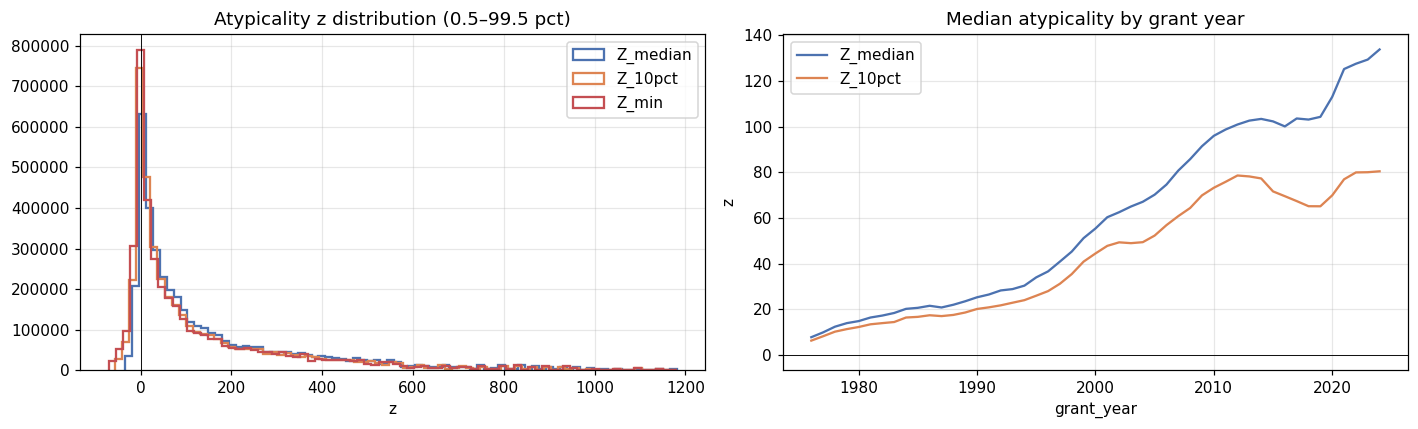

['/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_8.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_8.pdf']

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c, col in zip(['Z_median', 'Z_10pct', 'Z_min'], ['#4c72b0', '#dd8452', '#c44e52']):
    v = df[c].replace([np.inf, -np.inf], np.nan).dropna()
    v = v[(v > v.quantile(0.005)) & (v < v.quantile(0.995))]
    ax[0].hist(v, bins=80, histtype='step', label=c, color=col, linewidth=1.5)
ax[0].set_title('Atypicality z distribution (0.5–99.5 pct)'); ax[0].set_xlabel('z'); ax[0].legend()
ax[0].axvline(0, color='k', lw=0.6)
d = df[df['grant_year'].between(YR_LO, YR_HI)]
d.groupby('grant_year')[['Z_median', 'Z_10pct']].median().plot(ax=ax[1], color=['#4c72b0', '#dd8452'])
ax[1].set_title('Median atypicality by grant year'); ax[1].set_ylabel('z'); ax[1].axhline(0, color='k', lw=0.6)
plt.tight_layout(); V.save('8')

## 9. Hit percentile distribution

  [fig] patent_validation_9.jpg + .pdf  (600 dpi)


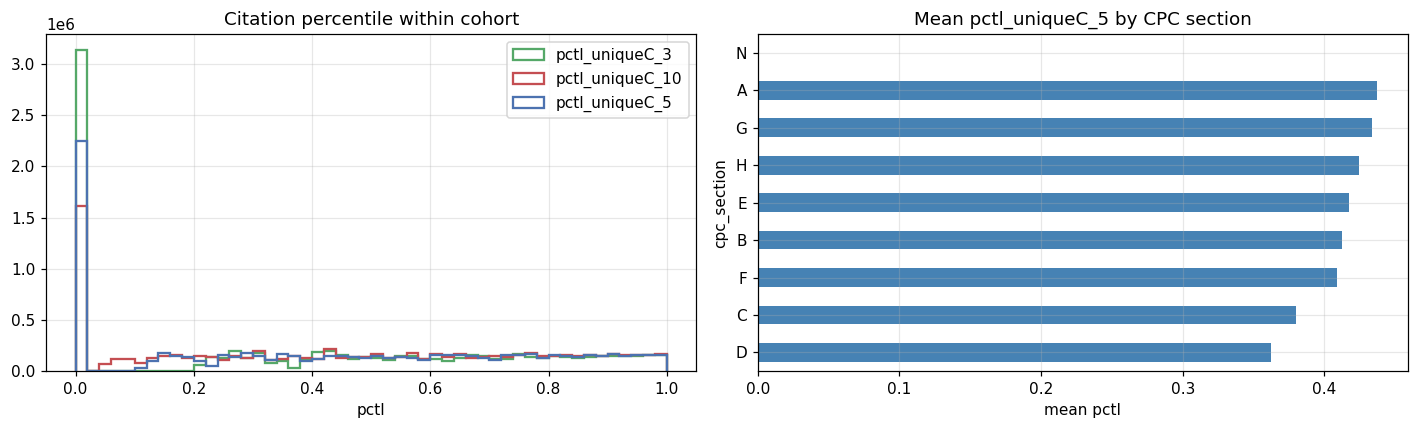

['/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_9.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_9.pdf']

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c, col in zip(['pctl_uniqueC_3', 'pctl_uniqueC_10', 'pctl_uniqueC_5'], ['#55a868', '#c44e52', '#4c72b0']):
    ax[0].hist(df[c].dropna(), bins=50, histtype='step', label=c, color=col, linewidth=1.5)
ax[0].set_title('Citation percentile within cohort'); ax[0].set_xlabel('pctl'); ax[0].legend()
# mean pctl by sector
sec = df.dropna(subset=['cpc_section']).groupby('cpc_section')['pctl_uniqueC_5'].mean().sort_values()
sec.plot.barh(ax=ax[1], color='steelblue'); ax[1].set_title('Mean pctl_uniqueC_5 by CPC section'); ax[1].set_xlabel('mean pctl')
plt.tight_layout(); V.save('9')

## 10. By CPC section — metric means

  [fig] patent_validation_10.jpg + .pdf  (600 dpi)


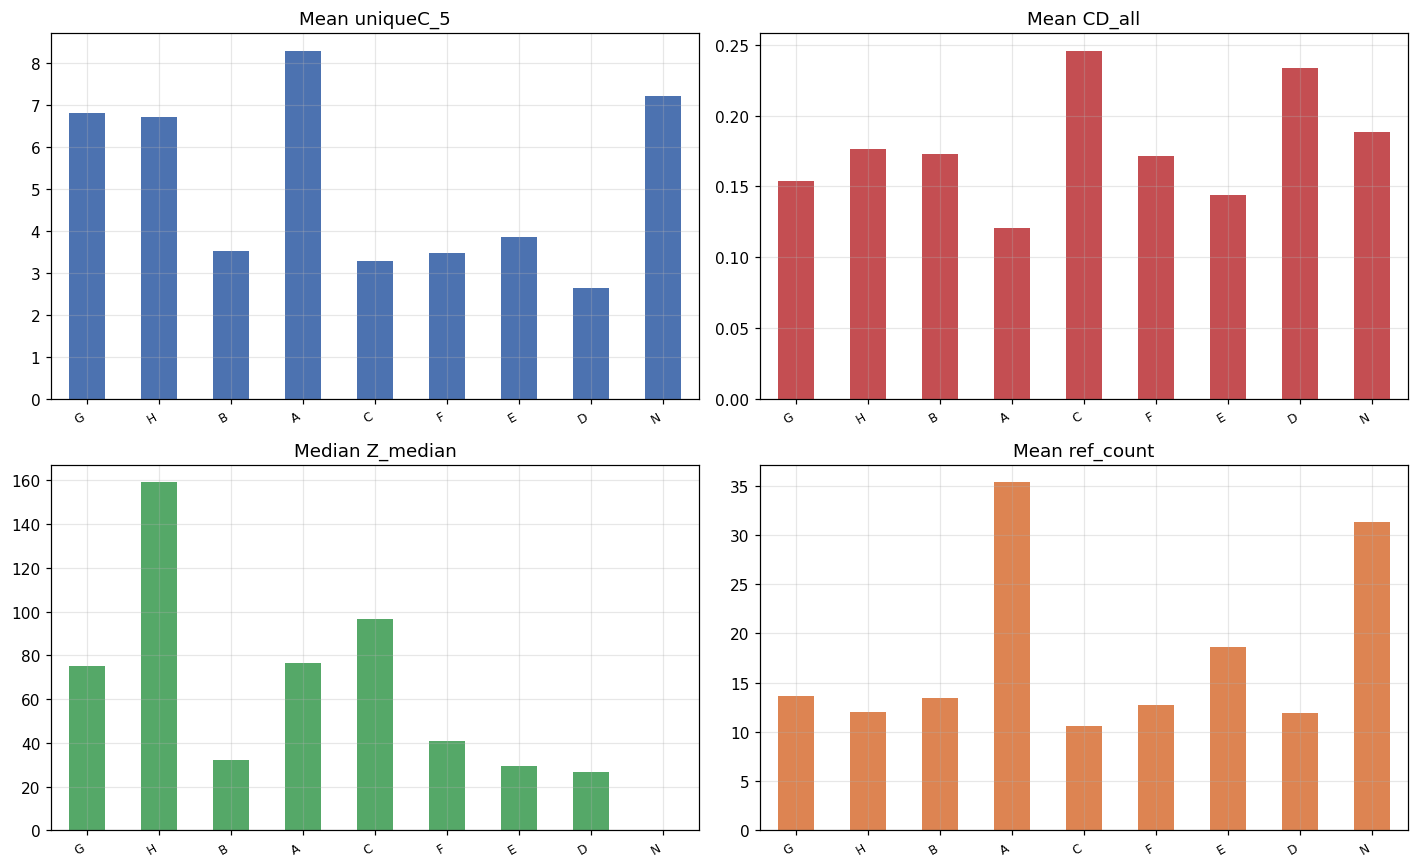

,n,ref_count,uniqueC_5,CD_all,Z_median
cpc_section,,,,,
G,2270328,13.63,6.82,0.15,75.01
H,2124027,12.03,6.71,0.18,159.05
B,1202253,13.40,3.52,0.17,32.35
A,1109395,35.32,8.31,0.12,76.63
C,882753,10.61,3.29,0.25,96.58
F,621659,12.75,3.46,0.17,40.68
E,225421,18.61,3.85,0.14,29.34
D,76893,11.93,2.63,0.23,26.42
N,19232,31.26,7.21,0.19,NaN


In [12]:
d = df.dropna(subset=['cpc_section'])
agg = d.groupby('cpc_section').agg(
    n=('patent_id', 'size'), ref_count=('ref_count', 'mean'), uniqueC_5=('uniqueC_5', 'mean'),
    CD_all=('CD_all', 'mean'), Z_median=('Z_median', 'median')).sort_values('n', ascending=False)
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
agg['uniqueC_5'].plot.bar(ax=ax[0, 0], color='#4c72b0');  ax[0, 0].set_title('Mean uniqueC_5'); ax[0, 0].set_xlabel('')
agg['CD_all'].plot.bar(ax=ax[0, 1], color='#c44e52'); ax[0, 1].set_title('Mean CD_all'); ax[0, 1].axhline(0, color='k', lw=0.6); ax[0, 1].set_xlabel('')
agg['Z_median'].plot.bar(ax=ax[1, 0], color='#55a868'); ax[1, 0].set_title('Median Z_median'); ax[1, 0].axhline(0, color='k', lw=0.6); ax[1, 0].set_xlabel('')
agg['ref_count'].plot.bar(ax=ax[1, 1], color='#dd8452'); ax[1, 1].set_title('Mean ref_count'); ax[1, 1].set_xlabel('')
for a in ax.flat: plt.setp(a.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout(); V.save('10')
display(agg.round(2))

## 11. Cross-metric correlations

  [fig] patent_validation_11.jpg + .pdf  (600 dpi)


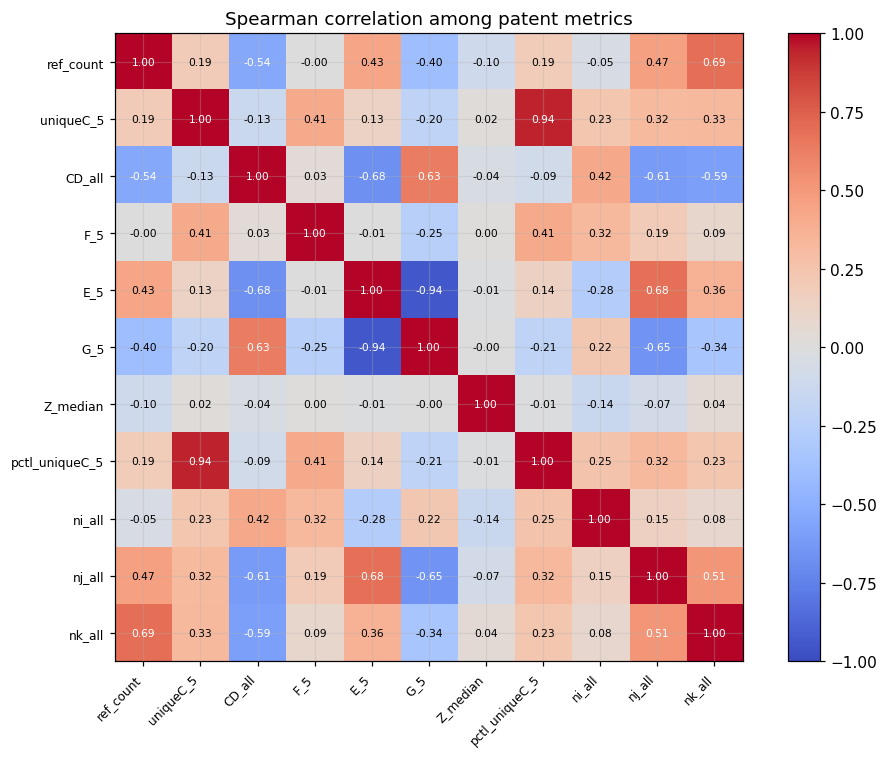

['/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_11.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_11.pdf']

In [13]:
# F/E/G on the 5-YEAR window. An all-time window never closes -- it only gets shorter the
# nearer a document sits to the snapshot -- so it is the worst of the four for comparing
# across time, not the best. Five years closes, and by then most documents that will ever
# cite have done so. CD and ni/nj/nk are left on their own window on purpose: they are the
# disruption block, not the F/E/G block.
keys = ['ref_count', 'uniqueC_5', 'CD_all', 'F_5', 'E_5', 'G_5', 'Z_median', 'pctl_uniqueC_5', 'ni_all', 'nj_all', 'nk_all']
corr = df[keys].replace([np.inf, -np.inf], np.nan).corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(keys))); ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys, fontsize=8)
for i in range(len(keys)):
    for j in range(len(keys)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
ax.set_title('Spearman correlation among patent metrics'); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); V.save('11')

## 12. Scatter checks (50k sample)

  [fig] patent_validation_12.jpg + .pdf  (600 dpi)


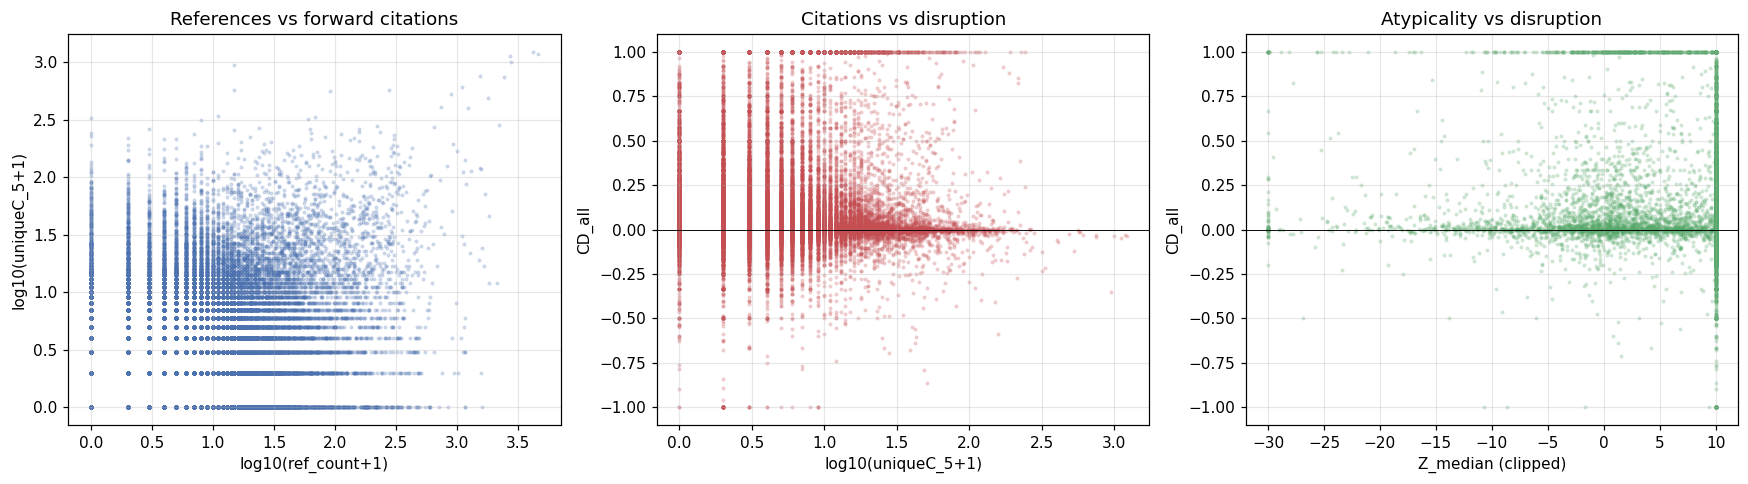

['/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_12.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_12.pdf']

In [14]:
s = df.sample(min(50000, len(df)), random_state=0)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].scatter(np.log10(s['ref_count'] + 1), np.log10(s['uniqueC_5'] + 1), s=3, alpha=0.2, color='#4c72b0')
ax[0].set_xlabel('log10(ref_count+1)'); ax[0].set_ylabel('log10(uniqueC_5+1)'); ax[0].set_title('References vs forward citations')
ax[1].scatter(np.log10(s['uniqueC_5'] + 1), s['CD_all'], s=3, alpha=0.2, color='#c44e52')
ax[1].set_xlabel('log10(uniqueC_5+1)'); ax[1].set_ylabel('CD_all'); ax[1].set_title('Citations vs disruption'); ax[1].axhline(0, color='k', lw=0.6)
ax[2].scatter(s['Z_median'].clip(-30, 10), s['CD_all'], s=3, alpha=0.2, color='#55a868')
ax[2].set_xlabel('Z_median (clipped)'); ax[2].set_ylabel('CD_all'); ax[2].set_title('Atypicality vs disruption'); ax[2].axhline(0, color='k', lw=0.6)
plt.tight_layout(); V.save('12')

## 13. Sleeping Beauty (SB_B / SB_T, B vs impact, by sector)

  [fig] patent_validation_13.jpg + .pdf  (600 dpi)


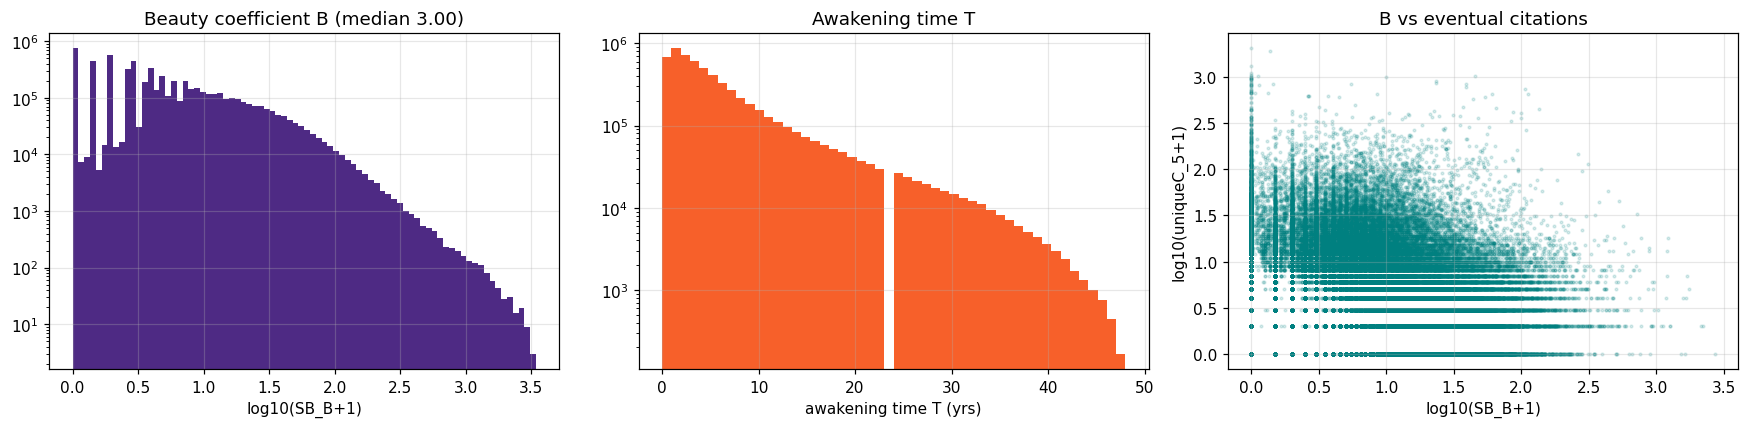

Top sleeping-beauty patents:


,patent_id,grant_year,cpc_section,SB_B,SB_T,n_cite
2712022,4149461,1979,B,3426.562256,42.0,436.0
2535506,3972734,1976,H,3255.237305,42.0,1011.0
2596839,4034143,1977,H,3169.818604,41.0,1009.0
2506960,3944163,1976,B,3076.471191,42.0,1025.0
2813231,4250817,1981,F,3058.821533,41.0,349.0
2855956,4293604,1981,D,3009.550049,38.0,825.0
2716673,4154122,1979,B,2994.076416,39.0,1017.0
2844938,4282573,1981,F,2964.324463,38.0,701.0
2590448,4027746,1977,B,2946.662842,41.0,1027.0
2723401,4160857,1979,H,2938.524170,41.0,601.0


done — all validation figures rendered inline.


In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
b = df['SB_B'].dropna()
ax[0].hist(np.log10(b.clip(lower=0) + 1), bins=80, color='#4E2A84'); ax[0].set_yscale('log')
ax[0].set_xlabel('log10(SB_B+1)'); ax[0].set_title(f'Beauty coefficient B (median {b.median():.2f})')
t = df['SB_T'].dropna().clip(0, 50)
ax[1].hist(t, bins=50, color='#F7602A'); ax[1].set_yscale('log')
ax[1].set_xlabel('awakening time T (yrs)'); ax[1].set_title('Awakening time T')
s = df.dropna(subset=['SB_B', 'uniqueC_5']).sample(min(150000, df['SB_B'].notna().sum()), random_state=0)
ax[2].scatter(np.log10(s['SB_B'].clip(lower=0) + 1), np.log10(s['uniqueC_5'] + 1), s=3, alpha=0.15, color='teal')
ax[2].set_xlabel('log10(SB_B+1)'); ax[2].set_ylabel('log10(uniqueC_5+1)'); ax[2].set_title('B vs eventual citations')
plt.tight_layout(); V.save('13')
top = df.dropna(subset=['SB_B']).nlargest(10, 'SB_B')[['patent_id', 'grant_year', 'cpc_section', 'SB_B', 'SB_T', 'n_cite']]
print('Top sleeping-beauty patents:'); display(top)
print('done — all validation figures rendered inline.')

## 14. Cumulative citation trajectory — convexity for HIT top-1% patents (CPC section)

Restricted to **hit top-1% patents** (top 1% by 5-yr **UNIQUE** citations `uniqueC_5` within CPC-section x grant-year),
using **all** such patents (no sampling). Per-patent **cumulative** patent→patent curves are min–max scaled;
convexity is **convexity index = 1 − mean(normalised citation age)** (`<0.5` convex = late burst; `>0.5` concave).
Computed out-of-core with DuckDB. Field breakdown = **CPC section** (first CPC letter).

In [16]:
%%time
import duckdb
BLUE = '#1f77b4'; NB = 20; GX = np.arange(NB + 1) / NB
TREND = os.path.join(POUT, 'patent_citation_trend.parquet').replace(os.sep, '/')
con = duckdb.connect(); con.execute("SET memory_limit='14GB'")
con.execute(f"SET temp_directory='{V.TMP}'")
df['pctl_uc5'] = df.groupby(['cpc_section', 'grant_year'])['uniqueC_5'].rank(pct=True)  # unique-citation hit percentile
con.register('hit1', df.loc[df['pctl_uc5'] >= 0.99, ['patent_id']].dropna())
AGG = (f"SELECT patent_id, sum(pat2pat_examiner+pat2pat_non_examiner) tot, max(yrs_since_grant) span "
       f"FROM read_parquet('{TREND}') WHERE patent_id IN (SELECT patent_id FROM hit1) "
       "GROUP BY patent_id HAVING sum(pat2pat_examiner+pat2pat_non_examiner)>=10 AND max(yrs_since_grant)>=5")
per = con.execute(f'''WITH agg AS ({AGG})
  SELECT t.patent_id, a.tot, a.span,
         1 - sum((t.pat2pat_examiner+t.pat2pat_non_examiner)*(t.yrs_since_grant::double/a.span))/a.tot AS cvx
  FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id) GROUP BY t.patent_id, a.tot, a.span''').fetchdf()
per = per.merge(df[['patent_id', 'cpc_section', 'SB_B']], on='patent_id', how='left')
per['shape'] = np.where(per['cvx'] < 0.5, 'convex', 'concave')
Npat = len(per); print(f'HIT top-1% patents with trajectory (no sample): {Npat:,}')

def mean_traj(id_series=None):
    where = ''
    if id_series is not None:
        con.register('flt', pd.DataFrame({'patent_id': id_series.values}))
        where = 'JOIN flt USING (patent_id)'
    q = f'''WITH agg AS ({AGG}), j AS (
      SELECT (t.yrs_since_grant::double/a.span) nt, (t.pat2pat_examiner+t.pat2pat_non_examiner) v, a.tot, t.patent_id
      FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id) {where})
    SELECT least(floor(nt*{NB}), {NB}) b, sum(v::double/tot) w FROM j GROUP BY b ORDER BY b'''
    h = con.execute(q).fetchdf()
    N = len(id_series) if id_series is not None else Npat
    wv = np.zeros(NB + 1); wv[h['b'].astype(int).values] = h['w'].values
    return np.cumsum(wv) / N

def cvx_area(m): return np.trapz(m, GX)
overall = mean_traj()
hi_ids = per.loc[per['SB_B'] >= per['SB_B'].quantile(0.90), 'patent_id']
hitraj = mean_traj(hi_ids)
print(f'overall trajectory convexity index {cvx_area(overall):.3f} | per-item mean convexity index {per.cvx.mean():.3f} | {(per.cvx<0.5).mean()*100:.1f}% convex')

# ---- section 14a works on the top 1% by SLEEPING BEAUTY, not by citations ---------------
# `per` above is the citation hit top-1% and stays as it is, because section 14b reports on
# it. This is a second, disjoint selection: the patents whose citation history is most
# delayed, which is what a trajectory figure is actually about.
SB_Q = 0.99
sb_all = df[['patent_id', 'SB_B', 'cpc_section']].dropna(subset=['SB_B'])
SB_CUT = sb_all['SB_B'].quantile(SB_Q)
sb1 = sb_all[sb_all['SB_B'] >= SB_CUT]
con.register('sb1v', sb1[['patent_id']])

AGG_SB = (f"SELECT patent_id, sum(pat2pat_examiner+pat2pat_non_examiner) tot, "
          f"max(yrs_since_grant) span FROM read_parquet('{TREND}') "
          "WHERE patent_id IN (SELECT patent_id FROM sb1v) GROUP BY patent_id "
          "HAVING sum(pat2pat_examiner+pat2pat_non_examiner)>=10 AND max(yrs_since_grant)>=5")
per_sb = con.execute(f'''WITH agg AS ({AGG_SB})
  SELECT t.patent_id, a.tot, a.span,
         1 - sum((t.pat2pat_examiner+t.pat2pat_non_examiner)
                 *(t.yrs_since_grant::double/a.span))/a.tot AS cvx
  FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id)
  GROUP BY t.patent_id, a.tot, a.span''').fetchdf()
per_sb = per_sb.merge(sb1, on='patent_id', how='left')
Nsb = len(per_sb)


def mean_traj_sb(id_series=None):
    where = ''
    if id_series is not None:
        con.register('fltsb', pd.DataFrame({'patent_id': id_series.values}))
        where = 'JOIN fltsb USING (patent_id)'
    q = f'''WITH agg AS ({AGG_SB}), j AS (
      SELECT (t.yrs_since_grant::double/a.span) nt,
             (t.pat2pat_examiner+t.pat2pat_non_examiner) v, a.tot, t.patent_id
      FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id) {where})
    SELECT least(floor(nt*{NB}), {NB}) b, sum(v::double/tot) w FROM j GROUP BY b ORDER BY b'''
    h = con.execute(q).fetchdf()
    N = len(id_series) if id_series is not None else Nsb
    wv = np.zeros(NB + 1); wv[h['b'].astype(int).values] = h['w'].values
    return np.cumsum(wv) / N


def t_half(m):
    """Normalised time by which half the citations have arrived.

    Reported instead of the number this panel used to report. That per-item quantity is
    1 - (citation-weighted mean normalised time): not an area under anything, and the label
    invited reading it as a classifier score. It survives as `cvx`, the convexity index, and
    t-half says the same thing directly -- above 0.5 the citations arrive late, which is what
    a convex cumulative curve looks like, and it can be read straight off the y = 0.5 line."""
    return float(np.interp(0.5, m, GX))


overall_sb = mean_traj_sb()
print(f'top {(1-SB_Q)*100:.0f}% by SB_B: cut B >= {SB_CUT:.2f}, '
      f'{len(sb1):,} patents, {Nsb:,} with a usable trajectory')
print(f'  t-half {t_half(overall_sb):.3f}   '
      f'{(per_sb.cvx < 0.5).mean()*100:.1f}% convex (per-item index < 0.5)')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

HIT top-1% patents with trajectory (no sample): 61,294
overall trajectory convexity index 0.570 | per-item mean convexity index 0.526 | 41.6% convex
top 1% by SB_B: cut B >= 101.11, 60,089 patents, 59,380 with a usable trajectory
  t-half 0.747   98.2% convex (per-item index < 0.5)
CPU times: user 22.8 s, sys: 916 ms, total: 23.7 s
Wall time: 19.5 s


### 14a. Overall trajectory + convexity index distribution + high-SB (within hit top-1%)

  [fig] patent_validation_14a.jpg + .pdf  (600 dpi)


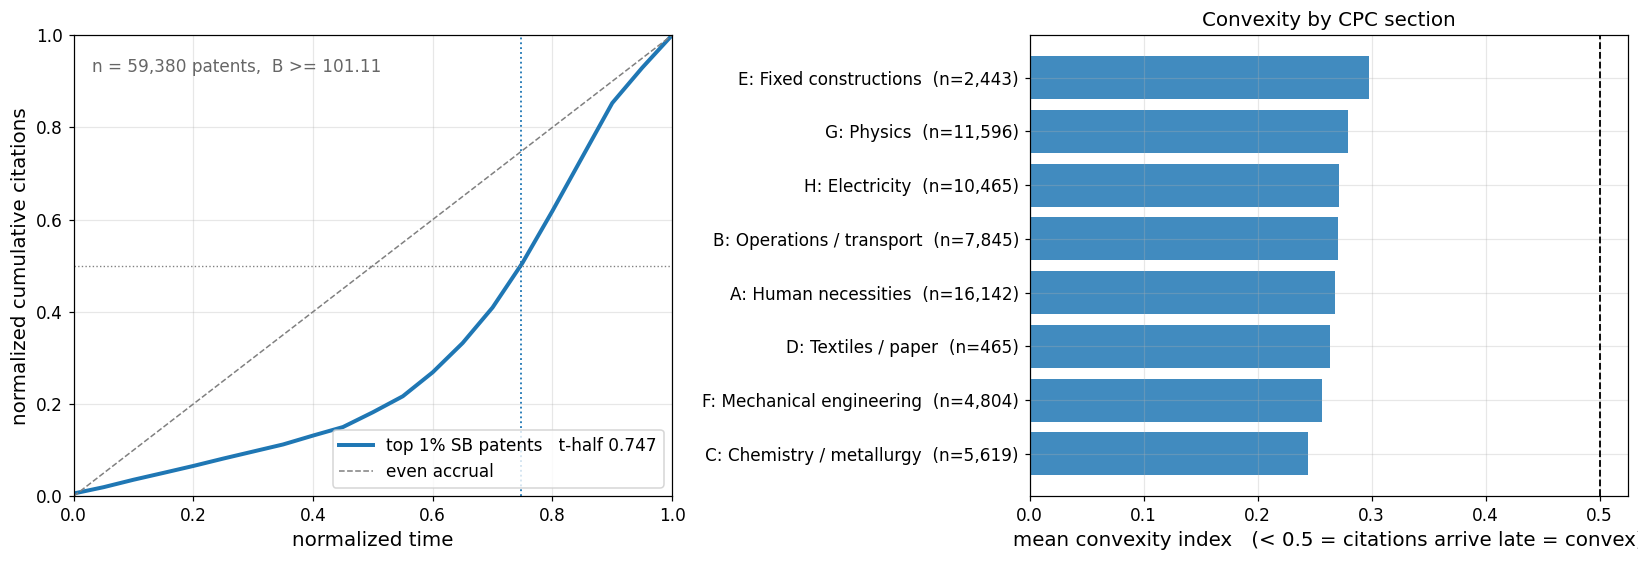


top 1% SB patents: convexity index by CPC section (n >= 30)
             mean_cvx      n
cpc_section                 
C              0.2444   5619
F              0.2564   4804
D              0.2631    465
A              0.2677  16142
B              0.2702   7845
H              0.2711  10465
G              0.2793  11596
E              0.2976   2443


In [17]:
# =========================== LABELS AND FONT SIZES ===========================
XLAB_A, YLAB_A = 'normalized time', 'normalized cumulative citations'
XLAB_B = 'mean convexity index   (< 0.5 = citations arrive late = convex)'
LEG_A  = 'top 1% SB patents   t-half {th:.3f}'
LEG_REF = 'even accrual'
ANNOT_A = 'n = {n:,} patents,  B >= {cut:.2f}'
TITLE_B = 'Convexity by CPC section'
MIN_GRP = 30                      # sections with fewer patents than this are dropped
FS_LAB, FS_TICK, FS_LEG, FS_ANNOT = 13, 11, 11, 11
FIGSIZE = (15, 5.2)
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=FIGSIZE)

# --- panel A: the mean cumulative trajectory of the top 1% by SB ---
ax[0].plot(GX, overall_sb, color=BLUE, lw=2.6, label=LEG_A.format(th=t_half(overall_sb)))
ax[0].plot([0, 1], [0, 1], color='gray', ls='--', lw=1, label=LEG_REF)
ax[0].axhline(.5, color='gray', ls=':', lw=.9)
ax[0].axvline(t_half(overall_sb), color=BLUE, ls=':', lw=1.2)
ax[0].set_xlabel(XLAB_A, fontsize=FS_LAB); ax[0].set_ylabel(YLAB_A, fontsize=FS_LAB)
ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
ax[0].tick_params(labelsize=FS_TICK); ax[0].legend(loc='lower right', fontsize=FS_LEG)
ax[0].text(.03, .95, ANNOT_A.format(n=Nsb, cut=SB_CUT), transform=ax[0].transAxes,
           va='top', fontsize=FS_ANNOT, color='#666')

# --- panel B: convexity by CPC section, within that same selection ---
bys = (per_sb.dropna(subset=['cpc_section'])
             .groupby('cpc_section')['cvx'].agg(['mean', 'size']))
bys = bys[bys['size'] >= MIN_GRP].sort_values('mean')
cols = np.where(bys['mean'] < 0.5, BLUE, '#c44e52')
ax[1].barh(range(len(bys)), bys['mean'], color=cols, alpha=.85)
ax[1].axvline(0.5, color='k', ls='--', lw=1.2)
ax[1].set_yticks(range(len(bys)))
ax[1].set_yticklabels([f'{CPC_NAMES.get(s, s)}  (n={int(n):,})'
                       for s, n in zip(bys.index, bys['size'])], fontsize=FS_TICK)
ax[1].set_xlabel(XLAB_B, fontsize=FS_LAB)
ax[1].set_title(TITLE_B, fontsize=FS_LAB)
ax[1].tick_params(axis='x', labelsize=FS_TICK)
plt.tight_layout(); V.save('14a')

print(f'\ntop 1% SB patents: convexity index by CPC section (n >= {MIN_GRP})')
print(bys.rename(columns={'mean': 'mean_cvx', 'size': 'n'}).round(4).to_string())

### 14b. Convex vs concave (hit top-1%) — by CPC section and group properties

  [fig] patent_validation_14b.jpg + .pdf  (600 dpi)


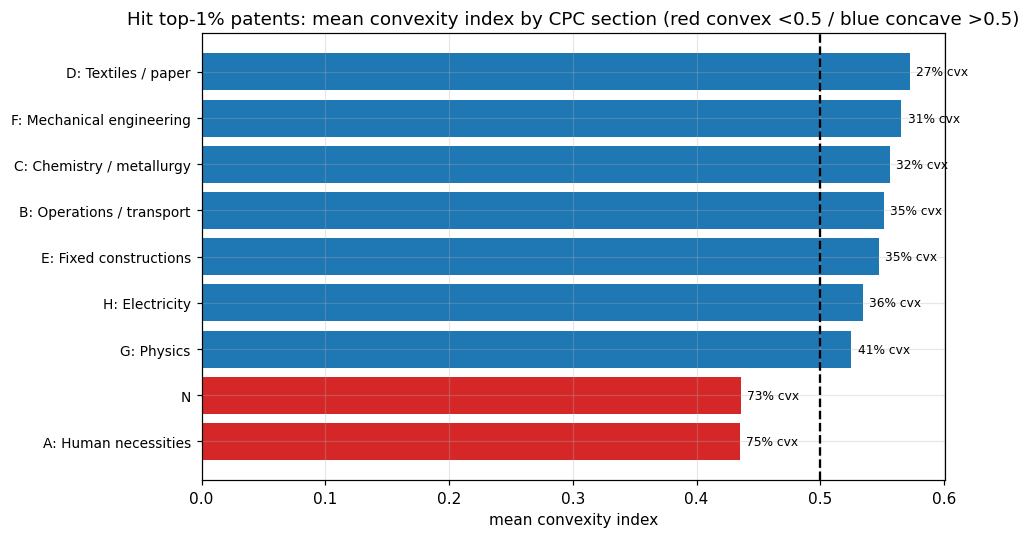

overall (hit top-1%): {'convex%': 41.6, 'concave%': 58.4, 'mean_cvx': 0.526}
\nconvex vs concave group properties:
             n  mean_cvx  mean_citations  mean_SB_B
shape                                              
concave  35791      0.63          119.96       5.89
convex   25503      0.39          347.70      19.73
\nmean convexity index / %convex by CPC section:


,mean_cvx,pct_convex,n,section_name
cpc_section,,,,
A,0.435,75.323,8660,A: Human necessities
N,0.436,72.727,11,N
G,0.525,40.880,15345,G: Physics
H,0.534,36.135,14064,H: Electricity
E,0.547,35.294,1751,E: Fixed constructions
B,0.551,34.718,9030,B: Operations / transport
C,0.556,31.572,7022,C: Chemistry / metallurgy
F,0.566,30.968,4750,F: Mechanical engineering
D,0.572,26.626,661,D: Textiles / paper


Spearman(SB_B, convexity index) = -0.323  (negative = higher SB -> more convex)
done — patent hit-top-1% convexity analysis rendered inline.


In [18]:
pct_convex = (per['cvx'] < 0.5).mean() * 100
bys = per.dropna(subset=['cpc_section']).groupby('cpc_section').agg(
    mean_cvx=('cvx', 'mean'), pct_convex=('cvx', lambda x: (x < 0.5).mean() * 100), n=('cvx', 'size')).sort_values('mean_cvx')
bys['section_name'] = [CPC_NAMES.get(s, s) for s in bys.index]
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if a < 0.5 else '#1f77b4' for a in bys['mean_cvx']]
ax.barh(range(len(bys)), bys['mean_cvx'], color=colors)
ax.set_yticks(range(len(bys))); ax.set_yticklabels(bys['section_name'].values, fontsize=9)
ax.axvline(0.5, color='k', ls='--'); ax.set_xlabel('mean convexity index')
for i, (a, p) in enumerate(zip(bys['mean_cvx'], bys['pct_convex'])):
    ax.text(a + 0.005, i, f'{p:.0f}% cvx', va='center', fontsize=8)
ax.set_title('Hit top-1% patents: mean convexity index by CPC section (red convex <0.5 / blue concave >0.5)')
plt.tight_layout(); V.save('14b')
print('overall (hit top-1%):', {'convex%': round(pct_convex, 1), 'concave%': round(100 - pct_convex, 1), 'mean_cvx': round(per.cvx.mean(), 3)})
print('\\nconvex vs concave group properties:')
print(per.groupby('shape').agg(n=('cvx', 'size'), mean_cvx=('cvx', 'mean'),
      mean_citations=('tot', 'mean'), mean_SB_B=('SB_B', 'mean')).round(2).to_string())
print('\\nmean convexity index / %convex by CPC section:'); display(bys.round(3))
sp = pd.DataFrame({'sb': per['SB_B'], 'cvx': per['cvx']}).replace([np.inf, -np.inf], np.nan).dropna()
print(f'Spearman(SB_B, convexity index) = {sp.sb.rank().corr(sp.cvx.rank()):+.3f}  (negative = higher SB -> more convex)')
print('done — patent hit-top-1% convexity analysis rendered inline.')

## 15. Cumulative trajectory convexity — EXTENDED network (granted + application citations), hit top-1%

Repeats the §14 convexity test but on the **extended** yearly trajectory: value per year =
`pat2pat_examiner + pat2pat_non_examiner + app2pat_examiner + app2pat_non_examiner` (granted **and**
application/pre-grant citations, from the updated `patent_citation_trend.parquet`). Same hit top-1%
cohort (uniqueC_5 top-1%, shared with §14), same convexity index convexity rule (`<0.5` convex). Compares each patent's granted-only convexity index
(`per`, from §14) against its extended convexity index, so we can see whether adding application citations shifts the
convex/concave verdict. Reuses the open DuckDB connection `con` and the helpers `GX`, `NB`, `cvx`, `overall`.

In [19]:
%%time
TOT = "(pat2pat_examiner+pat2pat_non_examiner+app2pat_examiner+app2pat_non_examiner)"
AGG_E = (f"SELECT patent_id, sum{TOT} tot, max(yrs_since_grant) span "
         f"FROM read_parquet('{TREND}') WHERE patent_id IN (SELECT patent_id FROM hit1) "
         f"GROUP BY patent_id HAVING sum{TOT}>=10 AND max(yrs_since_grant)>=5")
Q_PE = (f"WITH agg AS ({AGG_E}) "
        f"SELECT t.patent_id, a.tot, a.span, "
        f"1 - sum({TOT}*(t.yrs_since_grant::double/a.span))/a.tot AS cvx "
        f"FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id) "
        f"GROUP BY t.patent_id, a.tot, a.span")
per_e = con.execute(Q_PE).fetchdf()
per_e = per_e.merge(df[['patent_id', 'cpc_section', 'SB_B']], on='patent_id', how='left')
per_e['shape'] = np.where(per_e['cvx'] < 0.5, 'convex', 'concave')

def mean_traj_e(id_series=None):
    where = ''
    if id_series is not None:
        con.register('flte', pd.DataFrame({'patent_id': id_series.values})); where = 'JOIN flte USING (patent_id)'
    q = (f"WITH agg AS ({AGG_E}), j AS ("
         f"SELECT (t.yrs_since_grant::double/a.span) nt, {TOT} v, a.tot, t.patent_id "
         f"FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id) {where}) "
         f"SELECT least(floor(nt*{NB}),{NB}) b, sum(v::double/tot) w FROM j GROUP BY b ORDER BY b")
    h = con.execute(q).fetchdf()
    N = len(id_series) if id_series is not None else len(per_e)
    wv = np.zeros(NB + 1); wv[h['b'].astype(int).values] = h['w'].values
    return np.cumsum(wv) / N

overall_e = mean_traj_e()
print(f'extended hit-1% patents with trajectory: {len(per_e):,}')
print(f'granted-only : {(per.cvx<0.5).mean()*100:5.1f}% convex, mean convexity index {per.cvx.mean():.3f}')
print(f'extended     : {(per_e.cvx<0.5).mean()*100:5.1f}% convex, mean convexity index {per_e.cvx.mean():.3f}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

extended hit-1% patents with trajectory: 69,256
granted-only :  41.6% convex, mean convexity index 0.526
extended     :  35.4% convex, mean convexity index 0.547
CPU times: user 12.1 s, sys: 547 ms, total: 12.6 s
Wall time: 10.3 s


  [fig] patent_validation_15.jpg + .pdf  (600 dpi)


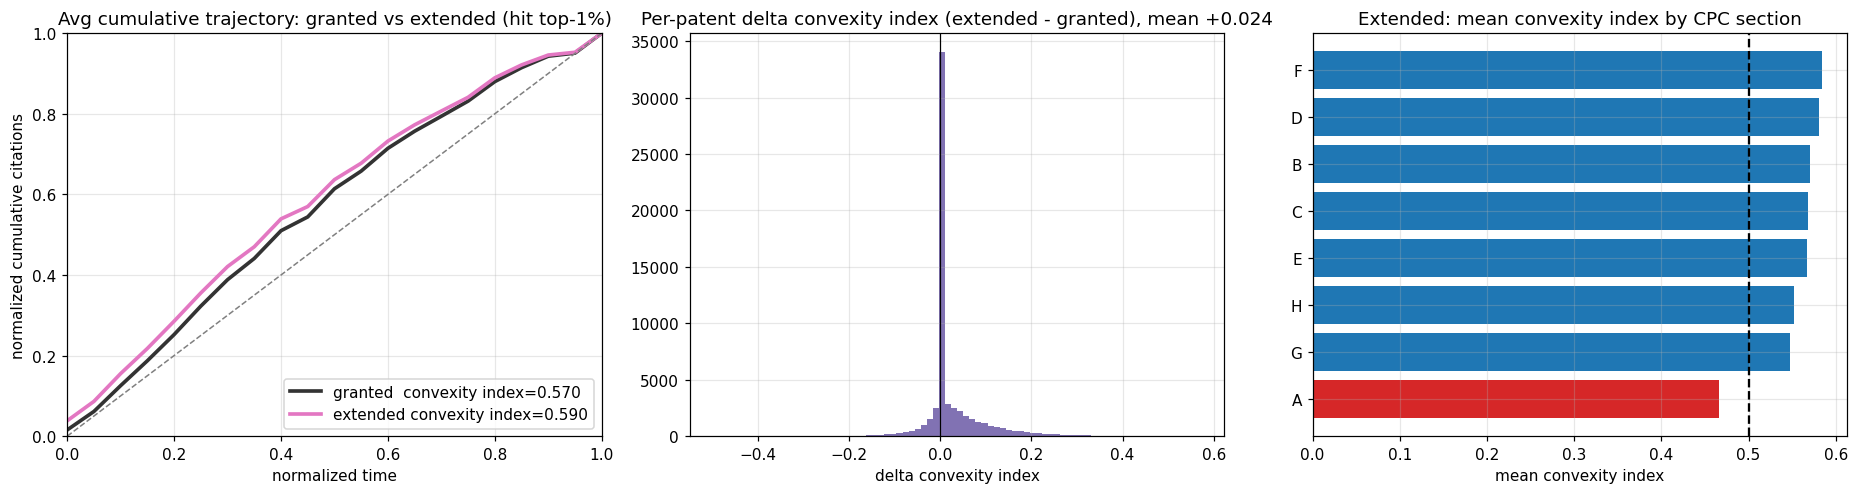

per-patent convexity index delta: 14.4% more convex, 37.7% more concave (mean delta +0.0235)
Spearman(granted convexity index, extended convexity index): 0.8829
verdict flipped (convex<->concave) for 10.8% of patents (common cohort n=61,294)

extended convex vs concave group properties:
             n  mean_cvx  mean_citations  mean_SB_B
shape                                              
concave  44761      0.62          188.47   5.770000
convex   24495      0.41          483.84  19.879999

extended: mean convexity index / %convex by CPC section:


,mean_cvx,pct_convex,n
cpc_section,,,
A,0.466,64.054,8802
G,0.547,35.137,17776
H,0.552,31.315,16928
E,0.567,29.478,1876
C,0.569,28.895,7773
B,0.570,29.637,10045
D,0.581,23.983,713
F,0.584,25.187,5217


done — extended-network convexity (granted + application) rendered inline.
CPU times: user 1.21 s, sys: 75.2 ms, total: 1.29 s
Wall time: 1.51 s


In [20]:
%%time
cmp = per[['patent_id', 'cvx']].rename(columns={'cvx': 'cvx_g'}).merge(
      per_e[['patent_id', 'cvx']].rename(columns={'cvx': 'cvx_e'}), on='patent_id')
dd = cmp['cvx_e'] - cmp['cvx_g']
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].plot(GX, overall, color='#333333', lw=2.4, label=f'granted  convexity index={cvx_area(overall):.3f}')
ax[0].plot(GX, overall_e, color='#e377c2', lw=2.4, label=f'extended convexity index={cvx_area(overall_e):.3f}')
ax[0].plot([0, 1], [0, 1], color='gray', ls='--', lw=1); ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
ax[0].set_title('Avg cumulative trajectory: granted vs extended (hit top-1%)')
ax[0].set_xlabel('normalized time'); ax[0].set_ylabel('normalized cumulative citations'); ax[0].legend(loc='lower right')
ax[1].hist(dd.values, bins=80, color='#8172b3'); ax[1].axvline(0, color='k', lw=0.8)
ax[1].set_title(f'Per-patent delta convexity index (extended - granted), mean {dd.mean():+.3f}'); ax[1].set_xlabel('delta convexity index')
byse = per_e.dropna(subset=['cpc_section']).groupby('cpc_section').agg(
    mean_cvx=('cvx', 'mean'), pct_convex=('cvx', lambda x: (x < 0.5).mean() * 100), n=('cvx', 'size')).sort_values('mean_cvx')
byse = byse[byse.index.isin(list('ABCDEFGHY'))]
colors = ['#d62728' if a < 0.5 else '#1f77b4' for a in byse['mean_cvx']]
ax[2].barh(range(len(byse)), byse['mean_cvx'], color=colors)
ax[2].set_yticks(range(len(byse))); ax[2].set_yticklabels(byse.index)
ax[2].axvline(0.5, color='k', ls='--'); ax[2].set_xlabel('mean convexity index')
ax[2].set_title('Extended: mean convexity index by CPC section')
plt.tight_layout(); V.save('15')
print(f'per-patent convexity index delta: {100*(dd<0).mean():.1f}% more convex, {100*(dd>0).mean():.1f}% more concave '
      f'(mean delta {dd.mean():+.4f})')
print('Spearman(granted convexity index, extended convexity index):', round(cmp[['cvx_g', 'cvx_e']].corr(method='spearman').iloc[0, 1], 4))
flip = (cmp['cvx_g'] < 0.5) != (cmp['cvx_e'] < 0.5)
print(f'verdict flipped (convex<->concave) for {100*flip.mean():.1f}% of patents (common cohort n={len(cmp):,})')
print('\nextended convex vs concave group properties:')
print(per_e.groupby('shape').agg(n=('cvx', 'size'), mean_cvx=('cvx', 'mean'),
      mean_citations=('tot', 'mean'), mean_SB_B=('SB_B', 'mean')).round(2).to_string())
print('\nextended: mean convexity index / %convex by CPC section:'); display(byse.round(3))
print('done — extended-network convexity (granted + application) rendered inline.')

### 15a. Trajectory by CPC section — hit top-1%, granted vs extended

§15 compares the two networks only in aggregate. Resolved by CPC section, the question is
whether adding application citations shifts the accrual *shape* uniformly across technologies
or only where pre-grant citation traffic is dense. Each panel is one section's mean cumulative
trajectory; a curve below the diagonal is convex — citations arrive late.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] patent_validation_15a.jpg + .pdf  (600 dpi)


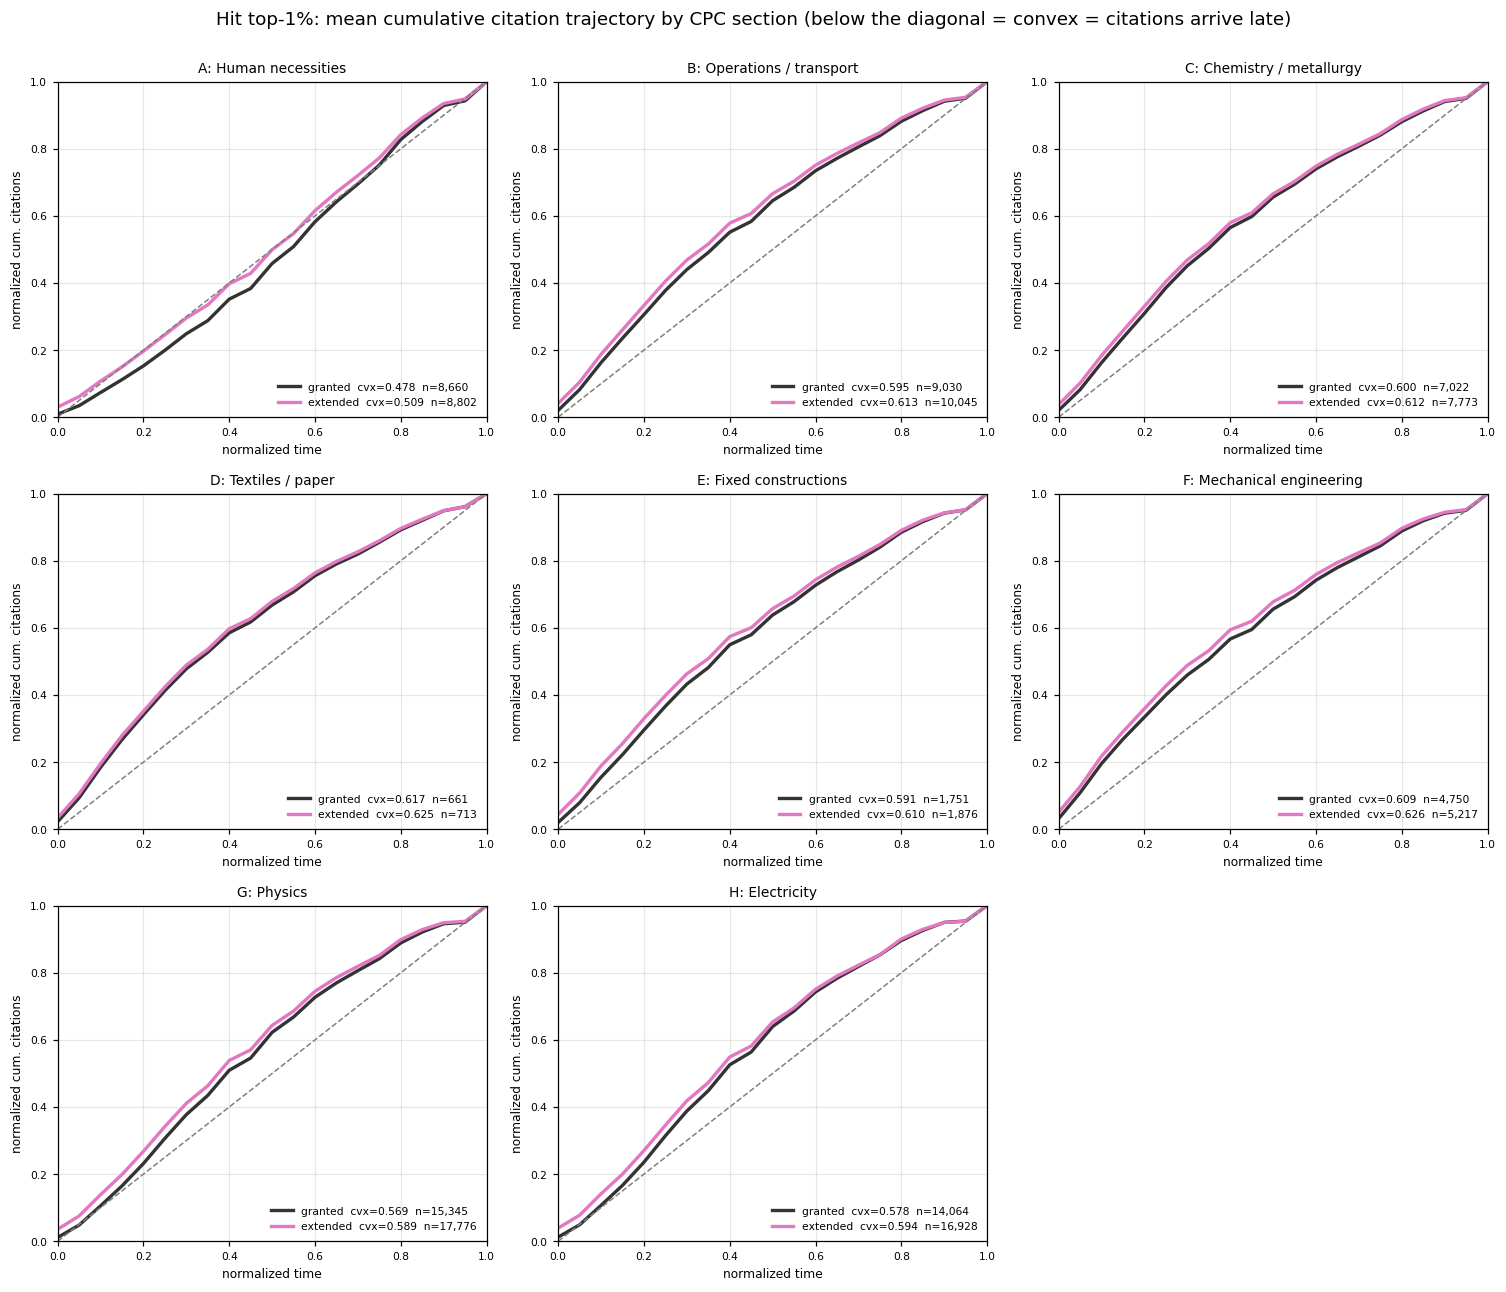

,n,cvx_granted,cvx_extended,delta
section,,,,
A: Human necessities,8802,0.4784,0.5088,0.0304
B: Operations / transport,10045,0.5954,0.6132,0.0178
C: Chemistry / metallurgy,7773,0.6002,0.6116,0.0113
D: Textiles / paper,713,0.6169,0.6249,0.0080
E: Fixed constructions,1876,0.5910,0.6096,0.0186
F: Mechanical engineering,5217,0.6089,0.6260,0.0171
G: Physics,17776,0.5686,0.5892,0.0206
H: Electricity,16928,0.5777,0.5938,0.0160


CPU times: user 15 s, sys: 539 ms, total: 15.5 s
Wall time: 10.9 s


In [21]:
%%time
# Shared machinery for 15a-15c. Section 15 above compares the two networks only in
# aggregate; these cells resolve it by CPC section, and then drop the hit top-1%
# restriction entirely so the trajectory shape can be read for the whole corpus.
METAP15 = os.path.join(POUT, 'patent_metadata.parquet').replace(os.sep, '/')
TOT_G = "(pat2pat_examiner+pat2pat_non_examiner)"                       # granted only, as in 14
TOT_E = TOT                                                            # extended, as in 15
SECS = list('ABCDEFGHY')
MIN_SEC = 200          # sections with fewer patents than this are not drawn

def _agg(tot, hit_only):
    where = "WHERE patent_id IN (SELECT patent_id FROM hit1) " if hit_only else ""
    return (f"SELECT patent_id, sum{tot} tot, max(yrs_since_grant) span "
            f"FROM read_parquet('{TREND}') {where}"
            f"GROUP BY patent_id HAVING sum{tot}>=10 AND max(yrs_since_grant)>=5")

def traj_overall(tot, hit_only):
    # Mean cumulative trajectory over every qualifying patent.
    agg = _agg(tot, hit_only)
    h = con.execute(f"WITH agg AS ({agg}), j AS ("
        f"SELECT least(floor((t.yrs_since_grant::double/a.span)*{NB}),{NB}) b, "
        f"{tot}::double/a.tot w FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id)) "
        f"SELECT b, sum(w) w FROM j GROUP BY b ORDER BY b").fetchdf()
    n = con.execute(f"WITH agg AS ({agg}) SELECT count(*) FROM agg").fetchone()[0]
    wv = np.zeros(NB + 1); wv[h['b'].astype(int).values] = h['w'].values
    return np.cumsum(wv) / n, int(n)

def traj_by_section(tot, hit_only):
    # Same, resolved by CPC section. One pass over the trend for the curves and one
    # for the per-section denominators; both restricted to patents that carry a CPC.
    agg = _agg(tot, hit_only)
    sec = (f"SELECT patent_id, substr(cpc_code,1,1) s FROM read_parquet('{METAP15}') "
           f"WHERE cpc_code IS NOT NULL")
    h = con.execute(f"WITH agg AS ({agg}), sec AS ({sec}), j AS ("
        f"SELECT sec.s s, least(floor((t.yrs_since_grant::double/a.span)*{NB}),{NB}) b, "
        f"{tot}::double/a.tot w FROM read_parquet('{TREND}') t "
        f"JOIN agg a USING (patent_id) JOIN sec USING (patent_id)) "
        f"SELECT s, b, sum(w) w FROM j GROUP BY s, b ORDER BY s, b").fetchdf()
    cnt = con.execute(f"WITH agg AS ({agg}), sec AS ({sec}) "
        f"SELECT s, count(*) n FROM agg JOIN sec USING (patent_id) GROUP BY s"
        ).fetchdf().set_index('s')['n']
    out = {}
    for s, g in h.groupby('s'):
        if s not in SECS or cnt.get(s, 0) < MIN_SEC:
            continue
        wv = np.zeros(NB + 1); wv[g['b'].astype(int).values] = g['w'].values
        out[s] = (np.cumsum(wv) / cnt[s], int(cnt[s]))
    return out

def per_cvx(tot, hit_only):
    # Per-patent convexity index, same definition as 14/15.
    agg = _agg(tot, hit_only)
    return con.execute(f"WITH agg AS ({agg}) SELECT t.patent_id, a.tot, a.span, "
        f"1 - sum({tot}*(t.yrs_since_grant::double/a.span))/a.tot AS cvx "
        f"FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id) "
        f"GROUP BY t.patent_id, a.tot, a.span").fetchdf()

def panel_grid(gsec, esec, title, section_label):
    # One panel per CPC section: granted vs extended mean cumulative trajectory.
    keys = [s for s in SECS if s in gsec or s in esec]
    ncol = 3; nrow = int(np.ceil(len(keys) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.9 * nrow), squeeze=False)
    for ax_, s in zip(axes.flat, keys):
        for src, lab, c in [(gsec, 'granted', '#333333'), (esec, 'extended', '#e377c2')]:
            if s not in src:
                continue
            y, n = src[s]
            ax_.plot(GX, y, color=c, lw=2.2, label=f'{lab}  cvx={cvx_area(y):.3f}  n={n:,}')
        ax_.plot([0, 1], [0, 1], color='gray', ls='--', lw=1)
        ax_.set_xlim(0, 1); ax_.set_ylim(0, 1)
        ax_.set_title(CPC_NAMES.get(s, s), fontsize=9)
        ax_.set_xlabel('normalized time', fontsize=8)
        ax_.set_ylabel('normalized cum. citations', fontsize=8)
        ax_.legend(loc='lower right', fontsize=7, frameon=False)
        ax_.tick_params(labelsize=7)
    for ax_ in axes.flat[len(keys):]:
        ax_.set_visible(False)
    fig.suptitle(title, fontsize=12, y=1.0)
    V.save(section_label)

g_sec_hit = traj_by_section(TOT_G, True)
e_sec_hit = traj_by_section(TOT_E, True)
panel_grid(g_sec_hit, e_sec_hit,
           'Hit top-1%: mean cumulative citation trajectory by CPC section '
           '(below the diagonal = convex = citations arrive late)', '15a')
rows = []
for s in SECS:
    if s in g_sec_hit and s in e_sec_hit:
        rows.append({'section': CPC_NAMES.get(s, s), 'n': e_sec_hit[s][1],
                     'cvx_granted': cvx_area(g_sec_hit[s][0]),
                     'cvx_extended': cvx_area(e_sec_hit[s][0])})
t = pd.DataFrame(rows).set_index('section')
t['delta'] = t['cvx_extended'] - t['cvx_granted']
display(t.round(4))


### 15b. ALL patents — overall, granted vs extended

§14 and §15 both look only at the hit top-1%, which is the tail this story is usually told
about. The trajectory shape of the corpus is a different question, and it cannot be read off
the top 1%: that cohort is selected on citation count, which is the same quantity whose
arrival time the convexity index measures. Selecting on it and then measuring it is circular.

The only filter kept here is the one the metric needs in order to exist at all — at least 10
citations and a span of at least 5 years. The hit top-1% curves are drawn alongside, dotted,
so the size of the selection effect is visible rather than assumed.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ALL patents with a trajectory  granted 2,349,319 | extended 3,186,228
  (hit top-1% cohort was granted 61,294 | extended 69,256)
granted  :  63.9% convex, mean convexity index 0.449
extended :  62.8% convex, mean convexity index 0.455


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] patent_validation_15b.jpg + .pdf  (600 dpi)


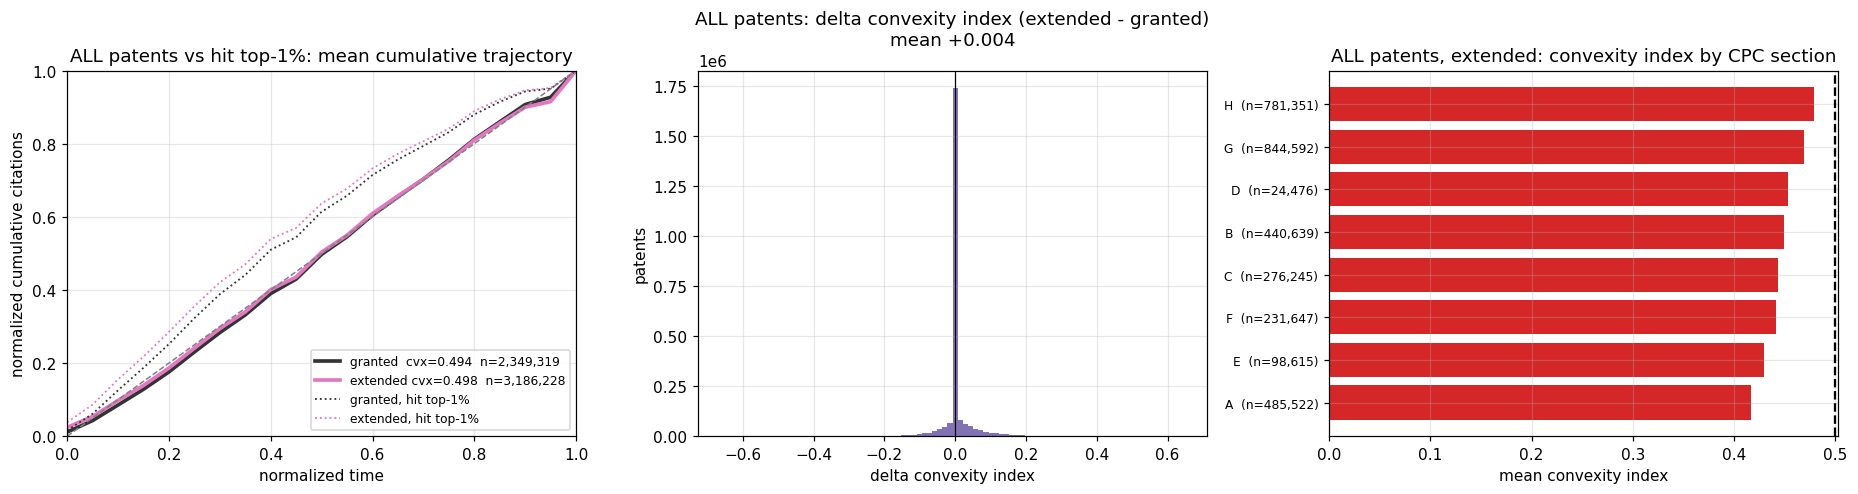


per-patent delta: 12.2% more convex, 17.5% more concave (mean +0.0042, n=2,349,319)
convex<->concave verdict flipped for 4.6% of patents

ALL patents, extended: convexity index by CPC section


,mean_cvx,pct_convex,n
cpc_section,,,
A,0.417,76.031,485522
E,0.429,73.211,98615
F,0.442,67.744,231647
C,0.444,64.822,276245
B,0.449,65.259,440639
D,0.453,62.433,24476
G,0.469,58.391,844592
H,0.479,54.707,781351


CPU times: user 50 s, sys: 2.88 s, total: 52.9 s
Wall time: 44.4 s


In [22]:
%%time
# ---- ALL patents, no hit restriction --------------------------------------------
# 14 and 15 both look only at the hit top-1%, which is the tail the convexity story is
# usually told about. The trajectory shape of the corpus is a different question, and
# the answer is not obtainable from the top 1%: selecting on citations selects on
# exactly the accrual pattern being measured. The only filter kept here is the one the
# metric needs to exist at all (>=10 citations, span >=5 years).
per_all_g = per_cvx(TOT_G, False)
per_all_e = per_cvx(TOT_E, False)
overall_all_g, n_all_g = traj_overall(TOT_G, False)
overall_all_e, n_all_e = traj_overall(TOT_E, False)
print(f'ALL patents with a trajectory  granted {n_all_g:,} | extended {n_all_e:,}')
print(f'  (hit top-1% cohort was granted {len(per):,} | extended {len(per_e):,})')
print(f'granted  : {(per_all_g.cvx<0.5).mean()*100:5.1f}% convex, mean convexity index {per_all_g.cvx.mean():.3f}')
print(f'extended : {(per_all_e.cvx<0.5).mean()*100:5.1f}% convex, mean convexity index {per_all_e.cvx.mean():.3f}')

cmp_all = per_all_g[['patent_id', 'cvx']].rename(columns={'cvx': 'cvx_g'}).merge(
          per_all_e[['patent_id', 'cvx']].rename(columns={'cvx': 'cvx_e'}), on='patent_id')
dd_all = cmp_all['cvx_e'] - cmp_all['cvx_g']

secmap = con.execute(f"SELECT patent_id, substr(cpc_code,1,1) cpc_section "
                     f"FROM read_parquet('{METAP15}') WHERE cpc_code IS NOT NULL").fetchdf()
pa_e = per_all_e.merge(secmap, on='patent_id', how='left')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].plot(GX, overall_all_g, color='#333333', lw=2.4,
           label=f'granted  cvx={cvx_area(overall_all_g):.3f}  n={n_all_g:,}')
ax[0].plot(GX, overall_all_e, color='#e377c2', lw=2.4,
           label=f'extended cvx={cvx_area(overall_all_e):.3f}  n={n_all_e:,}')
ax[0].plot(GX, overall, color='#333333', lw=1.2, ls=':', label='granted, hit top-1%')
ax[0].plot(GX, overall_e, color='#e377c2', lw=1.2, ls=':', label='extended, hit top-1%')
ax[0].plot([0, 1], [0, 1], color='gray', ls='--', lw=1)
ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
ax[0].set_title('ALL patents vs hit top-1%: mean cumulative trajectory')
ax[0].set_xlabel('normalized time'); ax[0].set_ylabel('normalized cumulative citations')
ax[0].legend(loc='lower right', fontsize=8)
ax[1].hist(dd_all.values, bins=90, color='#8172b3'); ax[1].axvline(0, color='k', lw=0.8)
ax[1].set_title(f'ALL patents: delta convexity index (extended - granted)\nmean {dd_all.mean():+.3f}')
ax[1].set_xlabel('delta convexity index'); ax[1].set_ylabel('patents')
bys_all = pa_e.dropna(subset=['cpc_section'])
bys_all = bys_all[bys_all['cpc_section'].isin(SECS)].groupby('cpc_section').agg(
    mean_cvx=('cvx', 'mean'), pct_convex=('cvx', lambda x: (x < 0.5).mean() * 100),
    n=('cvx', 'size')).sort_values('mean_cvx')
colors = ['#d62728' if a < 0.5 else '#1f77b4' for a in bys_all['mean_cvx']]
ax[2].barh(range(len(bys_all)), bys_all['mean_cvx'], color=colors)
ax[2].set_yticks(range(len(bys_all)))
ax[2].set_yticklabels([f'{s}  (n={int(n):,})' for s, n in zip(bys_all.index, bys_all['n'])], fontsize=8)
ax[2].axvline(0.5, color='k', ls='--'); ax[2].set_xlabel('mean convexity index')
ax[2].set_title('ALL patents, extended: convexity index by CPC section')
V.save('15b')

print(f'\nper-patent delta: {100*(dd_all<0).mean():.1f}% more convex, '
      f'{100*(dd_all>0).mean():.1f}% more concave (mean {dd_all.mean():+.4f}, n={len(cmp_all):,})')
flip_all = (cmp_all['cvx_g'] < 0.5) != (cmp_all['cvx_e'] < 0.5)
print(f'convex<->concave verdict flipped for {100*flip_all.mean():.1f}% of patents')
print('\nALL patents, extended: convexity index by CPC section')
display(bys_all.round(3))


### 15c. ALL patents — trajectory by CPC section

§15a for the whole corpus. The table underneath puts the all-patents and hit top-1% convexity
indices side by side per section, which is the selection effect resolved by technology.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] patent_validation_15c.jpg + .pdf  (600 dpi)


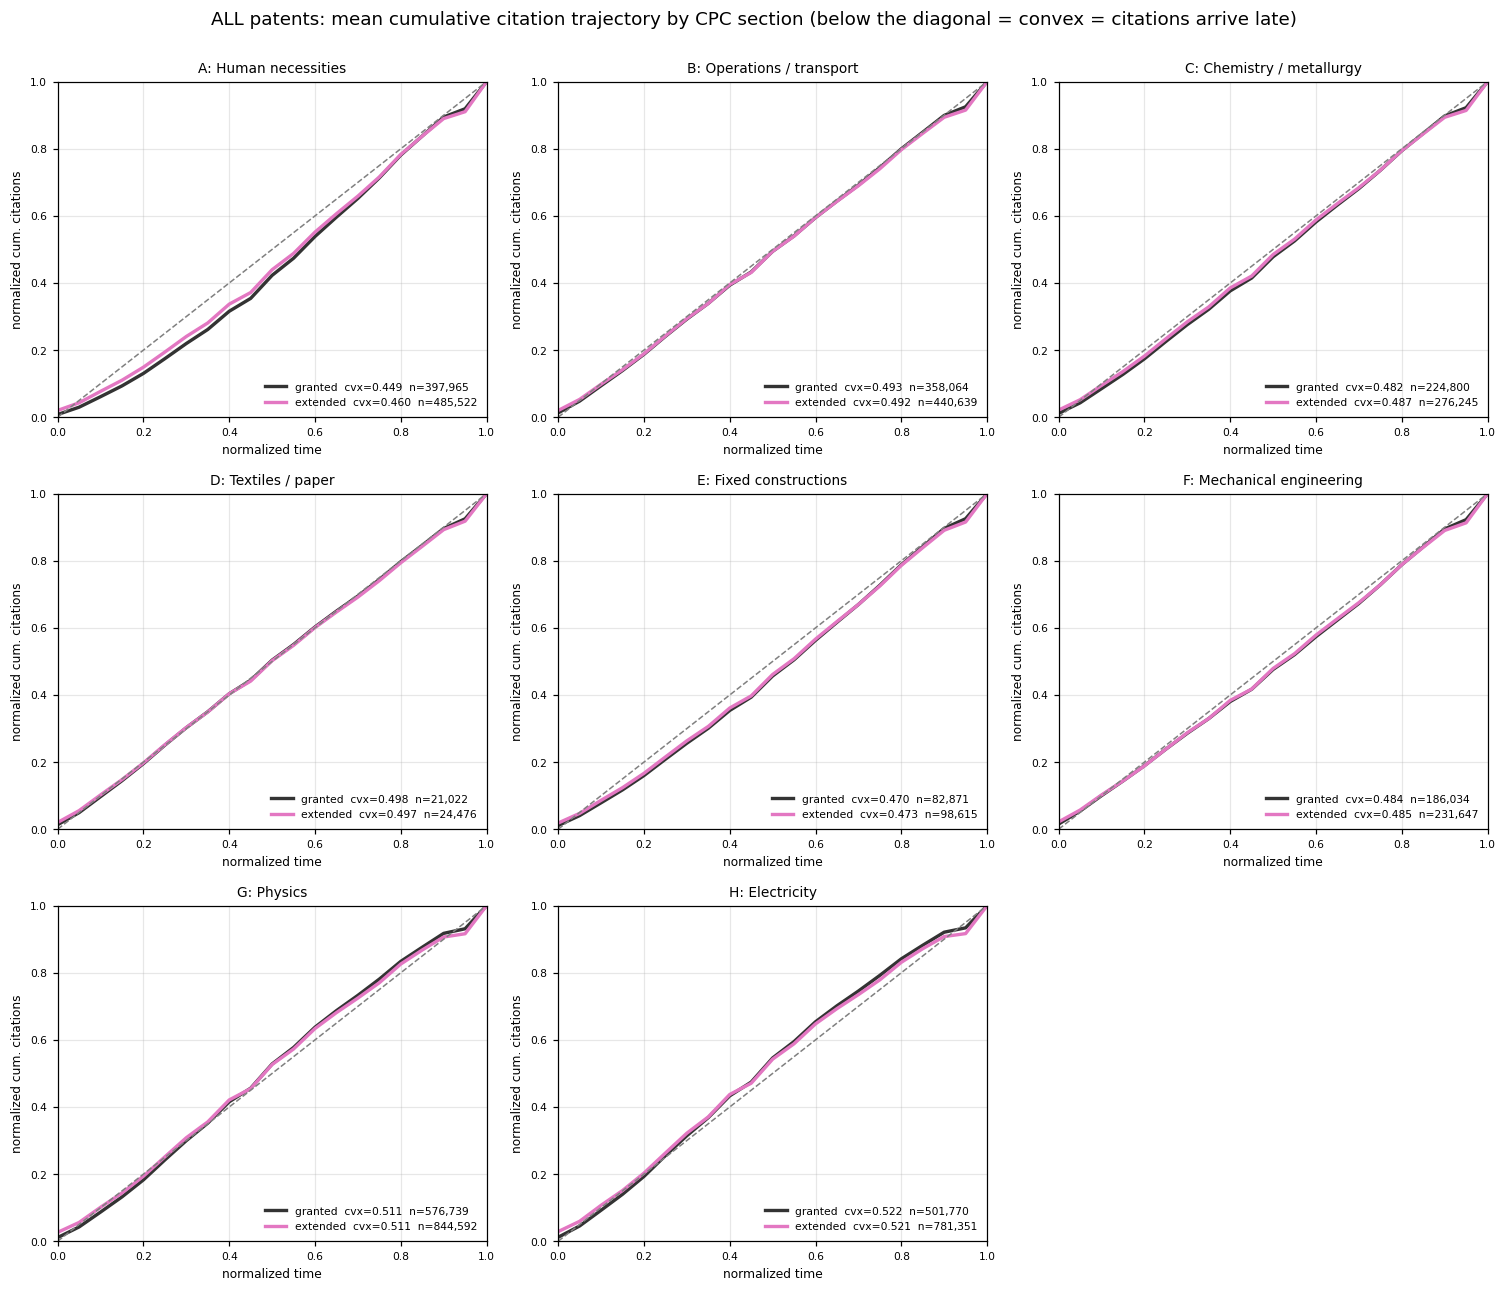

,n_all,all_granted,all_extended,hit1pct_granted,hit1pct_extended
section,,,,,
A: Human necessities,485522,0.4487,0.4598,0.4784,0.5088
B: Operations / transport,440639,0.4928,0.4924,0.5954,0.6132
C: Chemistry / metallurgy,276245,0.4823,0.4868,0.6002,0.6116
D: Textiles / paper,24476,0.4977,0.4971,0.6169,0.6249
E: Fixed constructions,98615,0.4702,0.4728,0.5910,0.6096
F: Mechanical engineering,231647,0.4845,0.4853,0.6089,0.6260
G: Physics,844592,0.5109,0.5113,0.5686,0.5892
H: Electricity,781351,0.5217,0.5205,0.5777,0.5938


Trajectory convexity index per section, all patents vs the hit top-1%. A gap between
the two columns is selection, not a property of the field: the top 1% is chosen on
citation count, which is the same quantity whose arrival time the index measures.
CPU times: user 30.3 s, sys: 1.84 s, total: 32.1 s
Wall time: 16.8 s


In [23]:
%%time
g_sec_all = traj_by_section(TOT_G, False)
e_sec_all = traj_by_section(TOT_E, False)
panel_grid(g_sec_all, e_sec_all,
           'ALL patents: mean cumulative citation trajectory by CPC section '
           '(below the diagonal = convex = citations arrive late)', '15c')

rows = []
for s in SECS:
    if s in g_sec_all and s in e_sec_all:
        r = {'section': CPC_NAMES.get(s, s), 'n_all': e_sec_all[s][1],
             'all_granted': cvx_area(g_sec_all[s][0]), 'all_extended': cvx_area(e_sec_all[s][0])}
        if s in e_sec_hit:
            r['hit1pct_granted'] = cvx_area(g_sec_hit[s][0])
            r['hit1pct_extended'] = cvx_area(e_sec_hit[s][0])
        rows.append(r)
comp = pd.DataFrame(rows).set_index('section')
display(comp.round(4))
print('Trajectory convexity index per section, all patents vs the hit top-1%. A gap between')
print('the two columns is selection, not a property of the field: the top 1% is chosen on')
print('citation count, which is the same quantity whose arrival time the index measures.')


## 16. Yearly-trend convexity — Disruption / F / E / G / ni / nj / nk (overall & by CPC section)

Applies the same min–max + convexity index test to the **time trend** of each metric (mean value by grant year):
each metric's yearly series is min–max scaled on both axes and its **convexity index** is measured (`<0.5` **convex**
= accelerating / late upturn; `>0.5` **concave** = early rise then flattening). Computed overall and for
each **CPC section**. Uses `patent_disruption` ⋈ `patent_metadata` (grant year in a truncation-safe range).

In [24]:
%%time
DISRP = os.path.join(POUT, 'patent_disruption.parquet').replace(os.sep, '/')
METAP = os.path.join(POUT, 'patent_metadata.parquet').replace(os.sep, '/')
METR = ['CD_5', 'F_5', 'E_5', 'G_5', 'ni_5', 'nj_5', 'nk_5']
YR0, YR1 = 1980, 2015                       # avoid the most citation-truncated recent years
avgs = ', '.join([f'avg(d.{m}) {m}' for m in METR])
ov = con.execute(f'''SELECT m.grant_year AS yr, {avgs}
  FROM read_parquet('{DISRP}') d JOIN read_parquet('{METAP}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.grant_year BETWEEN {YR0} AND {YR1}
  GROUP BY yr ORDER BY yr''').fetchdf()
bysec = con.execute(f'''SELECT m.grant_year AS yr, substr(m.cpc_code,1,1) AS secn, count(*) n, {avgs}
  FROM read_parquet('{DISRP}') d JOIN read_parquet('{METAP}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.grant_year BETWEEN {YR0} AND {YR1} AND m.cpc_code IS NOT NULL
  GROUP BY yr, secn ORDER BY secn, yr''').fetchdf()

def trend_cvx(t, y):
    t = np.asarray(t, float); y = np.asarray(y, float); ok = np.isfinite(y)
    t, y = t[ok], y[ok]
    if len(y) < 6 or y.max() == y.min(): return np.nan
    tn = (t - t.min()) / (t.max() - t.min()); yn = (y - y.min()) / (y.max() - y.min())
    return float(np.trapz(yn, tn))

print(f'overall yearly-trend convexity index per metric ({YR0}-{YR1}; <0.5 convex / >0.5 concave):')
for m in METR:
    a = trend_cvx(ov['yr'].values, ov[m].values)
    print(f'  {m:8s} convexity index {a:.3f}  ({"convex" if a < 0.5 else "concave"})')

overall yearly-trend convexity index per metric (1980-2015; <0.5 convex / >0.5 concave):
  CD_5     convexity index 0.236  (convex)
  F_5      convexity index 0.554  (concave)
  E_5      convexity index 0.657  (concave)
  G_5      convexity index 0.309  (convex)
  ni_5     convexity index 0.437  (convex)
  nj_5     convexity index 0.524  (concave)
  nk_5     convexity index 0.314  (convex)
CPU times: user 3.21 s, sys: 275 ms, total: 3.49 s
Wall time: 1.78 s


### 16a. Overall metric trends (min–max scaled) + convexity

  [fig] patent_validation_16a.jpg + .pdf  (600 dpi)


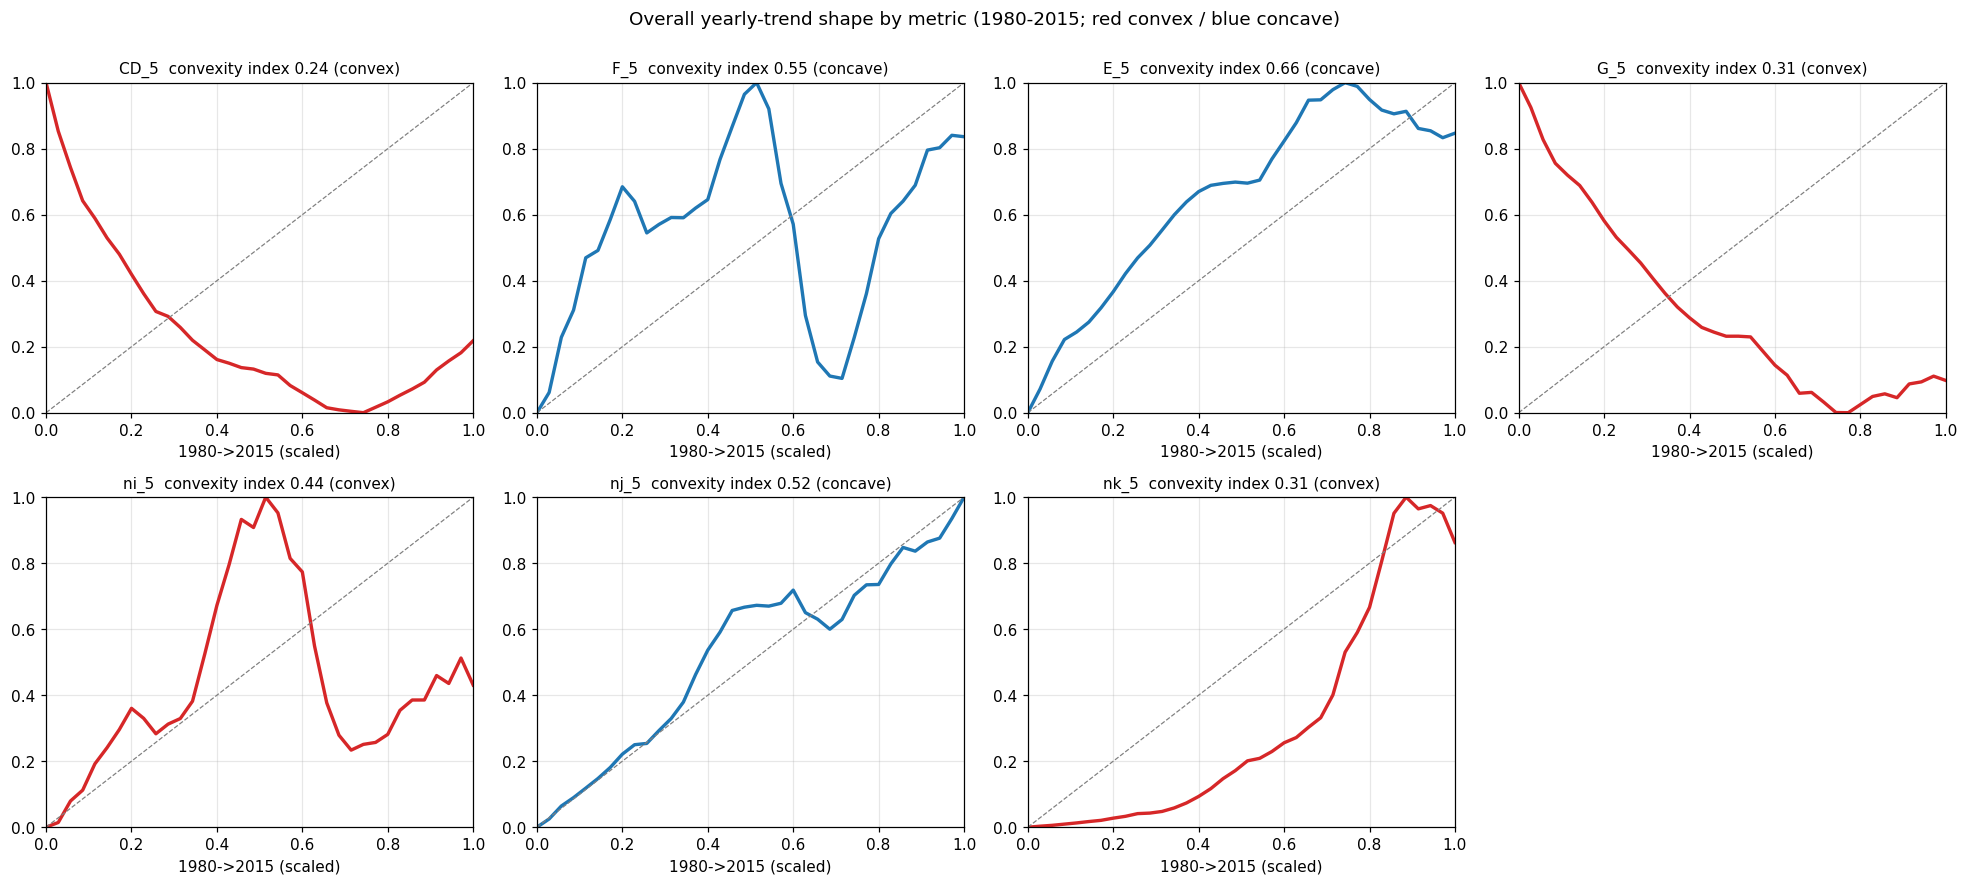

['/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_16a.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_16a.pdf']

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, m in zip(axes.flat, METR):
    t = ov['yr'].values.astype(float); y = ov[m].values.astype(float)
    tn = (t - t.min()) / (t.max() - t.min()); yn = (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y))
    a = trend_cvx(t, y); col = '#d62728' if a < 0.5 else '#1f77b4'
    ax.plot(tn, yn, color=col, lw=2.2); ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8)
    ax.set_title(f'{m}  convexity index {a:.2f} ({"convex" if a < 0.5 else "concave"})', fontsize=10)
    ax.set_xlabel(f'{YR0}->{YR1} (scaled)'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes.flat[-1].set_visible(False)
fig.suptitle(f'Overall yearly-trend shape by metric ({YR0}-{YR1}; red convex / blue concave)', y=1.0)
plt.tight_layout(); V.save('16a')

### 16b. Convexity of yearly trends by CPC section (convexity index heatmap)

  [fig] patent_validation_16b.jpg + .pdf  (600 dpi)


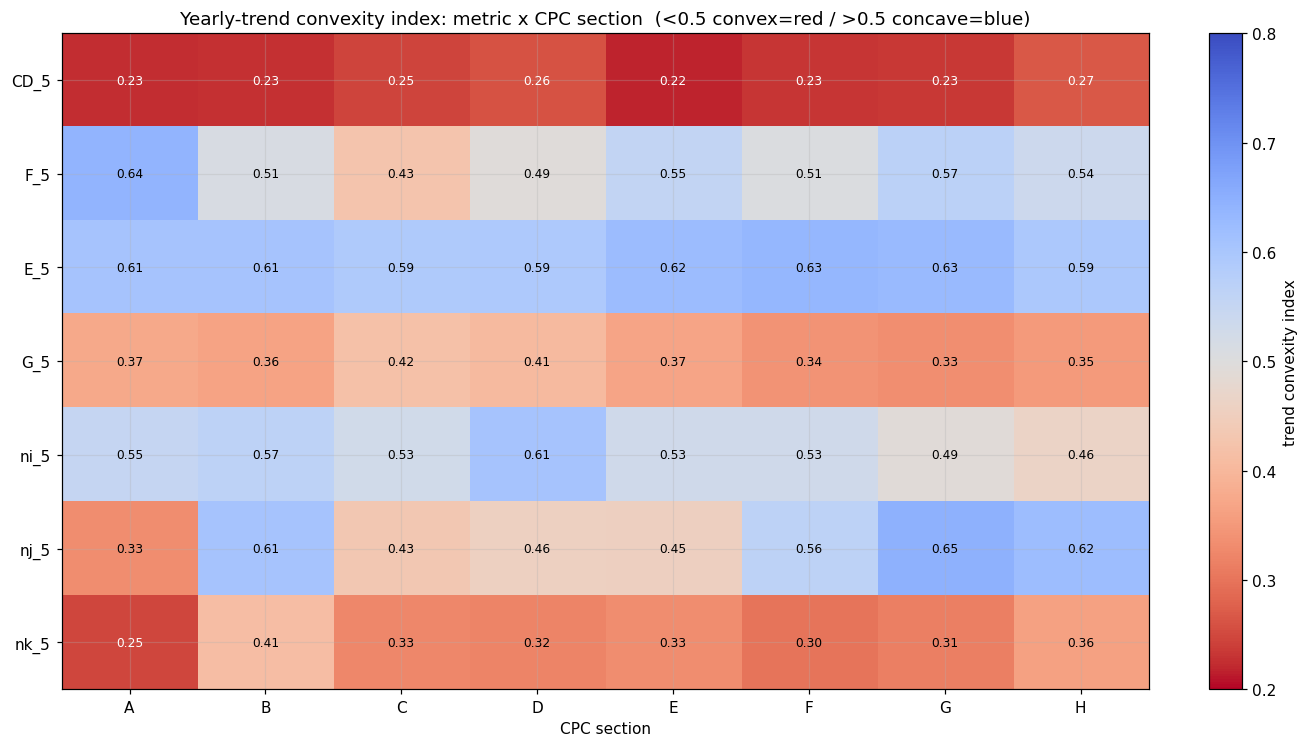

trend convexity index by metric x CPC section:


,A,B,C,D,E,F,G,H
CD_5,0.225,0.227,0.246,0.261,0.218,0.231,0.234,0.267
F_5,0.639,0.512,0.426,0.494,0.555,0.505,0.570,0.537
E_5,0.608,0.608,0.591,0.592,0.624,0.635,0.629,0.594
G_5,0.375,0.364,0.419,0.406,0.367,0.341,0.334,0.352
ni_5,0.550,0.565,0.527,0.606,0.530,0.530,0.492,0.464
nj_5,0.332,0.607,0.432,0.456,0.454,0.564,0.648,0.620
nk_5,0.248,0.412,0.325,0.322,0.332,0.299,0.313,0.364


done — yearly-trend convexity (overall & by CPC section) rendered inline.


In [26]:
secs = [s for s in list('ABCDEFGHY') if s in set(bysec['secn'].dropna().unique())]
Hmat = np.full((len(METR), len(secs)), np.nan)
for j, sc in enumerate(secs):
    g = bysec[bysec['secn'] == sc].sort_values('yr')
    if g['n'].sum() < 500:
        continue
    for i, m in enumerate(METR):
        Hmat[i, j] = trend_cvx(g['yr'].values, g[m].values)
fig, ax = plt.subplots(figsize=(1.0 * len(secs) + 4, 0.7 * len(METR) + 2))
im = ax.imshow(Hmat, cmap='coolwarm_r', vmin=0.2, vmax=0.8, aspect='auto')   # <0.5 convex=red, >0.5 concave=blue
ax.set_xticks(range(len(secs))); ax.set_xticklabels(secs)
ax.set_yticks(range(len(METR))); ax.set_yticklabels(METR)
for i in range(len(METR)):
    for j in range(len(secs)):
        if np.isfinite(Hmat[i, j]):
            ax.text(j, i, f'{Hmat[i, j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(Hmat[i, j] - 0.5) > 0.22 else 'black')
ax.set_title('Yearly-trend convexity index: metric x CPC section  (<0.5 convex=red / >0.5 concave=blue)')
fig.colorbar(im, fraction=0.046, label='trend convexity index')
ax.set_xlabel('CPC section'); plt.tight_layout(); V.save('16b')
summ = pd.DataFrame(Hmat, index=METR, columns=secs)
print('trend convexity index by metric x CPC section:'); display(summ.round(3))
print('done — yearly-trend convexity (overall & by CPC section) rendered inline.')

## 17. Team size (inventors) -> disruption percentile & impact (Wu et al. Fig 2a style)

Patent analogue of the paper Fig 2a: **team size = number of inventors** (`inventor_list`), **impact =
patent->patent citations (`C_5`)**, disruption = percentile of `CD_5`. Small teams should disrupt more,
large teams should be cited more. Grant years 1980-2015, `ref_count>=1`, inventors 1-10.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 team_size       dis   dis_ci      cit   cit_ci       n
         1 47.504180 0.047574 3.693020 0.011930 1656589
         2 46.976009 0.057001 4.347132 0.018700 1070091
         3 46.508608 0.069883 4.761203 0.026713  679627
         4 46.298268 0.091667 5.028891 0.037215  384342
         5 45.827415 0.127213 5.445517 0.058554  195858
         6 45.514292 0.176095 5.804797 0.089154  102022
         7 44.753925 0.241822 6.115969 0.126179   52626
         8 44.671372 0.329657 6.448061 0.193790   28572
         9 44.078230 0.449519 6.726511 0.248221   15401
        10 43.977104 0.569380 7.736298 0.482215    9488
  [fig] patent_validation_17.jpg + .pdf  (600 dpi)


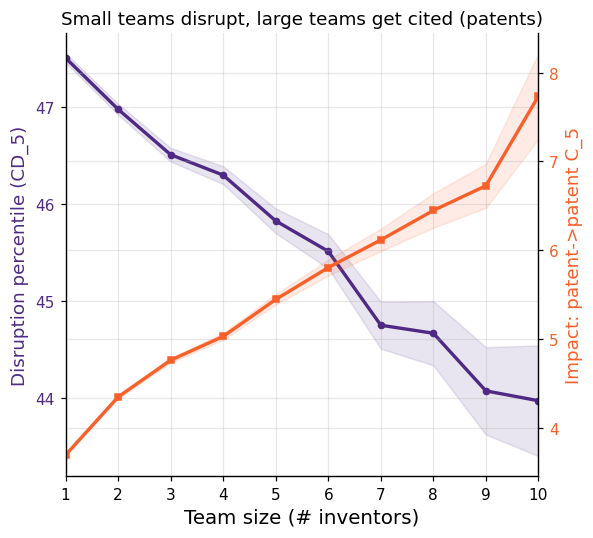

done — patent team-size Fig 2a rendered inline.
CPU times: user 4.49 s, sys: 425 ms, total: 4.91 s
Wall time: 3.01 s


In [27]:
%%time
DISRp = os.path.join(POUT, 'patent_disruption.parquet').replace(os.sep, '/')
CITp = os.path.join(POUT, 'patent_citation.parquet').replace(os.sep, '/')
METAp = os.path.join(POUT, 'patent_metadata.parquet').replace(os.sep, '/')
q = f'''
WITH base AS (
  SELECT d.CD_5, c.C_5, len(str_split(m.inventor_list, ';')) AS team_size
  FROM read_parquet('{DISRp}') d
  JOIN read_parquet('{CITp}') c USING (patent_id)
  JOIN read_parquet('{METAp}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.inventor_list IS NOT NULL
    AND m.ref_count >= 1 AND m.grant_year BETWEEN 1980 AND 2015),
filt AS (SELECT * FROM base WHERE team_size BETWEEN 1 AND 10),
ranked AS (SELECT team_size, C_5, percent_rank() OVER (ORDER BY CD_5) AS dpct FROM filt)
SELECT team_size, avg(dpct)*100 AS dis, 1.96*stddev(dpct)/sqrt(count(*))*100 AS dis_ci,
       avg(C_5) AS cit, 1.96*stddev(C_5)/sqrt(count(*)) AS cit_ci, count(*) AS n
FROM ranked GROUP BY team_size ORDER BY team_size'''
g = con.execute(q).fetchdf(); print(g.to_string(index=False))
x = g['team_size'].values; c1, c2 = '#4E2A84', '#F7602A'
fig, ax = plt.subplots(figsize=(5.5, 5)); ax2 = ax.twinx()
ax.plot(x, g['dis'], color=c1, lw=2.2, marker='o', ms=4)
ax2.plot(x, g['cit'], color=c2, lw=2.2, marker='s', ms=4)
ax.fill_between(x, g['dis'] - g['dis_ci'], g['dis'] + g['dis_ci'], color=c1, alpha=0.12)
ax2.fill_between(x, g['cit'] - g['cit_ci'], g['cit'] + g['cit_ci'], color=c2, alpha=0.12)
ax.set_xlabel('Team size (# inventors)', size=13)
ax.set_ylabel('Disruption percentile (CD_5)', size=12, color=c1); ax2.set_ylabel('Impact: patent->patent C_5', size=12, color=c2)
ax.tick_params(axis='y', labelcolor=c1); ax2.tick_params(axis='y', labelcolor=c2)
ax.set_xlim(1, 10); ax.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False)
ax.set_title('Small teams disrupt, large teams get cited (patents)')
plt.tight_layout(); V.save('17')
print('done — patent team-size Fig 2a rendered inline.')

## 18. Atypicality Z-score CDF (reference style: 10th-pct & Median)

In [28]:
%%time
import matplotlib.ticker as _tk
MIN_N = 1000

def find_nearest(array, value):
    array = np.asarray(array)
    return int((np.abs(array - value)).argmin())

def plot_atyp_cdf(df_, col_10pct, col_median, title,
                  ylabel='CDF of journal papers',
                  label1=r'$10^{\rm th}$ percentile $Z$-score', label2=r'Median $Z$-score'):
    """CDF of Atyp Z-scores at 24 thresholds: 8 neg (-2^8..-2^1) | 0 | 15 pos (2^1..2^15)."""
    plt.rcParams['text.usetex'] = False
    label_x1 = np.array([(x + 1) for x in range(8)])[::-1]
    label_x2 = np.array([0])
    label_x3 = np.array([(x + 1) for x in range(15)])
    label_x = np.concatenate((label_x1, label_x2, label_x3))
    atyp_x = np.arange(1, 25)

    def myticks(x, pos):
        i = int(round(x)) - 1
        if i < 0 or i >= len(label_x): return ''
        v = label_x[i]
        if x < 9:
            return r'$-2^{%d}$' % v if int(round(x)) % 2 != 0 else ''
        elif x == 9:
            return r'$0$'
        else:
            return r'$2^{%d}$' % v if int(round(x)) % 2 != 0 else ''

    def compute_cdf(col):
        if col not in df_.columns:
            print(f'  [skip] {col} not in data'); return None
        vals = df_[col].replace([np.inf, -np.inf], np.nan).dropna().values
        if len(vals) < MIN_N: return None
        zs = np.sort(vals)
        pos1 = np.array([find_nearest(zs, -2 ** (x + 1)) for x in range(8)])[::-1]
        pos2 = np.array([find_nearest(zs, 0)])
        pos3 = np.array([find_nearest(zs, 2 ** (x + 1)) for x in range(15)])
        return np.concatenate((pos1, pos2, pos3)) / len(zs)

    pct_p = compute_cdf(col_10pct); pct_p2 = compute_cdf(col_median)
    if pct_p is None and pct_p2 is None:
        print(f'  [skip plot] no data for {col_10pct!r} / {col_median!r}'); return
    fig, ax = plt.subplots(dpi=150)
    if pct_p is not None:
        ax.plot(atyp_x, pct_p, 'o-', ms=9, markeredgewidth=2, lw=2, label=label1, markerfacecolor='none', alpha=0.7)
    if pct_p2 is not None:
        ax.plot(atyp_x, pct_p2, 'o-', ms=9, markeredgewidth=2, lw=2, label=label2, markerfacecolor='none', alpha=0.7)
    ax.xaxis.set_major_locator(_tk.IndexLocator(base=1, offset=0))
    ax.yaxis.set_minor_locator(_tk.IndexLocator(base=0.1, offset=0))
    ax.tick_params(axis='x', labelsize=12); ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel(r'$Z$-score', fontsize=16); ax.set_ylabel(ylabel, fontsize=16)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(_tk.FuncFormatter(myticks))
    ax.set_title(title, fontsize=12)
    ax.legend(loc=0, numpoints=1, fontsize=12, frameon=False)
    plt.tight_layout(); V.save('18')

CPU times: user 41 μs, sys: 0 ns, total: 41 μs
Wall time: 20.3 μs


  [fig] patent_validation_18.jpg + .pdf  (600 dpi)


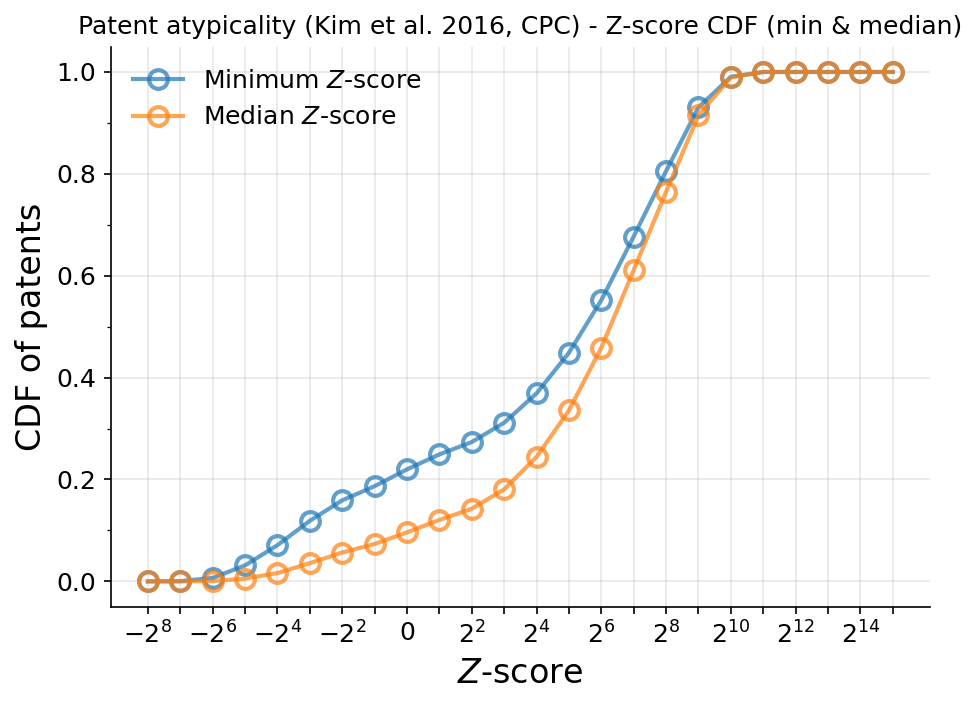

          Z_median        Z_min
count  4160856.000  4160856.000
mean       170.913      139.621
std        230.848      224.168
min       -185.342     -192.618
25%         16.820        2.068
50%         77.542       46.110
75%        240.417      188.947
max       1522.201     1522.201
CPU times: user 2.12 s, sys: 136 ms, total: 2.26 s
Wall time: 2.37 s


In [29]:
%%time
zz = pd.read_parquet(os.path.join(POUT, 'patent_z_score.parquet'), columns=['Z_median', 'Z_min'])
plot_atyp_cdf(zz, 'Z_min', 'Z_median', 'Patent atypicality (Kim et al. 2016, CPC) - Z-score CDF (min & median)', ylabel='CDF of patents', label1=r'Minimum $Z$-score')
print(zz[['Z_median', 'Z_min']].describe().round(3).to_string())

## 19. Atypicality 2x2 - hit-patent probability (Kim et al. 2016 CPC atypicality)

Median conventionality is `Z_median`; tail novelty is a **low** `Z_10pct`. Each axis is split
into high/low at the median of the patent's **own grant-year cohort**, not at the pooled median
over all years: the Z level drifts with year (section 18), so a pooled cut would sort patents
largely by grant year and the 2x2 would compare cohorts rather than patents.

**Hit is ranked inside the 2x2 sample itself.** `C_5` (5-year forward citations, from
`patent_citation`, already merged into `df`) is `percent_rank()`-ed **within CPC section ×
grant year among the patents that have a z-score**; hit = `cpct >= 0.95` (`HIT_PCTL`). This
mirrors section 3 of `paper_validation.ipynb` and Uzzi et al.'s definition — top 5% of the
*analysed* population in its own cohort — so the overall hit rate is 5% by construction and
each quadrant reads as a multiple of that baseline. The corpus-wide `pctl_uniqueC_5` (ranked
over all patents within WIPO sector × grant year) is no longer the hit flag; what it would
have given on this sample is printed once as a diagnostic. Patents without a CPC section or
outside 1976–2024 (`YR_LO`–`YR_HI`) are dropped before ranking.


In [30]:
%%time
from mpl_toolkits.mplot3d import Axes3D  # noqa

def plot_2x2(zmed, znov, hit, title, zlabel='Hit patent probability', year=None, fig_tag='19'):
    # zmed = median conventionality (higher = more conventional); znov = tail novelty score (LOWER = more novel)
    # hit  = 0/1 per patent, already defined by the caller (section 19 re-ranks C_5 within
    #        CPC section x grant year inside the sample, so mean(hit) is ~0.05 by construction)
    # year: if given, each axis is split at the median of the patent's OWN year cohort (grant
    # year here); if None, at the pooled median -- kept only for a caller with a single cohort.
    zmed = np.asarray(zmed, float); znov = np.asarray(znov, float); hit = np.asarray(hit, float)
    m = np.isfinite(zmed) & np.isfinite(znov) & np.isfinite(hit)
    if year is not None:
        year = np.asarray(year, float); m &= np.isfinite(year); year = year[m]
    zmed, znov, hit = zmed[m], znov[m], hit[m]
    if year is None:
        cut_med, cut_nov = np.median(zmed), np.median(znov)
    else:
        _g = pd.DataFrame({'y': year, 'zm': zmed, 'zn': znov}).groupby('y')
        cut_med = _g['zm'].transform('median').to_numpy()
        cut_nov = _g['zn'].transform('median').to_numpy()
    hc = zmed >= cut_med                    # high median conventionality (within year if year given)
    hn = znov <= cut_nov                    # high tail novelty (lower Z = more novel)
    cells = {('LowConv', 'LowNov'): (~hc) & (~hn), ('LowConv', 'HighNov'): (~hc) & hn,
             ('HighConv', 'LowNov'): hc & (~hn), ('HighConv', 'HighNov'): hc & hn}
    P4 = {k: hit[v].mean() for k, v in cells.items()}
    N4 = {k: int(v.sum()) for k, v in cells.items()}
    H4 = {k: int(hit[v].sum()) for k, v in cells.items()}
    overall = hit.mean()
    if year is not None:
        thr = (pd.DataFrame({'y': year.astype(int), 'split_Z_median': cut_med, 'split_Z_10pct': cut_nov})
                 .groupby('y').first())
        thr['n'] = pd.Series(year.astype(int)).value_counts().sort_index()
        thr['hit_rate'] = pd.Series(hit).groupby(year.astype(int)).mean()
        print(f'{len(zmed):,} patents, {int(year.min())}-{int(year.max())}, split at each year\'s own median:')
        display(thr.round(4).T)
    # Per-quadrant table: n, hits, P(hit | quadrant) and its ratio to the overall rate (1.0 = baseline).
    tab = pd.DataFrame({'n': N4, 'hits': H4, 'hit_probability': P4})
    tab.index = pd.MultiIndex.from_tuples(tab.index, names=['convention', 'novelty'])
    tab['ratio_to_overall'] = tab['hit_probability'] / overall
    print(f'overall hit rate {overall:.4f} ({int(hit.sum()):,} / {len(hit):,})')
    display(tab.style.format({'n': '{:,}', 'hits': '{:,}', 'hit_probability': '{:.4%}', 'ratio_to_overall': '{:.2f}x'}))
    print('hit probability per quadrant:')
    for (a, b), p in P4.items():
        print(f'  {a:>8} | {b:<7}  P(hit) = {p:.4%}   n = {N4[(a, b)]:>10,}   hits = {H4[(a, b)]:>8,}   {p / overall:.2f}x overall')
    fig = plt.figure(figsize=(9, 6)); ax = fig.add_subplot(projection='3d')
    xpos = np.array([0, 1, 0, 1]); ypos = np.array([0, 0, 1, 1]); zpos = np.zeros(4)
    dz = [P4[('LowConv', 'LowNov')], P4[('LowConv', 'HighNov')], P4[('HighConv', 'LowNov')], P4[('HighConv', 'HighNov')]]
    ax.bar3d(xpos, ypos, zpos, 0.6, 0.6, dz, color=['red', 'orange', 'green', 'blue'], zsort='average')
    for x0, y0, z0 in zip(xpos, ypos, dz):
        ax.text(x0 + 0.3, y0 + 0.3, z0, f'{z0:.1%}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks([0.3, 1.3]); ax.set_xticklabels(['Low Tail\nNovelty', 'High Tail\nNovelty'], fontsize=9)
    ax.set_yticks([0.3, 1.3]); ax.set_yticklabels(['Low Median\nConvention', 'High Median\nConvention'], fontsize=9)
    ax.set_zlabel(zlabel, fontsize=12); ax.set_title(title, fontsize=10); ax.view_init(20, -45)
    for pane in (ax.xaxis, ax.yaxis, ax.zaxis): pane.pane.fill = False
    V.save(fig_tag, tight=False)
    return tab


CPU times: user 17 μs, sys: 0 ns, total: 17 μs
Wall time: 20.3 μs


z-score patents 4,160,856 -> 3,965,565 with a CPC section and grant year 1976-2024
hit = top 5% by C_5 within CPC section x grant year, ranked among these 3,965,565 patents
[diagnostic] corpus-wide pctl_uniqueC_5 >= 0.95 would flag 0.0546 of this sample as hits
3,965,565 patents, 1976-2024, split at each year's own median:


y,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
split_Z_median,7.8795,9.9974,12.4770,14.0311,14.9238,16.4907,17.3466,18.4759,20.2813,20.7296,...,102.3129,100.1133,103.5872,103.1109,104.3005,113.0548,125.2222,127.5345,129.3636,133.7899
split_Z_10pct,6.3815,8.2998,10.2971,11.4174,12.3398,13.5234,14.0390,14.5169,16.4878,16.7789,...,71.6733,69.5770,67.4350,65.1944,65.1630,69.9498,76.9731,79.9819,80.0734,80.4721
n,24815.0000,22746.0000,23432.0000,17306.0000,22313.0000,24010.0000,21091.0000,20905.0000,23624.0000,25642.0000,...,158115.0000,171264.0000,187990.0000,187459.0000,222236.0000,227904.0000,211744.0000,209067.0000,202166.0000,206708.0000
hit_rate,0.0403,0.0400,0.0453,0.0428,0.0433,0.0436,0.0415,0.0457,0.0442,0.0463,...,0.0478,0.0476,0.0470,0.0467,0.0456,0.0464,0.0455,0.0424,0.0410,0.0344


overall hit rate 0.0455 (180,347 / 3,965,565)


hit probability per quadrant:
   LowConv | LowNov   P(hit) = 3.5335%   n =    180,246   hits =    6,369   0.78x overall
   LowConv | HighNov  P(hit) = 4.4066%   n =  1,800,799   hits =   79,354   0.97x overall
  HighConv | LowNov   P(hit) = 4.6416%   n =  1,801,950   hits =   83,639   1.02x overall
  HighConv | HighNov  P(hit) = 6.0169%   n =    182,570   hits =   10,985   1.32x overall
  [fig] patent_validation_19.jpg + .pdf  (600 dpi)


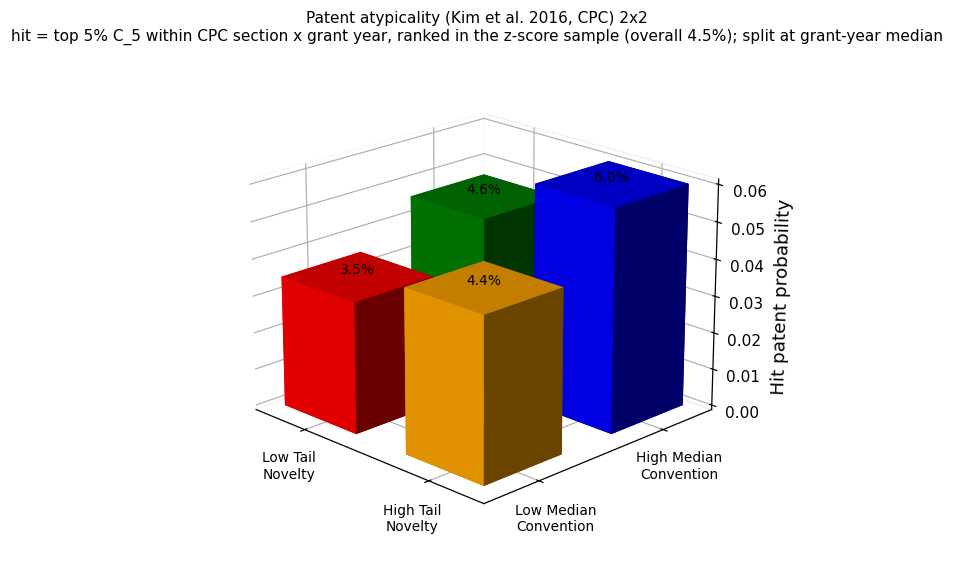

CPU times: user 18.1 s, sys: 1.2 s, total: 19.3 s
Wall time: 19.1 s


In [31]:
%%time
import duckdb
HIT_PCTL = 0.95
# Sample = patents with a z-score. C_5 is already in df (patent_citation merged in the load
# cell, 0 where the citation file had no row). cpc_section comes from the first CPC letter;
# a patent without a CPC has the string 'n' there (str(NaN)[0]) and is dropped, as is anything
# outside the notebook's sane grant-year range.
zc = pd.read_parquet(os.path.join(POUT, 'patent_z_score.parquet'), columns=['patent_id', 'Z_median', 'Z_10pct'])
zc = zc.merge(df[['patent_id', 'grant_year', 'cpc_section', 'C_5', 'pctl_uniqueC_5']], on='patent_id', how='inner')
n0 = len(zc)
zc = zc[zc['cpc_section'].isin(list(CPC_NAMES)) & zc['grant_year'].between(YR_LO, YR_HI)].reset_index(drop=True)
print(f'z-score patents {n0:,} -> {len(zc):,} with a CPC section and grant year {YR_LO}-{YR_HI}')
# HIT IS RE-RANKED INSIDE THE SAMPLE: SQL percent_rank() of C_5 within (CPC section, grant year)
# over these patents only -- the same statement section 3 of paper_validation uses for FoS x year.
# Row order is not preserved through a window query, so the rank comes back keyed by patent_id.
_c = duckdb.connect(); _c.register('zc_t', zc)
_r = _c.execute('''
    SELECT patent_id, percent_rank() OVER (PARTITION BY cpc_section, grant_year ORDER BY C_5) AS cpct
    FROM zc_t''').fetchdf()
_c.close()
assert _r['patent_id'].is_unique, 'patent_id must be unique in the z-score sample'
zc = zc.merge(_r, on='patent_id', how='left')
hitp = (zc['cpct'] >= HIT_PCTL).astype(float).values
old = (zc['pctl_uniqueC_5'] >= HIT_PCTL).mean()
print(f'hit = top {round((1 - HIT_PCTL) * 100)}% by C_5 within CPC section x grant year, ranked among these {len(zc):,} patents')
print(f'[diagnostic] corpus-wide pctl_uniqueC_5 >= {HIT_PCTL} would flag {old:.4f} of this sample as hits')
# grant_year: the split is within each patent's own grant-year cohort (see the section note).
tab19 = plot_2x2(zc['Z_median'].values, zc['Z_10pct'].values, hitp,
                 f'Patent atypicality (Kim et al. 2016, CPC) 2x2\nhit = top 5% C_5 within CPC section x grant year, '
                 f'ranked in the z-score sample (overall {hitp.mean():.1%}); split at grant-year median',
                 year=zc['grant_year'].values)


## 20. Disruption is falling over time (Park, Leahey & Funk 2023, Fig 1 style)

The patent half of the same result: mean CD by **grant year**, indexed, and resolved by CPC
section. §8 of `paper_validation.ipynb` is the paper comparison.

Two separate truncation effects are handled here, and the second one is the reason the
headline number needs a start year attached to it.

**Forward truncation** — CD at window *w* needs citing patents through *y + w*, so each window
is drawn only up to `last grant year − w`. Same cut as the paper side.

**A left-edge artifact.** `g_us_patent_citation` only records citations *made by* patents
granted from 1976 on. `nk` — patents citing the focal patent's references but not the focal
patent — is therefore badly undercounted for the earliest grant years, and CD is pushed toward
+1: the 1976 mean is **+0.985**, which is an artifact of the data window opening, not a
statement about 1976 inventions. It decays over roughly the first decade.

So the fall is reported twice: from 1976 (contaminated, quoted only for completeness) and from
**1985**, once the reference-side citation window has filled in. The 1985-based figure is the
one to quote, and it is the one comparable to the published result.


last grant year in metadata: 2025  (43 year rows, 4,886,395 patents)
patents (contaminated left edge): fall in mean CD from the first year to the last truncation-safe year
  CD_3    1976: +0.9854  ->  2018: +0.0316   -96.8%
  CD_5    1976: +0.9888  ->  2018: +0.0500   -94.9%
  CD_10   1976: +0.9890  ->  2015: +0.0538   -94.6%
  CD_all  1976: +0.9897  ->  2018: +0.0601   -93.9%

patents  <- QUOTE THIS ONE: fall in mean CD from 1985 to the last truncation-safe year
  CD_3    1985: +0.1549  ->  2018: +0.0316   -79.6%
  CD_5    1985: +0.2035  ->  2018: +0.0500   -75.5%
  CD_10   1985: +0.2258  ->  2015: +0.0538   -76.2%
  CD_all  1985: +0.2491  ->  2018: +0.0601   -75.9%
  [fig] patent_validation_20.jpg + .pdf  (600 dpi)


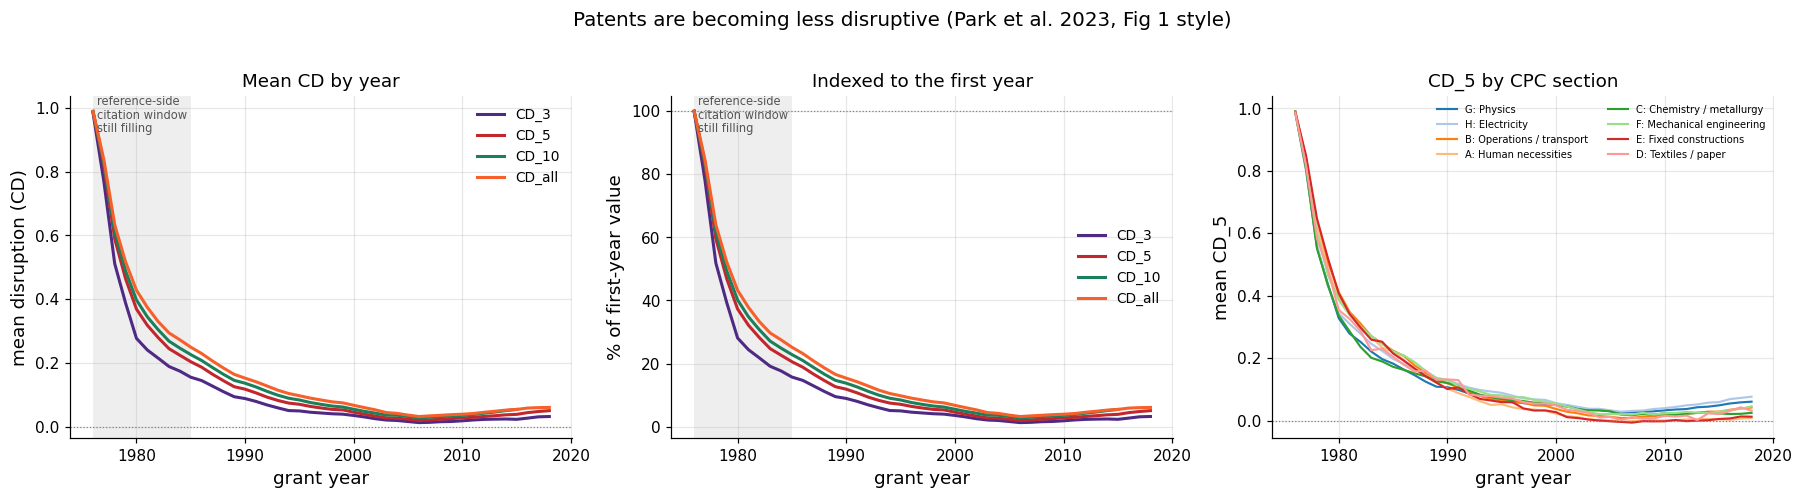

  yr      n     CD_3     CD_5    CD_10   CD_all
1976  42063 0.985440 0.988770 0.988955 0.989668
1977  42112 0.769291 0.818399 0.826833 0.837434
1978  45675 0.511192 0.588940 0.609559 0.633472
1979  35719 0.387530 0.463829 0.488346 0.516604
1980  47292 0.276895 0.368856 0.397417 0.427910
1981  53033 0.240337 0.317893 0.344414 0.374319
1982  48331 0.214688 0.279125 0.303940 0.329524
1983  48415 0.188466 0.244381 0.267960 0.293796
1984  58619 0.173956 0.223790 0.246073 0.272218
1985  63650 0.154857 0.203501 0.225843 0.249123
1986  63568 0.144412 0.186307 0.207352 0.229220
1987  75550 0.127073 0.164259 0.185316 0.205749
1988  71462 0.109588 0.144063 0.164110 0.183897
1989  88000 0.093654 0.125070 0.145085 0.163848
1990  83110 0.087940 0.117323 0.136076 0.151977
1991  89125 0.078890 0.105711 0.124387 0.140736
1992  90393 0.068079 0.092684 0.110803 0.127597
1993  91481 0.058848 0.082109 0.098627 0.114326
1994  95576 0.050273 0.073818 0.089022 0.103887
1995  95516 0.049127 0.069915 0.083463 0

In [32]:
%%time

DEC_COL = {'CD_3': '#4E2A84', 'CD_5': '#c1272d', 'CD_10': '#1b7f5a', 'CD_all': '#F7602A'}

def plot_decline(dec, decf, xlab, group_lab, section, title, shade_before=None):
    """Three panels: mean CD by year, the same indexed to the first year, and by field.

    Each window is drawn only over the years where it is truncation-safe: CD_w at year y needs
    citations through y + w, so a window is cut at (last citable year - w). Without that cut the
    right-hand end of CD_10 slopes down for a reason that has nothing to do with disruption."""
    fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.4), facecolor='white')
    yr = dec['yr'].values

    for w, c in DEC_COL.items():
        if w not in dec: continue
        m = dec[f'safe_{w}'].values if f'safe_{w}' in dec else np.ones(len(dec), bool)
        ax[0].plot(yr[m], dec[w].values[m], color=c, lw=2, label=w)
    ax[0].set_xlabel(xlab, size=12); ax[0].set_ylabel('mean disruption (CD)', size=12)
    ax[0].axhline(0, color='gray', lw=.8, ls=':')
    ax[0].legend(fontsize=9, frameon=False); ax[0].set_title('Mean CD by year', size=12)

    for w, c in DEC_COL.items():
        if w not in dec: continue
        m = dec[f'safe_{w}'].values if f'safe_{w}' in dec else np.ones(len(dec), bool)
        v = dec[w].values[m]
        if len(v) < 2 or not np.isfinite(v[0]) or v[0] == 0: continue
        ax[1].plot(yr[m], v / v[0] * 100, color=c, lw=2, label=w)
    ax[1].axhline(100, color='gray', lw=.8, ls=':')
    ax[1].set_xlabel(xlab, size=12); ax[1].set_ylabel('% of first-year value', size=12)
    ax[1].legend(fontsize=9, frameon=False); ax[1].set_title('Indexed to the first year', size=12)

    if decf is not None and len(decf):
        top = (decf.groupby('grp')['n'].sum().sort_values(ascending=False).head(12).index)
        cmap = plt.get_cmap('tab20')
        for i, g in enumerate(top):
            d = decf[decf.grp == g].sort_values('yr')
            ax[2].plot(d['yr'], d['CD_5'], lw=1.4, color=cmap(i % 20), label=str(g)[:26])
        ax[2].axhline(0, color='gray', lw=.8, ls=':')
        ax[2].set_xlabel(xlab, size=12); ax[2].set_ylabel('mean CD_5', size=12)
        ax[2].legend(fontsize=6.5, ncol=2, frameon=False)
        ax[2].set_title(f'CD_5 by {group_lab}', size=12)
    if shade_before is not None:
        for a in (ax[0], ax[1]):
            a.axvspan(yr.min(), shade_before, color='gray', alpha=.13, lw=0)
            a.annotate('reference-side\ncitation window\nstill filling',
                       xy=(yr.min() + .4, a.get_ylim()[1]), va='top', ha='left',
                       fontsize=7.5, color='#555')
    for a in ax:
        a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
    fig.suptitle(title, size=13, y=1.02)
    V.save(section)

def decline_report(dec, label, since=None):
    """Percent fall from `since` (default: the first year) to the last truncation-safe year."""
    head = f'from {since}' if since else 'from the first year'
    print(f'{label}: fall in mean CD {head} to the last truncation-safe year')
    for w in DEC_COL:
        if w not in dec: continue
        m = dec[f'safe_{w}'].values if f'safe_{w}' in dec else np.ones(len(dec), bool)
        if since is not None:
            m = m & (dec['yr'].values >= since)
        v = dec[w].values[m]; y = dec['yr'].values[m]
        if len(v) < 2 or not np.isfinite(v[0]) or v[0] == 0: continue
        print(f'  {w:7s} {y[0]}: {v[0]:+.4f}  ->  {y[-1]}: {v[-1]:+.4f}   '
              f'{(v[-1]-v[0])/abs(v[0])*100:+.1f}%')

PDISR = os.path.join(POUT, 'patent_disruption.parquet').replace(os.sep, '/')
PMETA = os.path.join(POUT, 'patent_metadata.parquet').replace(os.sep, '/')
YR0, YR1 = 1976, 2018
LAST = int(con.execute(f"SELECT max(grant_year) FROM read_parquet('{PMETA}')").fetchone()[0])
WIN = {'CD_3': 3, 'CD_5': 5, 'CD_10': 10, 'CD_all': 0}
avgs = ', '.join(f'avg(d.{w}) {w}' for w in WIN)
dec = con.execute(f'''SELECT m.grant_year yr, count(*) n, {avgs}
  FROM read_parquet('{PDISR}') d JOIN read_parquet('{PMETA}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.ref_count >= 1 AND m.grant_year BETWEEN {YR0} AND {YR1}
  GROUP BY yr ORDER BY yr''').fetchdf()
for w, k in WIN.items():
    dec[f'safe_{w}'] = dec['yr'] <= (LAST - k)
print(f'last grant year in metadata: {LAST}  ({len(dec)} year rows, {dec.n.sum():,.0f} patents)')

decf = con.execute(f'''SELECT m.grant_year yr, substr(m.cpc_code, 1, 1) grp,
         count(*) n, avg(d.CD_5) CD_5
  FROM read_parquet('{PDISR}') d JOIN read_parquet('{PMETA}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.ref_count >= 1 AND m.grant_year BETWEEN {YR0} AND {YR1}
    AND m.cpc_code IS NOT NULL AND substr(m.cpc_code, 1, 1) BETWEEN 'A' AND 'H'
  GROUP BY yr, grp HAVING count(*) >= 200 ORDER BY grp, yr''').fetchdf()
decf = decf[decf.yr <= LAST - 5]
decf['grp'] = decf['grp'].map(lambda g: CPC_NAMES.get(g, g))

SETTLED = 1985   # g_us_patent_citation opens in 1976; nk is undercounted until it fills in
decline_report(dec, 'patents (contaminated left edge)')
print()
decline_report(dec, 'patents  <- QUOTE THIS ONE', since=SETTLED)
plot_decline(dec, decf, 'grant year', 'CPC section', '20',
             'Patents are becoming less disruptive (Park et al. 2023, Fig 1 style)',
             shade_before=SETTLED)
print(dec.drop(columns=[c for c in dec.columns if c.startswith('safe_')]).to_string(index=False))


---

# EXTENDED CITATION NETWORK — `patent_disruption_app.parquet`

Sections 21-26 repeat the disruption results above on the **extended** citation network:
granted patent->patent citations (`g_us_patent_citation`) **union** application/pre-grant citations
(`g_us_application_citation`, cited pgpub mapped to a granted `patent_id` through
`pg_granted_pgpubs_crosswalk`), with directed pairs de-duplicated after the union. Built by
`PatentView/notebook/patent_disruption_app_add.ipynb`; identical schema to `patent_disruption.parquet`.

Everything before this point used `patent_disruption.parquet` (granted only), so each section here is
labelled **granted** vs **extended** and the granted series is redrawn alongside rather than referenced.

Application citations only ever *add* edges, so a patent's citer count and its `nk` can only rise.
Which way $\mathrm{CD}=\frac{n_i-n_j}{n_i+n_j+n_k}$ moves is the question these sections answer.
Applications were first published in **2001** (AIPA), so for old patents the extended network *is* the
granted network — and that gives every trend plot below a built-in correctness check. The exact cutoff
is window-dependent: a patent granted in year *y* draws its window-*w* citers from *[y, y+w]*, and the
citing documents that carry application citations are published 2001 or later, so the last grant year
that cannot be touched at window *w* is **2000 − w** (1995 for CD_5, not 2000). Granted and extended
must agree to machine precision at or below that year; a gap there would be a bug rather than a finding.

A companion notebook, `PatentView/notebook/patent_disruption_app_compare.ipynb`, does the paired
per-patent comparison in more depth; these sections cover what belongs in *this* notebook's
face-validity sweep.

## 21. Extended network — coverage and CD distribution

net,granted,extended
n,8.062166e+06,8.460168e+06
def_3,5.606555e+06,6.897644e+06
def_5,5.768230e+06,7.011553e+06
def_10,5.899905e+06,7.114532e+06
def_all,5.973424e+06,7.186006e+06
mean_3,9.328188e-02,6.175203e-02
mean_5,1.239411e-01,8.166519e-02
mean_10,1.516943e-01,1.020366e-01
mean_all,1.689968e-01,1.172768e-01


rows: granted 8,062,166 | extended 8,460,168
extended-only patents (reachable only via an application citation): 398,002
granted-only patents: 0   <- must be 0; the extended network is a node superset
  [fig] patent_validation_21.jpg + .pdf  (600 dpi)


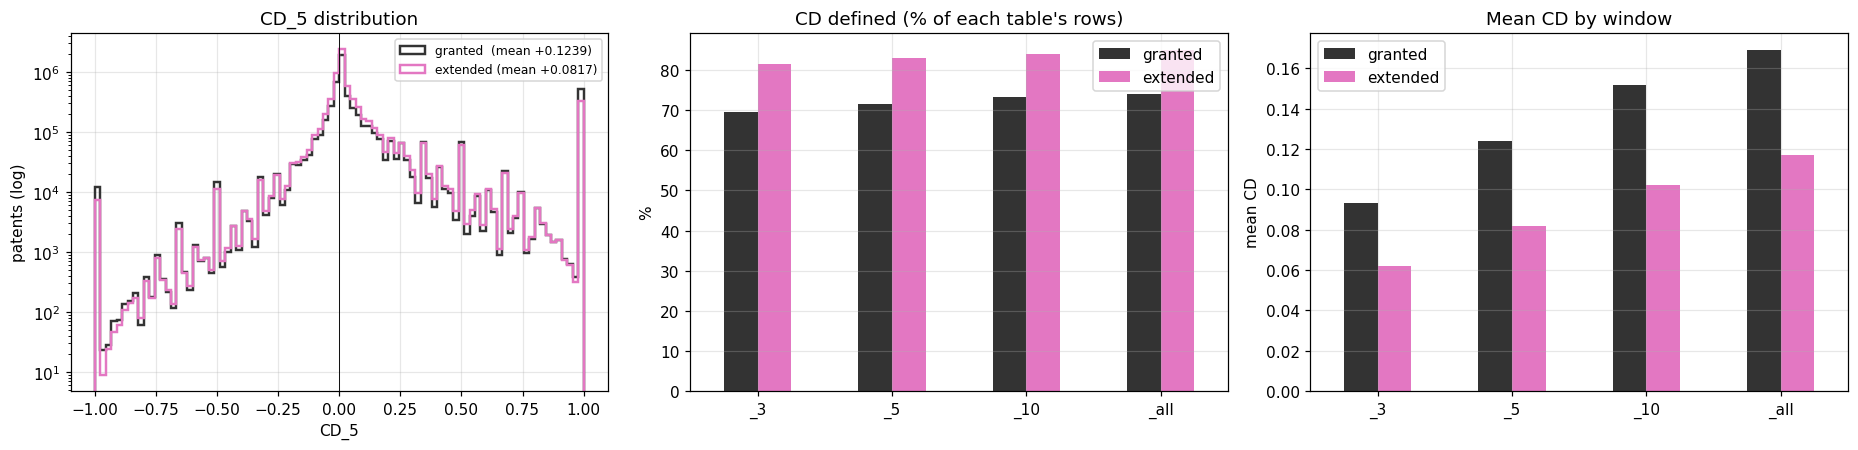

,granted,extended,delta
_3,0.0933,0.0618,-0.0315
_5,0.1239,0.0817,-0.0423
_10,0.1517,0.1020,-0.0497
_all,0.1690,0.1173,-0.0517


CPU times: user 5.59 s, sys: 360 ms, total: 5.95 s
Wall time: 4.79 s


In [33]:
%%time
DAPP  = os.path.join(POUT, 'patent_disruption_app.parquet').replace(os.sep, '/')
DGRT  = os.path.join(POUT, 'patent_disruption.parquet').replace(os.sep, '/')
PMETA_ = os.path.join(POUT, 'patent_metadata.parquet').replace(os.sep, '/')
WS   = ['_3', '_5', '_10', '_all']
C_G, C_E, C_DLT = '#333333', '#e377c2', '#8172b3'      # granted / extended / delta

cov_e = con.execute(f'''
SELECT 'granted' AS net, count(*) n, {', '.join(f"count(CD{s}) def{s}" for s in WS)},
       {', '.join(f"avg(CD{s}) mean{s}" for s in WS)} FROM read_parquet('{DGRT}')
UNION ALL
SELECT 'extended', count(*), {', '.join(f"count(CD{s})" for s in WS)},
       {', '.join(f"avg(CD{s})" for s in WS)} FROM read_parquet('{DAPP}')
''').fetchdf().set_index('net')
display(cov_e.T)

# node counts: the extended network should be a strict superset (every granted node plus the
# patents that are only reachable through an application citation)
xtra = con.execute(f'''SELECT
  (SELECT count(*) FROM read_parquet('{DGRT}')) g,
  (SELECT count(*) FROM read_parquet('{DAPP}')) e,
  (SELECT count(*) FROM read_parquet('{DAPP}') a
     WHERE NOT EXISTS (SELECT 1 FROM read_parquet('{DGRT}') d WHERE d.patent_id = a.patent_id)) e_only,
  (SELECT count(*) FROM read_parquet('{DGRT}') d
     WHERE NOT EXISTS (SELECT 1 FROM read_parquet('{DAPP}') a WHERE a.patent_id = d.patent_id)) g_only
''').fetchdf().iloc[0]
print(f"rows: granted {xtra.g:,.0f} | extended {xtra.e:,.0f}")
print(f"extended-only patents (reachable only via an application citation): {xtra.e_only:,.0f}")
print(f"granted-only patents: {xtra.g_only:,.0f}   <- must be 0; the extended network is a node superset")

cd_g = con.execute(f"SELECT CD_5 FROM read_parquet('{DGRT}') WHERE CD_5 IS NOT NULL").fetchnumpy()['CD_5']
cd_e = con.execute(f"SELECT CD_5 FROM read_parquet('{DAPP}') WHERE CD_5 IS NOT NULL").fetchnumpy()['CD_5']
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].hist(cd_g, bins=90, histtype='step', color=C_G, lw=1.6, label=f'granted  (mean {cd_g.mean():+.4f})')
ax[0].hist(cd_e, bins=90, histtype='step', color=C_E, lw=1.6, label=f'extended (mean {cd_e.mean():+.4f})')
ax[0].axvline(0, color='k', lw=0.6); ax[0].set_yscale('log')
ax[0].set_title('CD_5 distribution'); ax[0].set_xlabel('CD_5'); ax[0].set_ylabel('patents (log)'); ax[0].legend(fontsize=8)
defined = pd.DataFrame({'granted':  [100*cov_e.loc['granted', f'def{s}']/cov_e.loc['granted', 'n'] for s in WS],
                        'extended': [100*cov_e.loc['extended', f'def{s}']/cov_e.loc['extended', 'n'] for s in WS]},
                       index=WS)
defined.plot.bar(ax=ax[1], color=[C_G, C_E])
ax[1].set_title('CD defined (% of each table\'s rows)'); ax[1].set_ylabel('%'); ax[1].tick_params(axis='x', rotation=0)
meanw = pd.DataFrame({'granted':  [cov_e.loc['granted', f'mean{s}'] for s in WS],
                      'extended': [cov_e.loc['extended', f'mean{s}'] for s in WS]}, index=WS)
meanw.plot.bar(ax=ax[2], color=[C_G, C_E])
ax[2].axhline(0, color='k', lw=0.6); ax[2].set_title('Mean CD by window'); ax[2].set_ylabel('mean CD')
ax[2].tick_params(axis='x', rotation=0)
V.save('21')
display(meanw.assign(delta=meanw['extended'] - meanw['granted']).round(4))
del cd_g, cd_e

### 21b. Pipeline consistency — de-duplication of directed citation pairs

One difference between the two builds is not about the network at all, and it has to be measured before
any granted-vs-extended gap can be read as an effect of application citations.

`patent_disruption_app_add.ipynb` de-duplicates directed `(citing, cited)` pairs after unioning the two
citation sources — it has to, because a patent routinely cites the same target both at application and
at grant stage. `patent_disruption.ipynb` does no such de-duplication, and `g_us_patent_citation` does
contain a small number of repeated rows, so its `ni`/`nj` are very slightly inflated.

The signature is unambiguous: adding application citations can only *add* edges, so any patent whose
citer count is **lower** in the extended table has been touched by de-duplication, not by the extended
network. The cell below counts them.

In [34]:
%%time
dd_ = con.execute(f'''SELECT count(*) n_paired,
  sum(CASE WHEN (a.ni_5+a.nj_5) < (g.ni_5+g.nj_5) THEN 1 ELSE 0 END) fewer,
  sum(CASE WHEN (a.ni_5+a.nj_5) < (g.ni_5+g.nj_5) THEN (g.ni_5+g.nj_5)-(a.ni_5+a.nj_5) ELSE 0 END) lost,
  sum(g.ni_5+g.nj_5) tot_g
  FROM read_parquet('{DGRT}') g JOIN read_parquet('{DAPP}') a USING (patent_id)
  WHERE g.CD_5 IS NOT NULL AND a.CD_5 IS NOT NULL''').fetchdf().iloc[0]
print(f'paired patents (CD_5 defined in both): {dd_.n_paired:,.0f}')
print(f'patents with FEWER citers in the extended table: {dd_.fewer:,.0f} '
      f'({100*dd_.fewer/dd_.n_paired:.3f}%)  <- de-duplication, not the extended network')
print(f'duplicate citer-edges removed: {dd_.lost:,.0f} of {dd_.tot_g:,.0f} granted citer-edges '
      f'({100*dd_.lost/dd_.tot_g:.4f}%)')

# The clean correctness check. Restrict to grant years that no application citation can reach at
# window 5 (see 22) AND to patents de-duplication did not touch: on those, the two pipelines are
# computing the same quantity on the same graph, so CD_5 must agree bit for bit.
chk = con.execute(f'''SELECT count(*) n, sum(CASE WHEN g.CD_5 <> a.CD_5 THEN 1 ELSE 0 END) differ,
    max(abs(g.CD_5 - a.CD_5)) maxdiff
  FROM read_parquet('{DGRT}') g JOIN read_parquet('{DAPP}') a USING (patent_id)
  JOIN read_parquet('{PMETA_}') m USING (patent_id)
  WHERE m.grant_year <= 1995 AND g.CD_5 IS NOT NULL AND a.CD_5 IS NOT NULL
    AND (a.ni_5+a.nj_5) = (g.ni_5+g.nj_5)''').fetchdf().iloc[0]
print(f'\ngrant year <= 1995, de-duplication untouched: n = {chk.n:,.0f}, '
      f'CD_5 differs for {chk.differ:,.0f}, max |diff| = {chk.maxdiff}')
print('  -> the two pipelines agree exactly where they must; the residual in 22 is de-duplication.')

paired patents (CD_5 defined in both): 5,768,230
patents with FEWER citers in the extended table: 0 (0.000%)  <- de-duplication, not the extended network
duplicate citer-edges removed: 0 of 25,824,114 granted citer-edges (0.0000%)

grant year <= 1995, de-duplication untouched: n = 1,348,142, CD_5 differs for 0, max |diff| = 0.0
  -> the two pipelines agree exactly where they must; the residual in 22 is de-duplication.
CPU times: user 3.63 s, sys: 362 ms, total: 4 s
Wall time: 1.96 s


## 22. CD, n_i/n_j/n_k and F/E/G by grant year — granted vs extended

The trend version of §6 and §7. The overlap at early grant years is the correctness check — exact
through **1995** for CD_5 (see the cutoff rule above) and near-exact through 2000, since a patent granted
in 1996-2000 can still pick up citers from applications published in 2001 or later. The gap that opens
after that is the measurement effect of leaving application citations out.

The pre-1996 residual printed below is **not** zero, and §21b is why: it is the de-duplication
difference between the two builds, not application citations. Removing the 0.6% of patents that
de-duplication touches drives it to exactly zero.

  [fig] patent_validation_22.jpg + .pdf  (600 dpi)


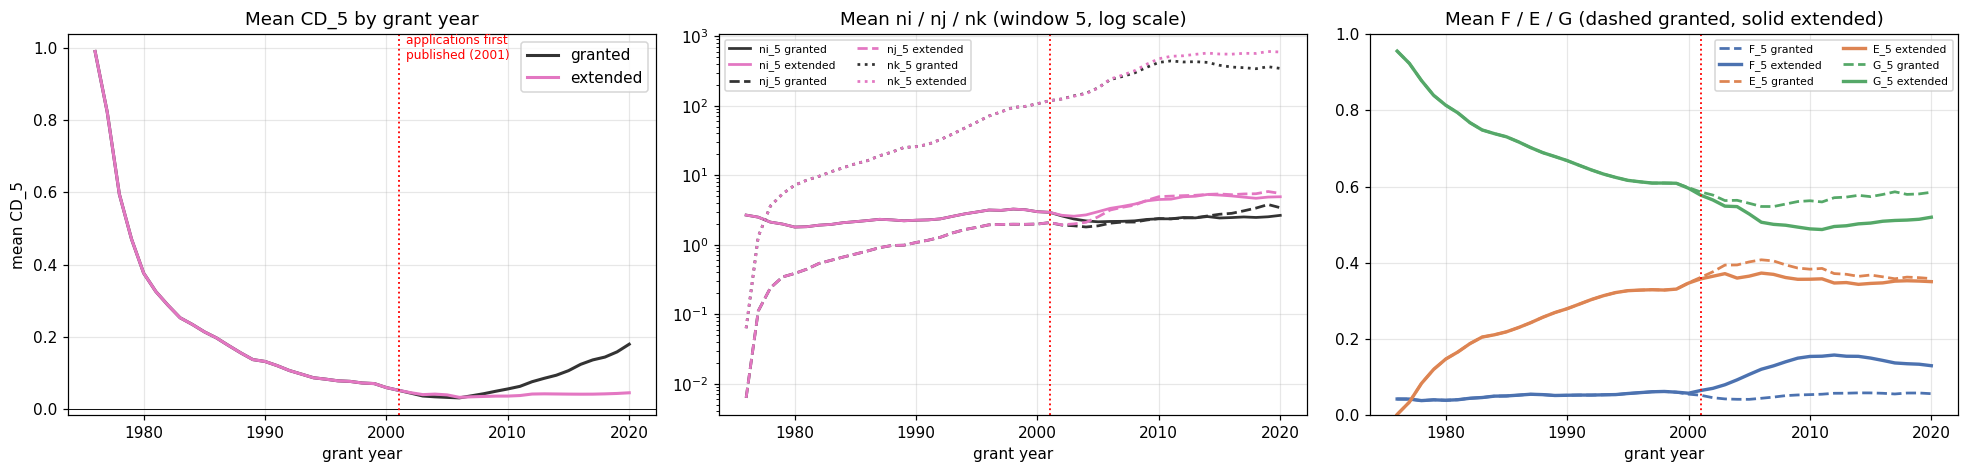

max |extended - granted| mean CD_5, grant years <= 1995: 0.00000000
   no application citation can reach these windows -- this residual is the de-duplication
   difference of section 21b, which vanishes once those patents are excluded.
max |extended - granted| mean CD_5, grant years 1996-2000: 0.00000043
   tiny but genuinely nonzero: these windows do reach into 2001+.


,CD_5 granted,CD_5 extended,delta,nk_5 granted,nk_5 extended
yr,,,,,
1990,0.1321,0.1321,0.0000,25.7413,25.7413
1995,0.0831,0.0831,0.0000,57.9688,57.9688
2000,0.0599,0.0599,-0.0000,106.7372,106.7360
2001,0.0523,0.0523,0.0000,118.2630,118.2496
2005,0.0329,0.0397,0.0068,181.2122,180.1488
2010,0.0561,0.0364,-0.0197,420.2220,474.5011
2015,0.1067,0.0418,-0.0648,381.8601,554.7395
2020,0.1798,0.0455,-0.1343,344.2796,592.9583


CPU times: user 5.09 s, sys: 179 ms, total: 5.27 s
Wall time: 3.55 s


In [35]:
%%time
MET_Y = ['CD_5', 'ni_5', 'nj_5', 'nk_5', 'F_5', 'E_5', 'G_5']
avg_y = ', '.join(f'avg(d.{m}) {m}' for m in MET_Y)

def by_year(src):
    return con.execute(f'''SELECT m.grant_year yr, count(*) n, {avg_y}
      FROM read_parquet('{src}') d JOIN read_parquet('{PMETA_}') m USING (patent_id)
      WHERE d.CD_5 IS NOT NULL AND m.grant_year BETWEEN {YR_LO} AND 2020
      GROUP BY yr ORDER BY yr''').fetchdf().set_index('yr')

yg, ye = by_year(DGRT), by_year(DAPP)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.4))
ax[0].plot(yg.index, yg['CD_5'], color=C_G, lw=2, label='granted')
ax[0].plot(ye.index, ye['CD_5'], color=C_E, lw=2, label='extended')
ax[0].axhline(0, color='k', lw=0.6); ax[0].axvline(2001, color='r', ls=':', lw=1.2)
ax[0].annotate('applications first\npublished (2001)', xy=(2001.6, ax[0].get_ylim()[1]),
               va='top', fontsize=8, color='r')
ax[0].set_title('Mean CD_5 by grant year'); ax[0].set_xlabel('grant year'); ax[0].set_ylabel('mean CD_5')
ax[0].legend()
for nm, ls in zip(['ni_5', 'nj_5', 'nk_5'], ['-', '--', ':']):
    ax[1].plot(yg.index, yg[nm], color=C_G, lw=1.8, ls=ls, label=f'{nm} granted')
    ax[1].plot(ye.index, ye[nm], color=C_E, lw=1.8, ls=ls, label=f'{nm} extended')
ax[1].axvline(2001, color='r', ls=':', lw=1.2); ax[1].set_yscale('log')
ax[1].set_title('Mean ni / nj / nk (window 5, log scale)'); ax[1].set_xlabel('grant year')
ax[1].legend(fontsize=7, ncol=2)
for nm, c in zip(['F_5', 'E_5', 'G_5'], ['#4c72b0', '#dd8452', '#55a868']):
    ax[2].plot(yg.index, yg[nm], color=c, lw=1.8, ls='--', label=f'{nm} granted')
    ax[2].plot(ye.index, ye[nm], color=c, lw=2.2, label=f'{nm} extended')
ax[2].axvline(2001, color='r', ls=':', lw=1.2); ax[2].set_ylim(0, 1)
ax[2].set_title('Mean F / E / G (dashed granted, solid extended)'); ax[2].set_xlabel('grant year')
ax[2].legend(fontsize=7, ncol=2)
V.save('22')

# A grant year y is untouchable at window w only if y + w < 2001, because the citing documents
# that carry application citations are published from 2001 on. For CD_5 that is y <= 1995.
CLEAN_5 = 2000 - 5
clean = [y for y in yg.index if y <= CLEAN_5]
edge  = [y for y in yg.index if CLEAN_5 < y <= 2000]
gap_clean = float((ye.loc[clean, 'CD_5'] - yg.loc[clean, 'CD_5']).abs().max())
gap_edge  = float((ye.loc[edge, 'CD_5'] - yg.loc[edge, 'CD_5']).abs().max())
print(f'max |extended - granted| mean CD_5, grant years <= {CLEAN_5}: {gap_clean:.8f}')
print('   no application citation can reach these windows -- this residual is the de-duplication')
print('   difference of section 21b, which vanishes once those patents are excluded.')
print(f'max |extended - granted| mean CD_5, grant years {CLEAN_5+1}-2000: {gap_edge:.8f}')
print('   tiny but genuinely nonzero: these windows do reach into 2001+.')
show_y = [y for y in [1990, 1995, 2000, 2001, 2005, 2010, 2015, 2020] if y in yg.index]
display(pd.DataFrame({'CD_5 granted': yg.loc[show_y, 'CD_5'], 'CD_5 extended': ye.loc[show_y, 'CD_5'],
                      'delta': ye.loc[show_y, 'CD_5'] - yg.loc[show_y, 'CD_5'],
                      'nk_5 granted': yg.loc[show_y, 'nk_5'], 'nk_5 extended': ye.loc[show_y, 'nk_5']}).round(4))

## 23. Extended CD by CPC section, and the per-patent shift

§10 by section, plus the paired per-patent comparison: for each patent present in both tables, how far
does its CD_5 move? Sections differ in how much of their citation traffic is pre-grant, so the shift
should not be uniform.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] patent_validation_23.jpg + .pdf  (600 dpi)


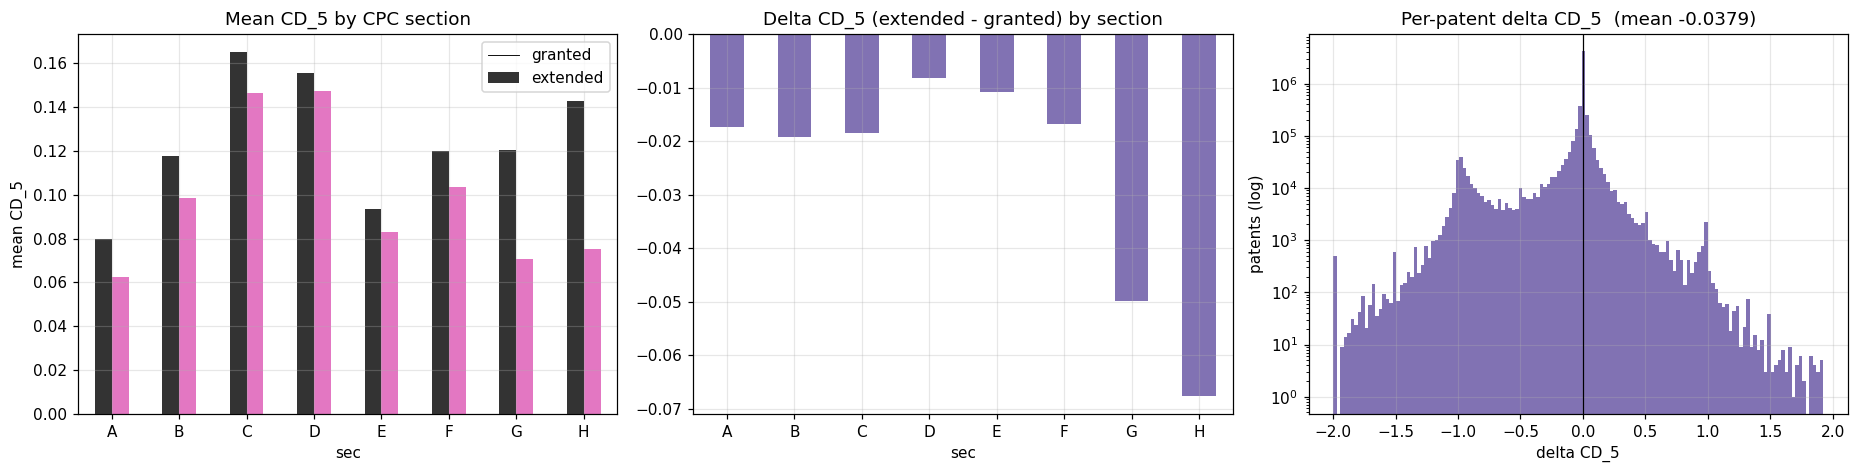

,n,CD_granted,CD_extended,delta,section_name
sec,,,,,
A,775197,0.0798,0.0624,-0.0174,A: Human necessities
B,854031,0.1176,0.0984,-0.0191,B: Operations / transport
C,571475,0.1650,0.1466,-0.0184,C: Chemistry / metallurgy
D,56150,0.1555,0.1473,-0.0082,D: Textiles / paper
E,170977,0.0937,0.0829,-0.0108,E: Fixed constructions
F,453567,0.1201,0.1033,-0.0168,F: Mechanical engineering
G,1501743,0.1206,0.0708,-0.0498,G: Physics
H,1384683,0.1430,0.0754,-0.0675,H: Electricity


patents with CD_5 defined in both tables: 5,768,230
more consolidating (CD falls): 26.5%   more disruptive (CD rises): 22.0%   unchanged: 51.5%
Pearson CD_5 granted vs extended: 0.7831
CPU times: user 7 s, sys: 478 ms, total: 7.48 s
Wall time: 5.56 s


In [36]:
%%time
sec_e = con.execute(f'''SELECT substr(m.cpc_code,1,1) sec, count(*) n,
         avg(g.CD_5) CD_granted, avg(a.CD_5) CD_extended
  FROM read_parquet('{DGRT}') g
  JOIN read_parquet('{DAPP}') a USING (patent_id)
  JOIN read_parquet('{PMETA_}') m USING (patent_id)
  WHERE g.CD_5 IS NOT NULL AND a.CD_5 IS NOT NULL AND m.cpc_code IS NOT NULL
    AND substr(m.cpc_code,1,1) BETWEEN 'A' AND 'Y'
  GROUP BY sec HAVING count(*) >= 500 ORDER BY sec''').fetchdf().set_index('sec')
sec_e['delta'] = sec_e['CD_extended'] - sec_e['CD_granted']

pair = con.execute(f'''SELECT g.CD_5 cd_g, a.CD_5 cd_e
  FROM read_parquet('{DGRT}') g JOIN read_parquet('{DAPP}') a USING (patent_id)
  WHERE g.CD_5 IS NOT NULL AND a.CD_5 IS NOT NULL''').fetchnumpy()
dcd = pair['cd_e'] - pair['cd_g']

fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
sec_e[['CD_granted', 'CD_extended']].plot.bar(ax=ax[0], color=[C_G, C_E])
ax[0].axhline(0, color='k', lw=0.6); ax[0].set_title('Mean CD_5 by CPC section')
ax[0].set_ylabel('mean CD_5'); ax[0].legend(['granted', 'extended']); ax[0].tick_params(axis='x', rotation=0)
sec_e['delta'].plot.bar(ax=ax[1], color=C_DLT)
ax[1].axhline(0, color='k', lw=0.6); ax[1].set_title('Delta CD_5 (extended - granted) by section')
ax[1].tick_params(axis='x', rotation=0)
ax[2].hist(dcd, bins=140, color=C_DLT); ax[2].axvline(0, color='k', lw=0.8); ax[2].set_yscale('log')
ax[2].set_title(f'Per-patent delta CD_5  (mean {dcd.mean():+.4f})')
ax[2].set_xlabel('delta CD_5'); ax[2].set_ylabel('patents (log)')
V.save('23')

display(sec_e.assign(section_name=[CPC_NAMES.get(s, s) for s in sec_e.index]).round(4))
print(f'patents with CD_5 defined in both tables: {len(dcd):,}')
print(f'more consolidating (CD falls): {100*(dcd<0).mean():.1f}%   '
      f'more disruptive (CD rises): {100*(dcd>0).mean():.1f}%   unchanged: {100*(dcd==0).mean():.1f}%')
print(f'Pearson CD_5 granted vs extended: {np.corrcoef(pair["cd_g"], pair["cd_e"])[0,1]:.4f}')
del pair, dcd

## 24. Does the disruption decline survive the extended network? (§20 re-run)

The result in §20 — mean CD falling ~76% since 1985 — is computed on granted citations only. Pre-grant
citations arrive *earlier* than grant citations and grow as a share of all citation traffic through the
2000s, which is exactly the period the decline is measured over. So the decline has to be re-derived on
the extended network before it can be quoted: if it were an artifact of the missing pre-grant edges it
would flatten here.

Same construction as §20 — `ref_count >= 1`, each window cut at its last truncation-safe grant year,
and the 1976-1984 left edge shaded because `g_us_patent_citation` only records citations made by
patents granted from 1976 on, which undercounts `nk` and pushes early CD toward +1.

patents, EXTENDED network (contaminated left edge): fall in mean CD from the first year to the last truncation-safe year
  CD_3    1976: +0.9854  ->  2018: +0.0165   -98.3%
  CD_5    1976: +0.9888  ->  2018: +0.0224   -97.7%
  CD_10   1976: +0.9890  ->  2015: +0.0308   -96.9%
  CD_all  1976: +0.9897  ->  2018: +0.0262   -97.3%

patents, EXTENDED network  <- compare with the granted figure in section 20: fall in mean CD from 1985 to the last truncation-safe year
  CD_3    1985: +0.1549  ->  2018: +0.0165   -89.4%
  CD_5    1985: +0.2035  ->  2018: +0.0224   -89.0%
  CD_10   1985: +0.2258  ->  2015: +0.0308   -86.4%
  CD_all  1985: +0.2491  ->  2018: +0.0262   -89.5%
  [fig] patent_validation_24a.jpg + .pdf  (600 dpi)


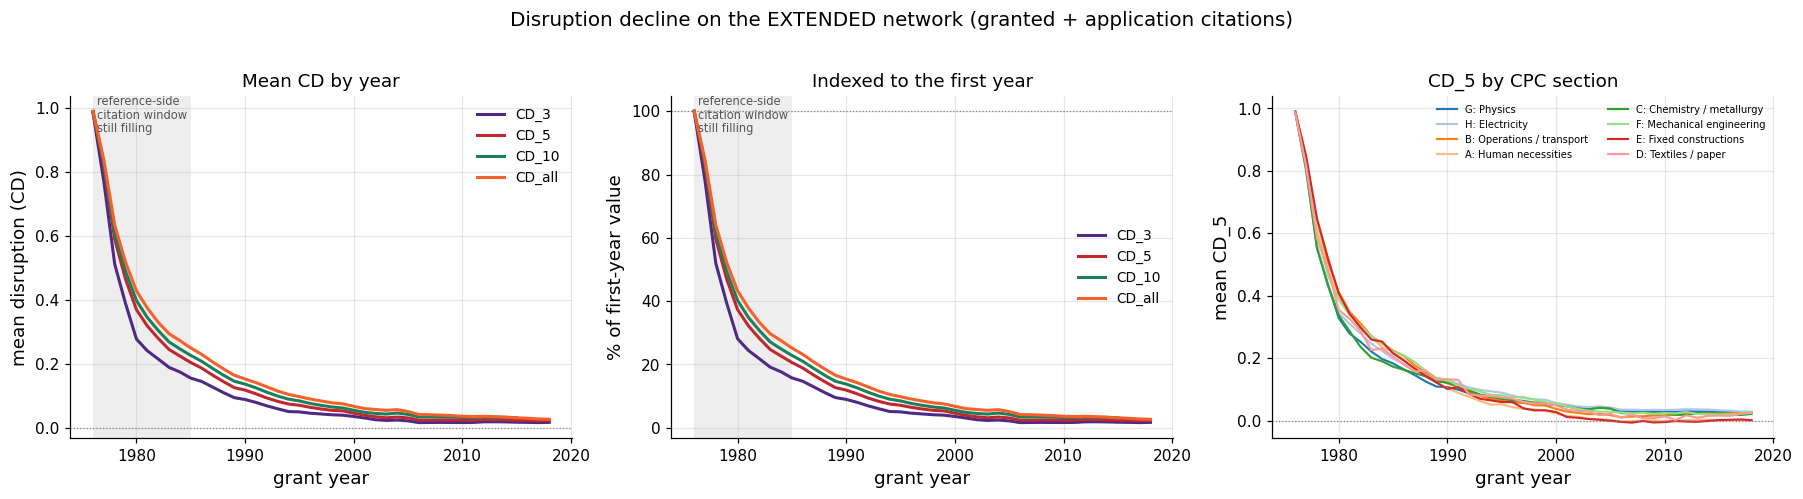

CPU times: user 4.9 s, sys: 360 ms, total: 5.26 s
Wall time: 3.1 s


In [37]:
%%time
dec_e = con.execute(f'''SELECT m.grant_year yr, count(*) n, {', '.join(f'avg(d.{w}) {w}' for w in WIN)}
  FROM read_parquet('{DAPP}') d JOIN read_parquet('{PMETA_}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.ref_count >= 1 AND m.grant_year BETWEEN 1976 AND 2018
  GROUP BY yr ORDER BY yr''').fetchdf()
for w, k in WIN.items():
    dec_e[f'safe_{w}'] = dec_e['yr'] <= (LAST - k)

decf_e = con.execute(f'''SELECT m.grant_year yr, substr(m.cpc_code, 1, 1) grp, count(*) n, avg(d.CD_5) CD_5
  FROM read_parquet('{DAPP}') d JOIN read_parquet('{PMETA_}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.ref_count >= 1 AND m.grant_year BETWEEN 1976 AND 2018
    AND m.cpc_code IS NOT NULL AND substr(m.cpc_code, 1, 1) BETWEEN 'A' AND 'H'
  GROUP BY yr, grp HAVING count(*) >= 200 ORDER BY grp, yr''').fetchdf()
decf_e = decf_e[decf_e.yr <= LAST - 5]
decf_e['grp'] = decf_e['grp'].map(lambda g: CPC_NAMES.get(g, g))

decline_report(dec_e, 'patents, EXTENDED network (contaminated left edge)')
print()
decline_report(dec_e, 'patents, EXTENDED network  <- compare with the granted figure in section 20',
               since=SETTLED)
plot_decline(dec_e, decf_e, 'grant year', 'CPC section', '24a',
             'Disruption decline on the EXTENDED network (granted + application citations)',
             shade_before=SETTLED)

  [fig] patent_validation_24b.jpg + .pdf  (600 dpi)


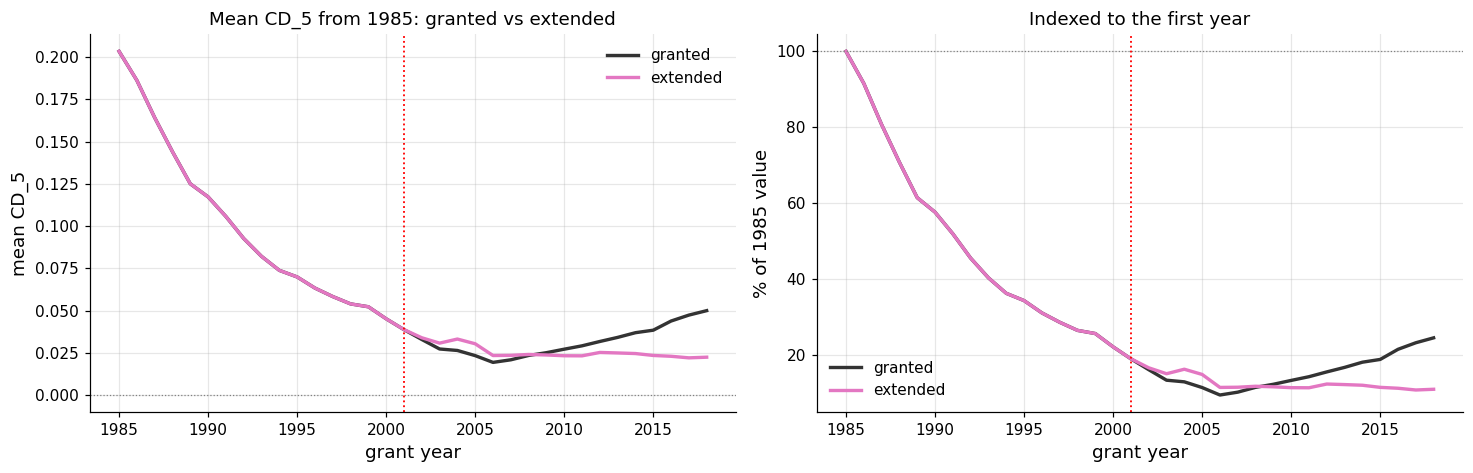

first             last         pct_change         
network extended granted extended granted   extended  granted
window                                                       
CD_3      0.1549  0.1549   0.0165  0.0316   -89.3768 -79.5966
CD_5      0.2035  0.2035   0.0224  0.0500   -88.9961 -75.4517
CD_10     0.2258  0.2258   0.0308  0.0538   -86.3595 -76.1693
CD_all    0.2491  0.2491   0.0262  0.0601   -89.4698 -75.8633

,granted,extended,delta
yr,,,
1985,0.2035,0.2035,0.0000
1990,0.1173,0.1173,0.0000
1995,0.0699,0.0699,0.0000
2000,0.0451,0.0451,-0.0000
2001,0.0387,0.0387,0.0000
2005,0.0233,0.0303,0.0070
2010,0.0271,0.0232,-0.0039
2015,0.0384,0.0234,-0.0150
2018,0.0500,0.0224,-0.0276


CPU times: user 806 ms, sys: 32.4 ms, total: 838 ms
Wall time: 846 ms


In [38]:
%%time
# The two networks side by side, on the window that carries the headline number.
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.4), facecolor='white')
for d_, lab, c in [(dec, 'granted', C_G), (dec_e, 'extended', C_E)]:
    m = d_['safe_CD_5'].values & (d_['yr'].values >= SETTLED)
    ax[0].plot(d_['yr'].values[m], d_['CD_5'].values[m], color=c, lw=2.2, label=lab)
    v = d_['CD_5'].values[m]
    ax[1].plot(d_['yr'].values[m], v / v[0] * 100, color=c, lw=2.2, label=lab)
ax[0].axhline(0, color='gray', lw=.8, ls=':'); ax[0].axvline(2001, color='r', ls=':', lw=1.2)
ax[0].set_xlabel('grant year', size=12); ax[0].set_ylabel('mean CD_5', size=12)
ax[0].set_title(f'Mean CD_5 from {SETTLED}: granted vs extended', size=12); ax[0].legend(frameon=False)
ax[1].axhline(100, color='gray', lw=.8, ls=':'); ax[1].axvline(2001, color='r', ls=':', lw=1.2)
ax[1].set_xlabel('grant year', size=12); ax[1].set_ylabel(f'% of {SETTLED} value', size=12)
ax[1].set_title('Indexed to the first year', size=12); ax[1].legend(frameon=False)
for a in ax:
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
V.save('24b')

cmp_dec = pd.DataFrame({'granted': dec.set_index('yr')['CD_5'], 'extended': dec_e.set_index('yr')['CD_5']})
cmp_dec['delta'] = cmp_dec['extended'] - cmp_dec['granted']
rows = []
for lab, d_ in [('granted', dec), ('extended', dec_e)]:
    for w in WIN:
        m = d_[f'safe_{w}'].values & (d_['yr'].values >= SETTLED)
        v = d_[w].values[m]; y = d_['yr'].values[m]
        rows.append({'network': lab, 'window': w, 'first_yr': y[0], 'first': v[0],
                     'last_yr': y[-1], 'last': v[-1], 'pct_change': (v[-1]-v[0])/abs(v[0])*100})
display(pd.DataFrame(rows).pivot(index='window', columns='network',
                                 values=['first', 'last', 'pct_change']).reindex(list(WIN)).round(4))
display(cmp_dec.loc[[y for y in [1985, 1990, 1995, 2000, 2001, 2005, 2010, 2015, 2018]
                     if y in cmp_dec.index]].round(4))

## 25. Yearly-trend convexity on the extended network (§16 re-run)

The §16 test — min-max scale each metric's yearly trend and measure its convexity index (`<0.5` convex
= accelerating / late upturn, `>0.5` concave) — recomputed from `patent_disruption_app.parquet`, using
the same `trend_cvx` helper and the same 1980-2015 window.

  [fig] patent_validation_25a.jpg + .pdf  (600 dpi)


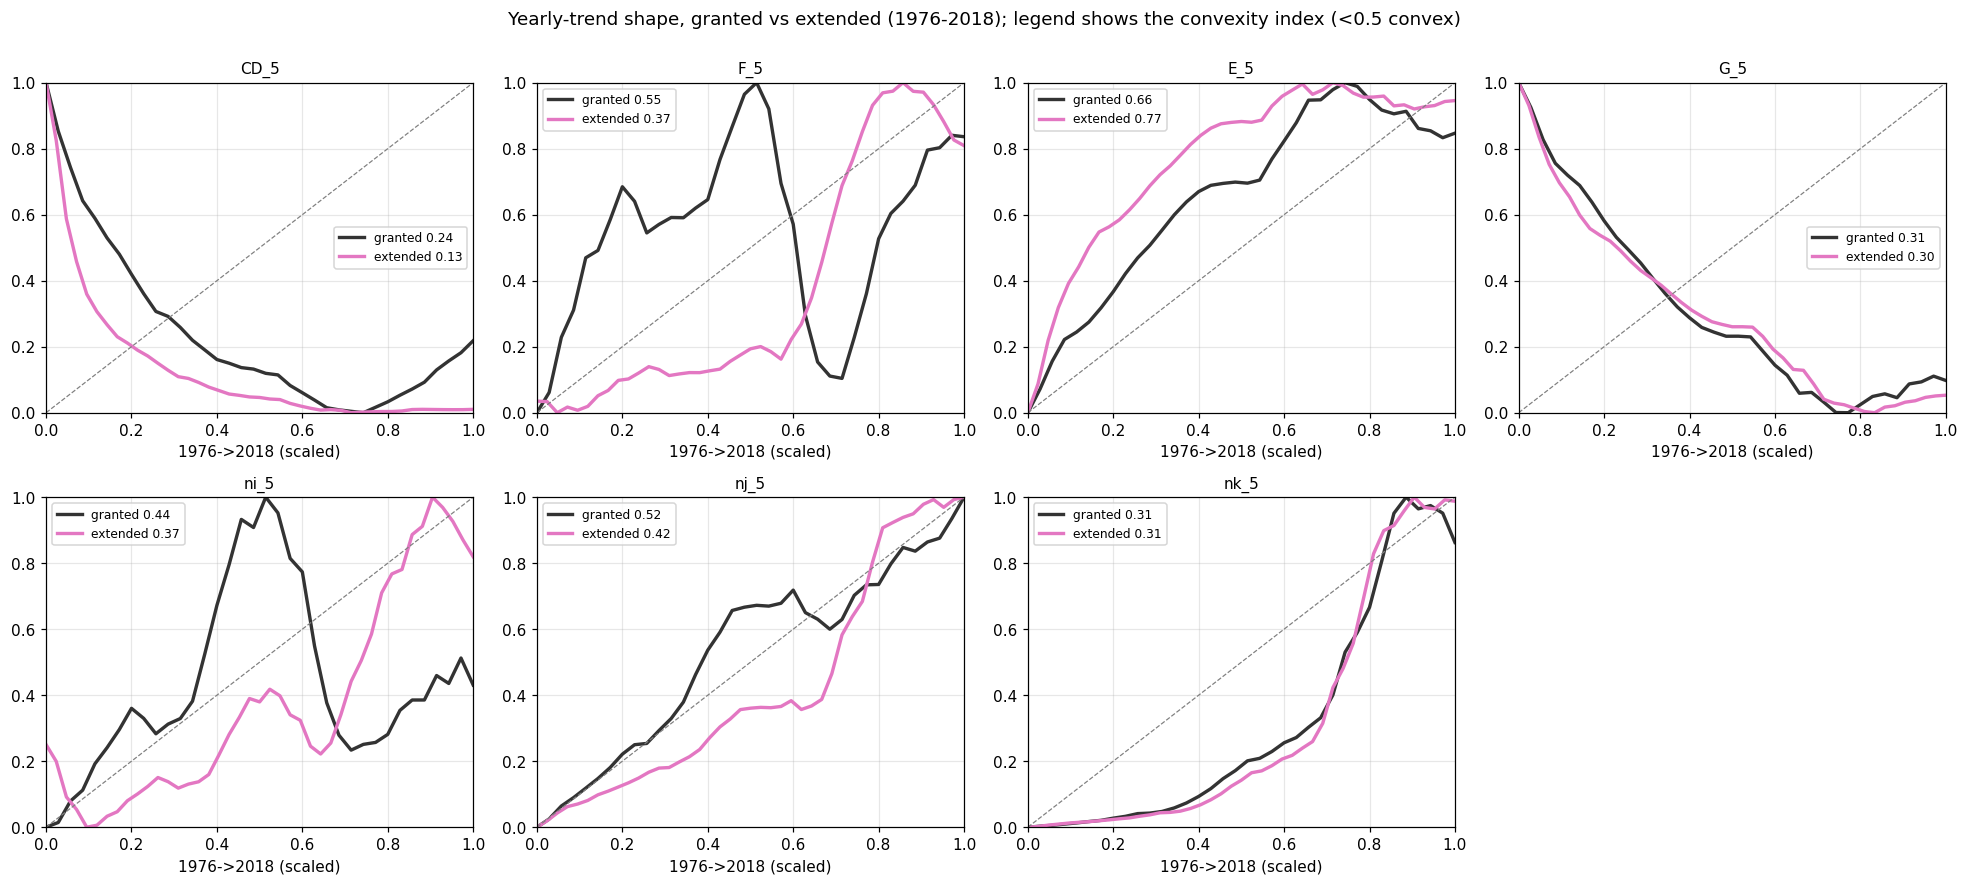

,granted,extended,delta,granted_shape,extended_shape,verdict_flips
CD_5,0.236,0.126,-0.110,convex,convex,False
F_5,0.554,0.372,-0.182,concave,convex,True
E_5,0.657,0.773,0.116,concave,concave,False
G_5,0.309,0.301,-0.007,convex,convex,False
ni_5,0.437,0.372,-0.065,convex,convex,False
nj_5,0.524,0.419,-0.105,concave,convex,True
nk_5,0.314,0.306,-0.007,convex,convex,False


  [fig] patent_validation_25b.jpg + .pdf  (600 dpi)


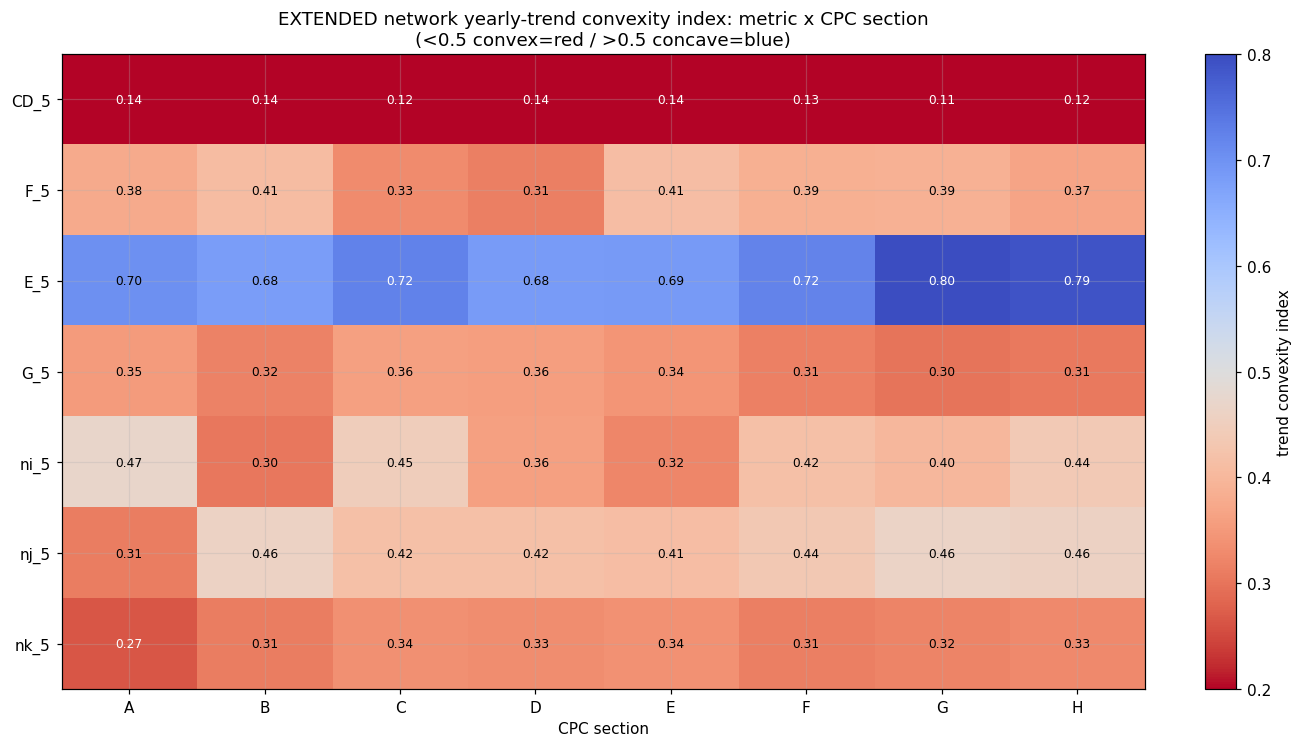

CPU times: user 10.6 s, sys: 1.03 s, total: 11.6 s
Wall time: 9.03 s


['/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_25b.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/patent_validation_25b.pdf']

In [39]:
%%time
ov_e = con.execute(f'''SELECT m.grant_year AS yr, {', '.join(f'avg(d.{m}) {m}' for m in METR)}
  FROM read_parquet('{DAPP}') d JOIN read_parquet('{METAP}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.grant_year BETWEEN {YR0} AND {YR1}
  GROUP BY yr ORDER BY yr''').fetchdf()
bysec_e = con.execute(f'''SELECT m.grant_year AS yr, substr(m.cpc_code,1,1) AS secn, count(*) n,
         {', '.join(f'avg(d.{m}) {m}' for m in METR)}
  FROM read_parquet('{DAPP}') d JOIN read_parquet('{METAP}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.grant_year BETWEEN {YR0} AND {YR1} AND m.cpc_code IS NOT NULL
  GROUP BY yr, secn ORDER BY secn, yr''').fetchdf()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax_, m in zip(axes.flat, METR):
    for src, lab, c in [(ov, 'granted', C_G), (ov_e, 'extended', C_E)]:
        t = src['yr'].values.astype(float); y = src[m].values.astype(float)
        tn = (t - t.min()) / (t.max() - t.min())
        yn = (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y))
        a = trend_cvx(t, y)
        ax_.plot(tn, yn, color=c, lw=2.2, label=f'{lab} {a:.2f}')
    ax_.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8)
    ax_.set_title(m, fontsize=10); ax_.set_xlabel(f'{YR0}->{YR1} (scaled)')
    ax_.set_xlim(0, 1); ax_.set_ylim(0, 1); ax_.legend(fontsize=8)
axes.flat[-1].set_visible(False)
fig.suptitle(f'Yearly-trend shape, granted vs extended ({YR0}-{YR1}); '
             'legend shows the convexity index (<0.5 convex)', y=1.0)
V.save('25a')

cv = pd.DataFrame({'granted':  [trend_cvx(ov['yr'].values, ov[m].values) for m in METR],
                   'extended': [trend_cvx(ov_e['yr'].values, ov_e[m].values) for m in METR]}, index=METR)
cv['delta'] = cv['extended'] - cv['granted']
cv['granted_shape']  = np.where(cv['granted'] < 0.5, 'convex', 'concave')
cv['extended_shape'] = np.where(cv['extended'] < 0.5, 'convex', 'concave')
cv['verdict_flips']  = cv['granted_shape'] != cv['extended_shape']
display(cv.round(3))

secs_e = [s for s in list('ABCDEFGHY') if s in set(bysec_e['secn'].dropna().unique())]
H_e = np.full((len(METR), len(secs_e)), np.nan)
for j, sc in enumerate(secs_e):
    g_ = bysec_e[bysec_e['secn'] == sc].sort_values('yr')
    if g_['n'].sum() < 500:
        continue
    for i, m in enumerate(METR):
        H_e[i, j] = trend_cvx(g_['yr'].values, g_[m].values)
fig, ax = plt.subplots(figsize=(1.0 * len(secs_e) + 4, 0.7 * len(METR) + 2))
im = ax.imshow(H_e, cmap='coolwarm_r', vmin=0.2, vmax=0.8, aspect='auto')
ax.set_xticks(range(len(secs_e))); ax.set_xticklabels(secs_e)
ax.set_yticks(range(len(METR))); ax.set_yticklabels(METR)
for i in range(len(METR)):
    for j in range(len(secs_e)):
        if np.isfinite(H_e[i, j]):
            ax.text(j, i, f'{H_e[i, j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(H_e[i, j] - 0.5) > 0.22 else 'black')
ax.set_title('EXTENDED network yearly-trend convexity index: metric x CPC section\n'
             '(<0.5 convex=red / >0.5 concave=blue)')
ax.set_xlabel('CPC section'); fig.colorbar(im, fraction=0.046, label='trend convexity index')
V.save('25b')

## 26. Team size -> disruption percentile on the extended network (§17 re-run)

The Wu et al. Fig 2a pattern — small teams disrupt, large teams get cited — re-derived with CD_5 taken
from the extended network. The percentile is recomputed within the extended table, so the y-axis is
"disruption rank among patents measured the same way", not a rank imported from §17.

EXTENDED network:
 team_size       dis   dis_ci      cit   cit_ci       n
         1 48.476107 0.045698 3.498318 0.011367 1748788
         2 47.856539 0.054505 4.077149 0.017644 1140951
         3 47.348941 0.066519 4.422090 0.024969  731745
         4 47.085712 0.086869 4.629484 0.034506  417501
         5 46.536806 0.120884 5.005529 0.054190  213074
         6 46.186779 0.168003 5.325309 0.082328  111208
         7 45.116595 0.231321 5.609938 0.116557   57373
         8 44.968650 0.315646 5.926591 0.179187   31086
         9 44.270138 0.431703 6.183669 0.229869   16753
        10 44.313914 0.551384 7.147921 0.447301   10269
  [fig] patent_validation_26.jpg + .pdf  (600 dpi)


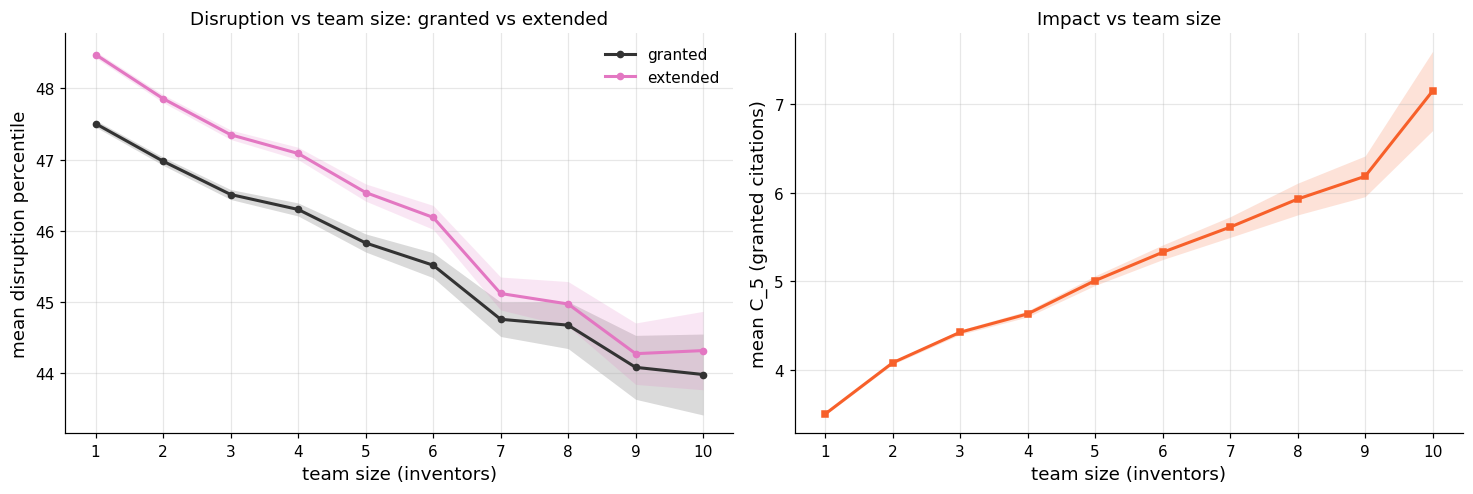

,granted,extended
team=1,47.50,48.48
team=10,43.98,44.31
drop (pp),3.53,4.16


The sign of the team-size effect is what has to survive: a smaller drop under the extended
network would mean part of the published effect came from the missing pre-grant edges.
CPU times: user 8.41 s, sys: 716 ms, total: 9.13 s
Wall time: 4.44 s


In [40]:
%%time
def team_curve(src):
    return con.execute(f'''
    WITH base AS (
      SELECT d.CD_5, c.C_5, len(str_split(m.inventor_list, ';')) AS team_size
      FROM read_parquet('{src}') d
      JOIN read_parquet('{CITp}') c USING (patent_id)
      JOIN read_parquet('{METAp}') m USING (patent_id)
      WHERE d.CD_5 IS NOT NULL AND m.inventor_list IS NOT NULL
        AND m.ref_count >= 1 AND m.grant_year BETWEEN 1980 AND 2015),
    filt AS (SELECT * FROM base WHERE team_size BETWEEN 1 AND 10),
    ranked AS (SELECT team_size, C_5, percent_rank() OVER (ORDER BY CD_5) AS dpct FROM filt)
    SELECT team_size, avg(dpct)*100 AS dis, 1.96*stddev(dpct)/sqrt(count(*))*100 AS dis_ci,
           avg(C_5) AS cit, 1.96*stddev(C_5)/sqrt(count(*)) AS cit_ci, count(*) AS n
    FROM ranked GROUP BY team_size ORDER BY team_size''').fetchdf()

tg, te = team_curve(DGRT), team_curve(DAPP)
print('EXTENDED network:'); print(te.to_string(index=False))

x = te['team_size'].values
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6), facecolor='white')
for src, lab, c in [(tg, 'granted', C_G), (te, 'extended', C_E)]:
    ax[0].plot(src['team_size'], src['dis'], color=c, lw=2, marker='o', ms=4, label=lab)
    ax[0].fill_between(src['team_size'], src['dis'] - src['dis_ci'], src['dis'] + src['dis_ci'],
                       color=c, alpha=0.18, lw=0)
ax[0].set_xlabel('team size (inventors)', size=12); ax[0].set_ylabel('mean disruption percentile', size=12)
ax[0].set_title('Disruption vs team size: granted vs extended', size=12); ax[0].legend(frameon=False)
ax[1].plot(te['team_size'], te['cit'], color='#F7602A', lw=2, marker='s', ms=4)
ax[1].fill_between(te['team_size'], te['cit'] - te['cit_ci'], te['cit'] + te['cit_ci'],
                   color='#F7602A', alpha=0.18, lw=0)
ax[1].set_xlabel('team size (inventors)', size=12); ax[1].set_ylabel('mean C_5 (granted citations)', size=12)
ax[1].set_title('Impact vs team size', size=12)
for a in ax:
    a.set_xticks(x); a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
V.save('26')

slope = pd.DataFrame({'granted': [tg['dis'].iloc[0], tg['dis'].iloc[-1]],
                      'extended': [te['dis'].iloc[0], te['dis'].iloc[-1]]},
                     index=['team=1', 'team=10'])
slope.loc['drop (pp)'] = slope.loc['team=1'] - slope.loc['team=10']
display(slope.round(2))
print('The sign of the team-size effect is what has to survive: a smaller drop under the extended')
print('network would mean part of the published effect came from the missing pre-grant edges.')